In [1]:
import numpy as np
import pandas as pd
import torch
import joblib
import os
import itertools
from tqdm.notebook import tqdm
import math
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm import tqdm

import torchvision
from torchvision import transforms
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import r2_score
from cmnist_train import ImageColorizerUNet, HLCellMeansShrunk

from matplotlib import pyplot as plt
from operations import Intervention

In [125]:
# ---- choose dataset ----
DATA_DIR = "data/cmnist_28_c00_clean"   

# ---- expected files ----
req_files = [
    "dll_samples.pkl", "dhl_samples.pkl", "intervention_mapping.pkl",
    "ll_model_unet.pth", "hl_model_cellmeans.joblib",
    "U_ll_hat.pkl", "U_hl_hat.pkl"
]
missing = [f for f in req_files if not os.path.isfile(os.path.join(DATA_DIR, f))]
if missing:
    raise FileNotFoundError(f"Missing files in {DATA_DIR}: {missing}")

# ---- load datasets ----
maploc = "cpu" if not torch.cuda.is_available() else None
Dll_samples  = torch.load(os.path.join(DATA_DIR, "dll_samples.pkl"), map_location=maploc)
Dhl_samples  = torch.load(os.path.join(DATA_DIR, "dhl_samples.pkl"), map_location=maploc)
omega        = torch.load(os.path.join(DATA_DIR, "intervention_mapping.pkl"), map_location=maploc)

Ill_relevant = list(omega.keys())
Ihl_relevant = list(omega.values())

# ---- load trained models & residuals ----
ll_model = ImageColorizerUNet(norm_type="bn")
ll_state = torch.load(os.path.join(DATA_DIR, "ll_model_unet.pth"), map_location="cpu")
ll_model.load_state_dict(ll_state)
ll_model.eval()

hl_model = joblib.load(os.path.join(DATA_DIR, "hl_model_cellmeans.joblib"))

U_ll_hat = torch.load(os.path.join(DATA_DIR, "U_ll_hat.pkl"), map_location="cpu")
U_hl_hat = torch.load(os.path.join(DATA_DIR, "U_hl_hat.pkl"), map_location="cpu")

print("✓ Data & models loaded")
print(f"  DATA_DIR: {DATA_DIR}")
print(f"  LL noise (U_ll_hat): {tuple(U_ll_hat.shape)}")
print(f"  HL noise (U_hl_hat): {tuple(U_hl_hat.shape)}")
print(f"  Interventions ({len(Ill_relevant)}): {Ill_relevant[:5]}{' ...' if len(Ill_relevant)>5 else ''}")

# ---- convenient constants (as in generator) ----
D_LL, C_LL, P_LL = 'Digit', 'Color', 'Pixels'
D_HL, C_HL, I_HL = 'Digit_', 'Color_', 'Image_'

def get_obs_tuple(D):
    return D.get("obs") or D.get(None) or next(iter(D.values()))

# quick sanity peek
ll_obs = get_obs_tuple(Dll_samples)
hl_obs = Dhl_samples.get("obs", next(iter(Dhl_samples.values())))
imgs, shapes, digs, cols = ll_obs
print(f"  LL obs shapes: images={tuple(imgs.shape)}, shapes={tuple(shapes.shape)}, digits={tuple(digs.shape)}, colors={tuple(cols.shape)}")
print(f"  HL obs shape: {tuple(hl_obs.shape)}")


✓ Data & models loaded
  DATA_DIR: data/cmnist_28_c00_clean
  LL noise (U_ll_hat): (1000, 3, 28, 28)
  HL noise (U_hl_hat): (1000, 1)
  Interventions (10): ['obs', 'D=6', 'D=8', 'D=4', 'C=7'] ...
  LL obs shapes: images=(1000, 3, 28, 28), shapes=(1000, 1, 28, 28), digits=(1000,), colors=(1000,)
  HL obs shape: (1000, 21)


=== U_ll_hat Analysis ===
Shape: torch.Size([1000, 3, 28, 28])
Data type: torch.float32
Min value: -0.793269
Max value: 0.890994
Mean value: 0.000888
Std value: 0.050428
Non-zero elements: 2351999/2352000 (100.00%)

=== U_hl_hat Analysis ===
Shape: torch.Size([1000, 1])
Data type: torch.float32
Min value: -0.060189
Max value: 0.072516
Mean value: -0.000049
Std value: 0.017750
Non-zero elements: 1000/1000 (100.00%)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3246364..0.21909195].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.44463095..0.43063676].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.53230506..0.4807105].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4352932..0.39952242].


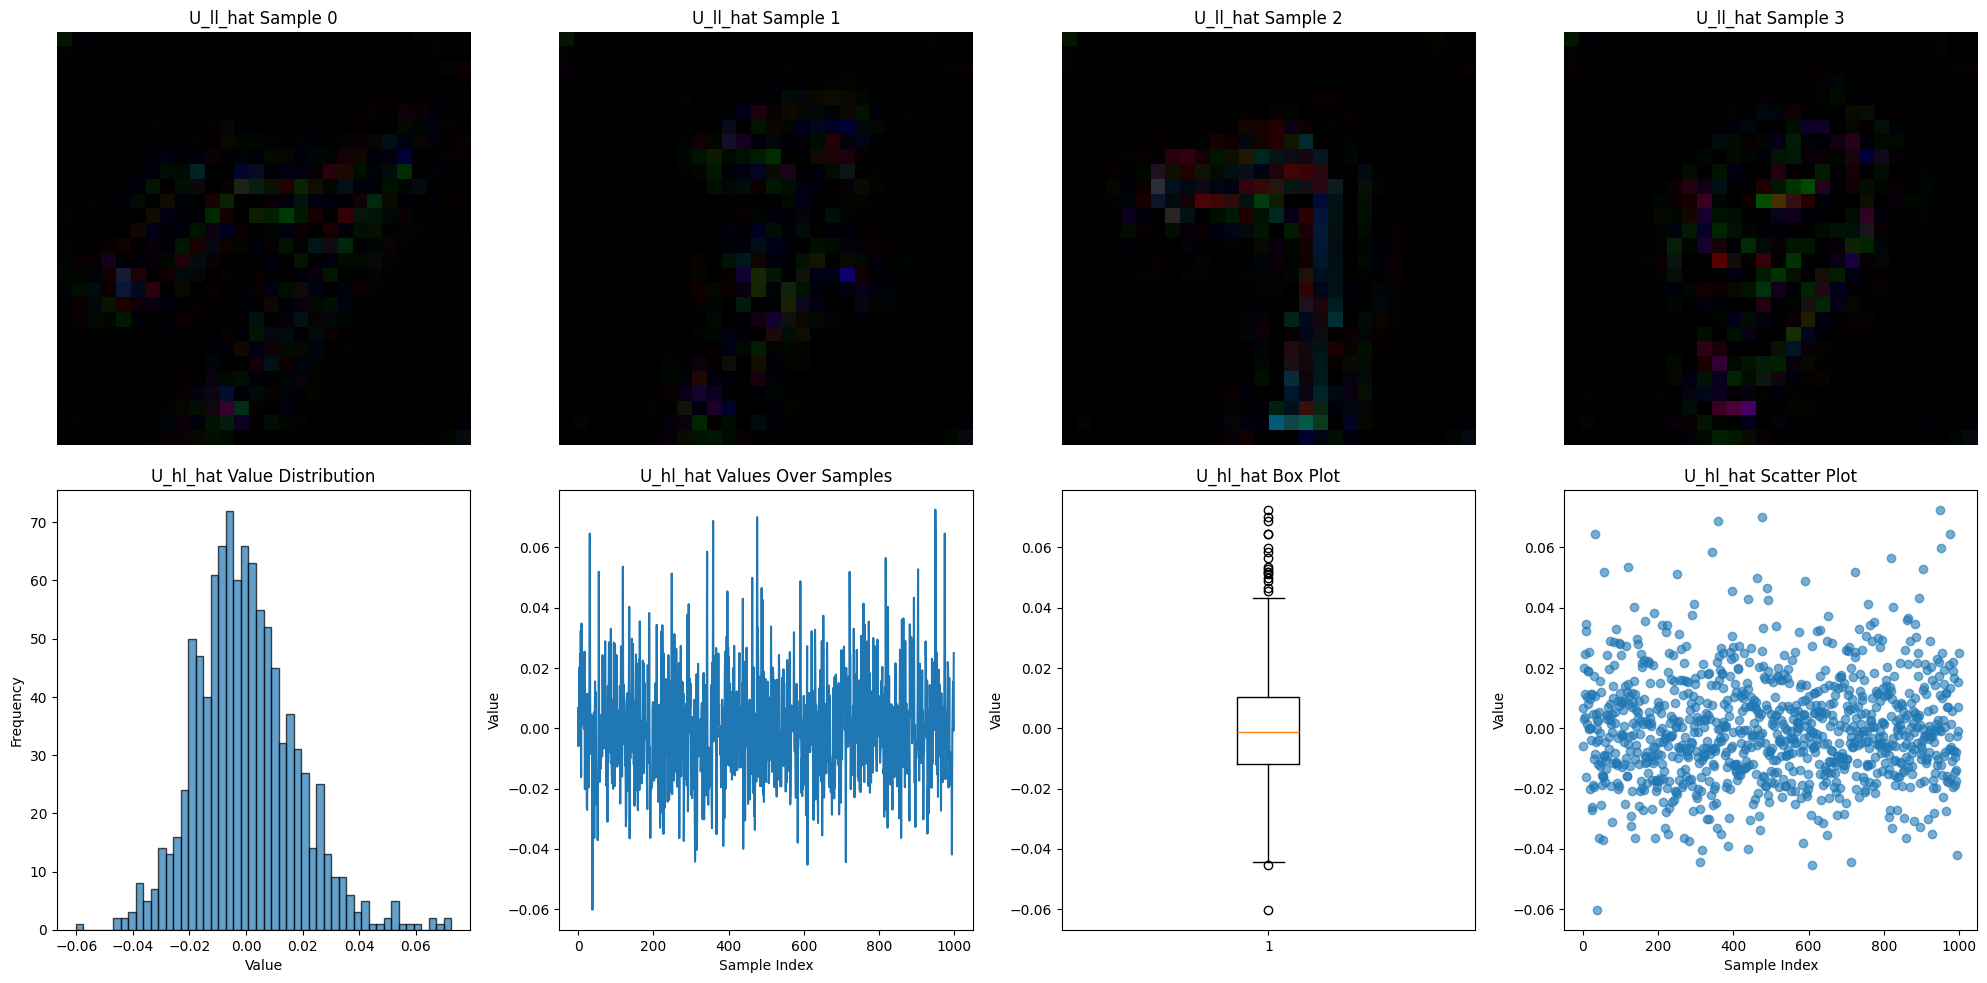


=== U_ll_hat Detailed Analysis ===
Per-channel statistics:
  Channel 0: mean=0.000795, std=0.051347
  Channel 1: mean=0.001646, std=0.049684
  Channel 2: mean=0.000223, std=0.050228

U_ll_hat spatial statistics:
  Mean per pixel: 0.000888
  Std per pixel: 0.004432
  Zero percentage: 0.00%

=== U_hl_hat Detailed Analysis ===
Value range: [-0.060189, 0.072516]
Magnitude range: 0.072516
  Outliers (1.5*IQR): 19/1000 (1.90%)
  Near zero (<0.001): 54/1000 (5.40%)


In [126]:
# Analyze U_ll_hat and U_hl_hat
print("=== U_ll_hat Analysis ===")
print(f"Shape: {U_ll_hat.shape}")
print(f"Data type: {U_ll_hat.dtype}")
print(f"Min value: {U_ll_hat.min().item():.6f}")
print(f"Max value: {U_ll_hat.max().item():.6f}")
print(f"Mean value: {U_ll_hat.mean().item():.6f}")
print(f"Std value: {U_ll_hat.std().item():.6f}")
print(f"Non-zero elements: {(U_ll_hat != 0).sum().item()}/{U_ll_hat.numel()} ({(U_ll_hat != 0).sum().item()/U_ll_hat.numel()*100:.2f}%)")

print("\n=== U_hl_hat Analysis ===")
print(f"Shape: {U_hl_hat.shape}")
print(f"Data type: {U_hl_hat.dtype}")
print(f"Min value: {U_hl_hat.min().item():.6f}")
print(f"Max value: {U_hl_hat.max().item():.6f}")
print(f"Mean value: {U_hl_hat.mean().item():.6f}")
print(f"Std value: {U_hl_hat.std().item():.6f}")
print(f"Non-zero elements: {(U_hl_hat != 0).sum().item()}/{U_hl_hat.numel()} ({(U_hl_hat != 0).sum().item()/U_hl_hat.numel()*100:.2f}%)")

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# U_ll_hat visualizations
# 1. Sample images from U_ll_hat
for i in range(min(4, U_ll_hat.shape[0])):
    ax = axes[0, i]
    img = U_ll_hat[i].permute(1, 2, 0).numpy()
    if img.shape[2] == 1:
        img = img.squeeze(2)
        ax.imshow(img, cmap='RdBu_r', vmin=-0.02, vmax=0.02)
    else:
        ax.imshow(img)
    ax.set_title(f'U_ll_hat Sample {i}')
    ax.axis('off')

# U_hl_hat visualizations
# 2. Histogram of U_hl_hat values
axes[1, 0].hist(U_hl_hat.numpy().flatten(), bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('U_hl_hat Value Distribution')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Frequency')

# 3. Line plot of U_hl_hat values
axes[1, 1].plot(U_hl_hat.numpy().flatten())
axes[1, 1].set_title('U_hl_hat Values Over Samples')
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Value')

# 4. Box plot of U_hl_hat
axes[1, 2].boxplot(U_hl_hat.numpy().flatten())
axes[1, 2].set_title('U_hl_hat Box Plot')
axes[1, 2].set_ylabel('Value')

# 5. Scatter plot of U_hl_hat
axes[1, 3].scatter(range(len(U_hl_hat)), U_hl_hat.numpy().flatten(), alpha=0.6)
axes[1, 3].set_title('U_hl_hat Scatter Plot')
axes[1, 3].set_xlabel('Sample Index')
axes[1, 3].set_ylabel('Value')

plt.tight_layout()
plt.show()

# Additional analysis for U_ll_hat
print("\n=== U_ll_hat Detailed Analysis ===")
print(f"Per-channel statistics:")
for i in range(U_ll_hat.shape[1]):
    channel_data = U_ll_hat[:, i, :, :]
    print(f"  Channel {i}: mean={channel_data.mean().item():.6f}, std={channel_data.std().item():.6f}")

# Check for patterns in U_ll_hat
print(f"\nU_ll_hat spatial statistics:")
print(f"  Mean per pixel: {U_ll_hat.mean(dim=0).mean().item():.6f}")
print(f"  Std per pixel: {U_ll_hat.mean(dim=0).std().item():.6f}")

# Check if U_ll_hat is mostly zeros (like the Dll_samples)
zero_percentage = (U_ll_hat == 0).sum().item() / U_ll_hat.numel() * 100
print(f"  Zero percentage: {zero_percentage:.2f}%")

# Additional analysis for U_hl_hat
print("\n=== U_hl_hat Detailed Analysis ===")
print(f"Value range: [{U_hl_hat.min().item():.6f}, {U_hl_hat.max().item():.6f}]")
print(f"Magnitude range: {abs(U_hl_hat).max().item():.6f}")

# Check for outliers
q25, q75 = torch.quantile(U_hl_hat, 0.25), torch.quantile(U_hl_hat, 0.75)
iqr = q75 - q25
outlier_threshold = 1.5 * iqr
outliers = ((U_hl_hat < q25 - outlier_threshold) | (U_hl_hat > q75 + outlier_threshold)).sum().item()
print(f"  Outliers (1.5*IQR): {outliers}/{len(U_hl_hat)} ({outliers/len(U_hl_hat)*100:.2f}%)")

# Check if values are close to zero
near_zero = (abs(U_hl_hat) < 0.001).sum().item()
print(f"  Near zero (<0.001): {near_zero}/{len(U_hl_hat)} ({near_zero/len(U_hl_hat)*100:.2f}%)")


=== Background & Edge Analysis in U_ll_hat ===
Image size: 28×28 | channels=3
Background threshold (|residual| < τ): τ = 0.02521
Edge band width: 4 px
Background-like pixels: 1710989/2352000 (72.75%)
  bg stats — min=-0.025214 | max=0.025214 | mean=0.000104 | std=0.008552

Region statistics:
  center: mean=0.001578, std=0.067077, min=-0.793269, max=0.781406, count=1200000
  edge: mean=0.000170, std=0.022451, min=-0.506685, max=0.890994, count=1152000

Near-zero counts:
  exactly 0: 1
  |x| < 1e-3: 292965  |x| < 1e-2: 1353377  |x| < 1e-1: 2202577


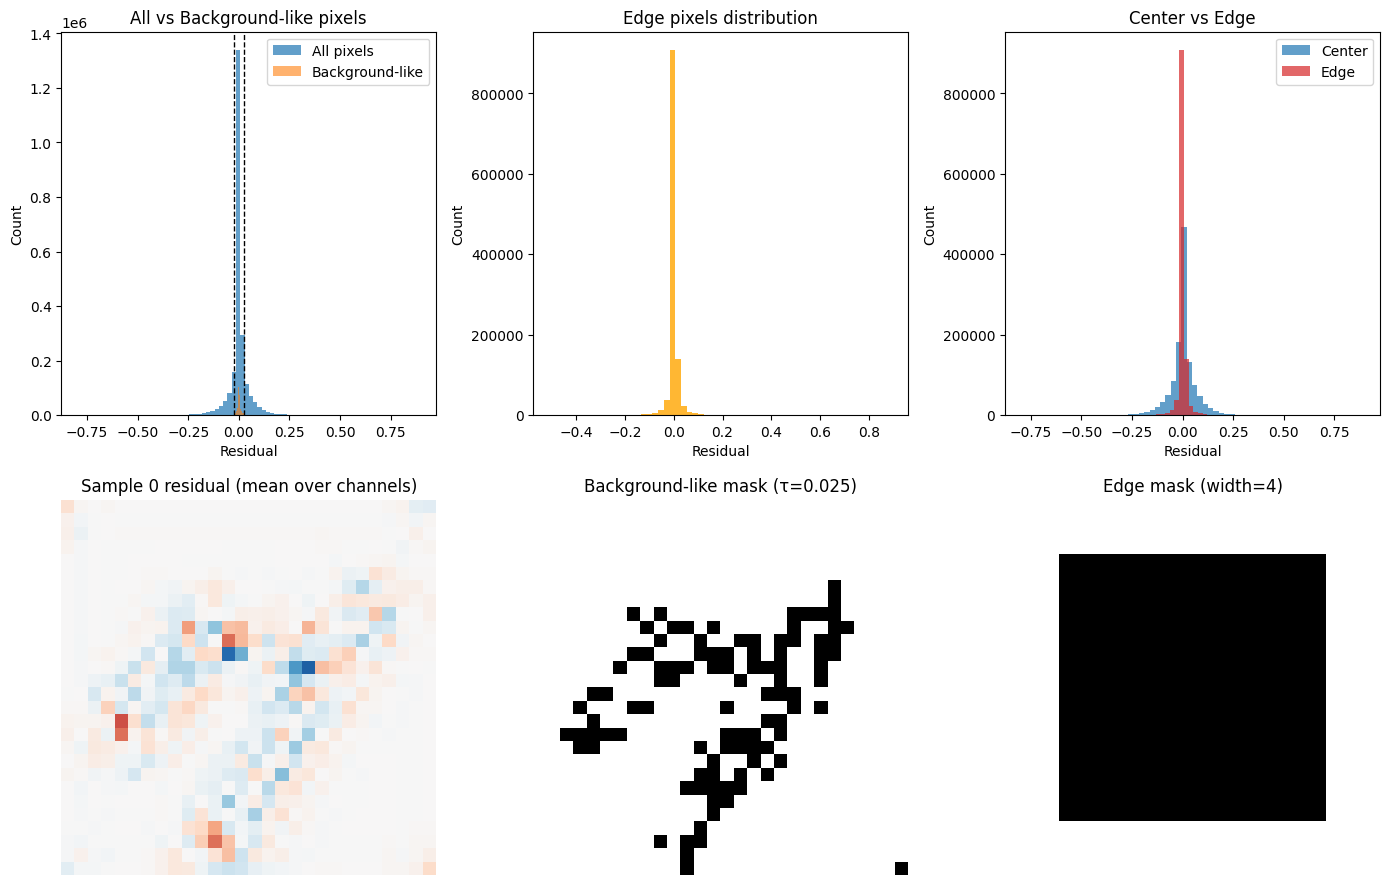

In [127]:
print("=== Background & Edge Analysis in U_ll_hat ===")
assert U_ll_hat.dim() == 4 and U_ll_hat.size(1) in (1,3), "Expected (N, C, H, W) with C in {1,3}"

N, C, H, W = U_ll_hat.shape
device = U_ll_hat.device

# ---- Thresholds & edge width ----
# If you'd like a fixed absolute threshold, set: background_threshold = 0.01
background_threshold = float(0.5 * U_ll_hat.std().item())
edge_frac = 0.125  # ~12.5% of each border; tweak if you like
edge_w = max(1, int(round(min(H, W) * edge_frac)))

print(f"Image size: {H}×{W} | channels={C}")
print(f"Background threshold (|residual| < τ): τ = {background_threshold:.5f}")
print(f"Edge band width: {edge_w} px")

# ---- Background mask (values near 0) ----
bg_mask = (U_ll_hat.abs() < background_threshold)
bg_pixels = U_ll_hat[bg_mask]
bg_ratio = 100.0 * bg_pixels.numel() / U_ll_hat.numel()

print(f"Background-like pixels: {bg_pixels.numel()}/{U_ll_hat.numel()} ({bg_ratio:.2f}%)")
if bg_pixels.numel() > 0:
    print(f"  bg stats — min={bg_pixels.min().item():.6f} | max={bg_pixels.max().item():.6f} "
          f"| mean={bg_pixels.mean().item():.6f} | std={bg_pixels.std().item():.6f}")
else:
    print("  bg stats — (none under threshold)")

# ---- Edge masks (vectorized) ----
edge_mask = torch.zeros((H, W), dtype=torch.bool, device=device)
edge_mask[:edge_w, :] = True            # top
edge_mask[-edge_w:, :] = True           # bottom
edge_mask[:, :edge_w] = True            # left
edge_mask[:, -edge_w:] = True           # right

# Broadcast mask to (N, C, H, W)
edge_mask_b = edge_mask.view(1, 1, H, W).expand(N, C, H, W)
center_mask_b = ~edge_mask_b

edge_pixels = U_ll_hat[edge_mask_b]
center_pixels = U_ll_hat[center_mask_b]

def _stats(name, x):
    if x.numel() == 0:
        print(f"  {name}: (empty)")
        return
    print(f"  {name}: mean={x.mean().item():.6f}, std={x.std().item():.6f}, "
          f"min={x.min().item():.6f}, max={x.max().item():.6f}, count={x.numel()}")

print("\nRegion statistics:")
_stats("center", center_pixels)
_stats("edge", edge_pixels)

# ---- Quick summary of exact/near-zero counts ----
exact_zero = (U_ll_hat == 0).sum().item()
lt_1e3 = (U_ll_hat.abs() < 1e-3).sum().item()
lt_1e2 = (U_ll_hat.abs() < 1e-2).sum().item()
lt_1e1 = (U_ll_hat.abs() < 1e-1).sum().item()

print("\nNear-zero counts:")
print(f"  exactly 0: {exact_zero}")
print(f"  |x| < 1e-3: {lt_1e3}  |x| < 1e-2: {lt_1e2}  |x| < 1e-1: {lt_1e1}")

# ---- Visualization ----
# Robust symmetric limits for residual display
vals = U_ll_hat.detach().cpu().numpy().reshape(-1)
vlim = np.percentile(np.abs(vals), 99) if vals.size else 0.1
vlim = max(vlim, 1e-3)  # avoid degenerate

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# 1) All vs background histogram
axes[0, 0].hist(vals, bins=80, alpha=0.7, label='All pixels')
if bg_pixels.numel() > 0:
    axes[0, 0].hist(bg_pixels.detach().cpu().numpy(), bins=60, alpha=0.6, label='Background-like')
axes[0, 0].axvline(+background_threshold, color='k', ls='--', lw=1)
axes[0, 0].axvline(-background_threshold, color='k', ls='--', lw=1)
axes[0, 0].set_title('All vs Background-like pixels')
axes[0, 0].legend(); axes[0, 0].set_xlabel('Residual'); axes[0, 0].set_ylabel('Count')

# 2) Edge histogram
if edge_pixels.numel() > 0:
    axes[0, 1].hist(edge_pixels.detach().cpu().numpy().reshape(-1), bins=60, color='orange', alpha=0.8)
axes[0, 1].set_title('Edge pixels distribution')
axes[0, 1].set_xlabel('Residual'); axes[0, 1].set_ylabel('Count')

# 3) Center vs Edge histogram
if center_pixels.numel() > 0 and edge_pixels.numel() > 0:
    axes[0, 2].hist(center_pixels.detach().cpu().numpy().reshape(-1), bins=60, alpha=0.7, label='Center', color='C0')
    axes[0, 2].hist(edge_pixels.detach().cpu().numpy().reshape(-1),   bins=60, alpha=0.7, label='Edge',   color='C3')
    axes[0, 2].legend()
axes[0, 2].set_title('Center vs Edge'); axes[0, 2].set_xlabel('Residual'); axes[0, 2].set_ylabel('Count')

# 4) Sample residual image
idx = 0
img = U_ll_hat[idx].detach().cpu()
if C == 1:
    axes[1, 0].imshow(img[0], cmap='RdBu_r', vmin=-vlim, vmax=+vlim)
else:
    # show color residuals channel-averaged to emphasize structure
    axes[1, 0].imshow(img.mean(0), cmap='RdBu_r', vmin=-vlim, vmax=+vlim)
axes[1, 0].set_title(f"Sample {idx} residual (mean over channels)")
axes[1, 0].axis('off')

# 5) Background mask for sample
bg_mask_sample = (img.abs() < background_threshold)
axes[1, 1].imshow(bg_mask_sample.any(0), cmap='gray')
axes[1, 1].set_title(f"Background-like mask (τ={background_threshold:.3f})")
axes[1, 1].axis('off')

# 6) Edge mask for sample
axes[1, 2].imshow(edge_mask.cpu(), cmap='gray')
axes[1, 2].set_title(f"Edge mask (width={edge_w})")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


In [128]:
# --- Robust helpers ----------------------------------------------------------

def _is_obs_key(k):
    return (
        k is None
        or (isinstance(k, str) and k.strip().lower() in ("obs", "none", "baseline", "control", "noiv"))
        or (hasattr(k, "vv") and len(getattr(k, "vv")()) == 0)
        or (isinstance(k, dict) and len(k) == 0)
    )

def _iv_to_dict(iv):
    """
    Normalize various intervention key formats to a dict with (possibly) keys among
    {'D', 'Digit', 'D_LL', 'D_HL', 'C', 'Color', 'C_LL', 'C_HL'} mapping to ints.
    Returns {} for observational case.
    """
    if _is_obs_key(iv):
        return {}

    # Intervention object
    if hasattr(iv, "vv") and callable(iv.vv):
        return dict(iv.vv())

    # Already a dict
    if isinstance(iv, dict):
        return {str(k): int(v) for k, v in iv.items()}

    # String: allow "D=6", "C=0" or "D=6,C=0"
    if isinstance(iv, str):
        s = iv.strip()
        parts = [p for p in s.split(",") if p.strip()]
        out = {}
        for p in parts:
            if "=" not in p:
                # if it's just 'obs', it'll be caught by _is_obs_key above; otherwise raise
                raise ValueError(f"Intervention string must be key=val, got '{p}' in '{iv}'")
            k, v = p.split("=")
            out[k.strip()] = int(v)
        return out

    # Fallback: unsupported
    raise TypeError(f"Unsupported intervention type: {type(iv)} -> {iv}")

def _pick_digit_key(iv_dict):
    # accept any of these spellings for digit
    for k in ("D_LL", "D_HL", "Digit", "D"):
        if k in iv_dict:
            return iv_dict[k]
    return None

def _pick_color_key(iv_dict):
    for k in ("C_LL", "C_HL", "Color", "C"):
        if k in iv_dict:
            return iv_dict[k]
    return None

# --- Deterministic functions --------------------------------------------------

def det_hl_func(hl_model, parent_info_hl, intervention):
    """
    parent_info_hl: numpy array (N, 20) = [Digit_ one-hot (10), Color_ one-hot (10)] from OBS
    intervention: can be 'obs', dict, 'D=6', 'C=0', 'D=6,C=0', or an Intervention object with .vv()

    Returns a torch.float32 tensor (N, 21):
      [Digit_ one-hot (10), Color_ one-hot (10), Image_ (1)]
    """
    feats = parent_info_hl.copy()              # (N, 20)
    Xd = feats[:, :10].copy()                  # (N, 10) digit one-hot
    Xc = feats[:, 10:20].copy()                # (N, 10) color one-hot

    ivd = _iv_to_dict(intervention)            # normalize to dict

    d_new = _pick_digit_key(ivd)
    c_new = _pick_color_key(ivd)

    if d_new is not None:
        Xd = np.zeros_like(Xd)
        Xd[:, d_new] = 1
    if c_new is not None:
        Xc = np.zeros_like(Xc)
        Xc[:, c_new] = 1

    # Call HLCellMeansShrunk.predict(Xd, Xc)
    y = hl_model.predict(Xd, Xc)               # (N,) or (N,1)
    y = np.asarray(y).reshape(-1, 1)

    full = np.concatenate([Xd, Xc, y], axis=1) # (N, 21)
    return torch.tensor(full, dtype=torch.float32)


def det_ll_func(ll_model, parent_info_ll_tuple, intervention):
    """
    parent_info_ll_tuple: (final_images, img_shapes, digits, colors) from OBS
    Returns torch.float32 tensor (N, 3*H*W + 20): [flat_pred_image, Digit one-hot (10), Color one-hot (10)]
    """
    _, img_shapes, digits, colors = parent_info_ll_tuple
    n = digits.shape[0]

    ivd = _iv_to_dict(intervention)
    d_new = _pick_digit_key(ivd)
    c_new = _pick_color_key(ivd)

    d = digits.clone()
    c = colors.clone()
    if d_new is not None:
        d = torch.full_like(d, d_new)
    if c_new is not None:
        c = torch.full_like(c, c_new)

    device = next(ll_model.parameters()).device
    ll_model.eval()
    with torch.no_grad():
        pred = ll_model(img_shapes.to(device),
                        d.to(device).long(),
                        c.to(device).long())

    flat = pred.detach().cpu().view(n, -1)
    d_oh = F.one_hot(d.cpu(), num_classes=10).float()
    c_oh = F.one_hot(c.cpu(), num_classes=10).float()
    return torch.cat([flat, d_oh, c_oh], dim=1)

# --- Build dicts safely -------------------------------------------------------

# OBS slices
ll_obs = Dll_samples.get("obs", next(iter(Dll_samples.values())))     # (imgs, shapes, digits, colors)
hl_obs = Dhl_samples.get("obs", next(iter(Dhl_samples.values())))     # (N, 21)
parent_info_ll_tuple = (ll_obs[0], ll_obs[1], ll_obs[2], ll_obs[3])
parent_info_hl = hl_obs[:, :-1].numpy()

# Interventions from your mapping
Ill_relevant = list(omega.keys())
Ihl_relevant = list(omega.values())

det_ll_dict = {}
for iota in tqdm(Ill_relevant, desc="Computing LL deterministic (U-Net)"):
    det_ll_dict[iota] = det_ll_func(ll_model, parent_info_ll_tuple, iota)

det_hl_dict = {}
for eta in tqdm(Ihl_relevant, desc="Computing HL deterministic (HL)"):
    det_hl_dict[eta] = det_hl_func(hl_model, parent_info_hl, eta)

# Pick an observational key to report shapes
obs_keys_ll = [k for k in det_ll_dict if _is_obs_key(k) or (isinstance(k, str) and k.lower()=="obs")]
obs_key = obs_keys_ll[0] if obs_keys_ll else next(iter(det_ll_dict))
print(f"   - Low-level shape:  {tuple(det_ll_dict[obs_key].shape)}")
print(f"   - High-level shape: {tuple(det_hl_dict[omega.get(obs_key, 'obs')].shape) if obs_key in omega else tuple(next(iter(det_hl_dict.values())).shape)}")


Computing HL deterministic (HL): 100%|██████████| 10/10 [00:00<00:00, 2848.23it/s]

   - Low-level shape:  (1000, 2372)
   - High-level shape: (1000, 21)


In [129]:
# ===================== Diagnostic Test for hl_model (robust) =====================

print("\n" + "="*20 + " Diagnostic Test for hl_model " + "="*20)

# 1) discover available intervention labels on the HL side
hl_keys = list(Dhl_samples.keys())

def pick_obs_key(keys):
    # prefer explicit 'obs' if present; else take the first non-interventional key
    if "obs" in keys: 
        return "obs"
    # some datasets might use None or other markers; fall back to first key
    return keys[0]

def pick_digit_key(keys, default_digit=8):
    # prefer exact "D=<digit>" if present; else pick any key that starts with "D="
    want = f"D={default_digit}"
    if want in keys: 
        return want
    cands = [k for k in keys if isinstance(k, str) and k.startswith("D=")]
    return cands[0] if cands else None

def pick_color_key(keys, default_color=0):
    want = f"C={default_color}"
    if want in keys: 
        return want
    cands = [k for k in keys if isinstance(k, str) and k.startswith("C=")]
    return cands[0] if cands else None

obs_key   = pick_obs_key(hl_keys)
digit_key = pick_digit_key(hl_keys, default_digit=8)
color_key = pick_color_key(hl_keys, default_color=0)

if digit_key is None or color_key is None:
    print("Error: Could not find digit/color intervention keys on the HL dataset. Keys were:")
    print(hl_keys)
else:
    # 2) compute deterministic HL outputs under obs / do(D=*) / do(C=*)
    D_h_obs    = det_hl_func(hl_model, parent_info_hl, None)        # (N, 21)
    D_h_d8     = det_hl_func(hl_model, parent_info_hl, digit_key)   # (N, 21)
    D_h_c0     = det_hl_func(hl_model, parent_info_hl, color_key)   # (N, 21)

    # 3) compare means of predicted Image_ (last column)
    mean_obs = float(D_h_obs[:, -1].mean())
    mean_d8  = float(D_h_d8[:, -1].mean())
    mean_c0  = float(D_h_c0[:, -1].mean())

    print(f"Mean Image_ (obs):     {mean_obs:.6f}")
    print(f"Mean Image_ ({digit_key}): {mean_d8:.6f}")
    print(f"Mean Image_ ({color_key}): {mean_c0:.6f}")

    # also show deltas
    delta_d = mean_d8 - mean_obs
    delta_c = mean_c0 - mean_obs
    print(f"Δ({digit_key} - obs): {delta_d:.6e}")
    print(f"Δ({color_key} - obs): {delta_c:.6e}")

    # 4) verdict: tiny tolerance to avoid floating noise
    tol = 1e-4
    if (abs(delta_d) < tol) and (abs(delta_c) < tol):
        print("\n*** DIAGNOSIS: PROBLEM CONFIRMED ***")
        print("HL predictions barely change under interventions (means are effectively identical).")
        print("Re-train HL model or verify that the training procedure is using digit/color properly.")
    else:
        print("\n*** DIAGNOSIS: OK ***")
        print("HL predictions respond to interventions (non-trivial mean shifts detected).")



==================== Diagnostic Test for hl_model ====================
Mean Image_ (obs):     0.064875
Mean Image_ (D=8): 0.076603
Mean Image_ (C=0): 0.044485
Δ(D=8 - obs): 1.172806e-02
Δ(C=0 - obs): -2.039007e-02

*** DIAGNOSIS: OK ***
HL predictions respond to interventions (non-trivial mean shifts detected).


HL IMAGE VARIABLE DISTRIBUTION ANALYSIS
Using keys → obs: 'obs', digit: 'D=8', color: 'C=0', combo: 'D=8,C=0'
Observational:
  Mean: 0.064826
  Std:  0.025729
  Min:  0.013547
  Max:  0.172943
do(D=8):
  Mean: 0.076431
  Std:  0.024446
  Min:  0.027451
  Max:  0.179482
do(C=0):
  Mean: 0.043969
  Std:  0.013755
  Min:  0.013310
  Max:  0.100709
do(D=8,C=0):
  Mean: 0.049973
  Std:  0.012907
  Min:  0.016907
  Max:  0.115963


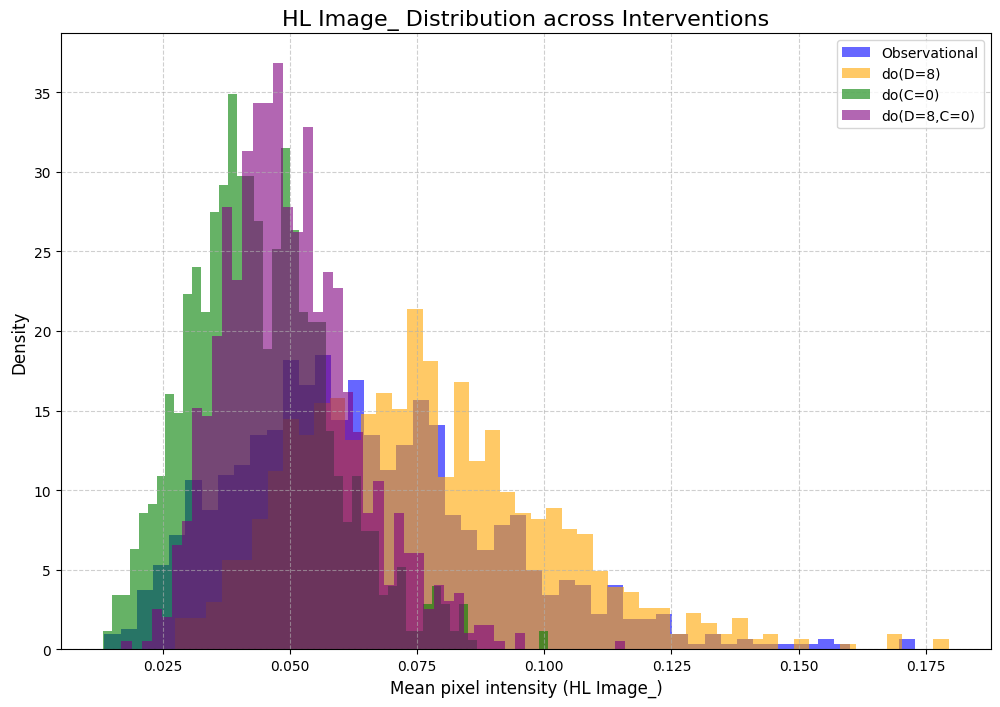


INTERVENTION RESPONSE ANALYSIS
do(D=8): Δ mean = +0.011605
do(C=0): Δ mean = -0.020857
do(D=8,C=0): Δ mean = -0.014853


In [130]:
print("="*60)
print("HL IMAGE VARIABLE DISTRIBUTION ANALYSIS")
print("="*60)

# Helpers
def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def _pick_obs_key(keys):
    if "obs" in keys: return "obs"
    # some datasets might have None or other marker for obs
    for k in keys:
        if k is None or (isinstance(k, str) and k.lower() in {"none","observational","baseline"}):
            return k
    return keys[0]

def _pick_first_with_prefix(keys, prefix):
    cands = [k for k in keys if isinstance(k, str) and k.startswith(prefix)]
    return cands[0] if cands else None

hl_keys = list(Dhl_samples.keys())

obs_key   = _pick_obs_key(hl_keys)
dig_key   = "D=8" if "D=8" in hl_keys else _pick_first_with_prefix(hl_keys, "D=")
col_key   = "C=0" if "C=0" in hl_keys else _pick_first_with_prefix(hl_keys, "C=")

# try to find a combined (digit,color) key, else we will synthesize it
combo_literal = "D=8,C=0"
if combo_literal in hl_keys:
    combo_key = combo_literal
else:
    # pick any combined key if present, else None (we'll synthesize later if needed)
    combo_candidates = [k for k in hl_keys if isinstance(k, str) and "," in k and "D=" in k and "C=" in k]
    combo_key = combo_candidates[0] if combo_candidates else None

print(f"Using keys → obs: {obs_key!r}, digit: {dig_key!r}, color: {col_key!r}, combo: {combo_key!r}")

def get_lastcol_for_key(k, synth_from=None):
    """
    Return the last column (HL Image_) for the given key.
    If k is None and synth_from=(digit_key, color_key) is given, attempt to
    synthesize via intersection by matching one-hots in the first 20 cols.
    """
    if k is not None and k in Dhl_samples:
        arr = _to_numpy(Dhl_samples[k])
        return arr[:, -1]
    if synth_from is None:
        return None

    dkey, ckey = synth_from
    if dkey not in Dhl_samples or ckey not in Dhl_samples:
        return None

    Hd = _to_numpy(Dhl_samples[dkey])  # (N, 21)
    Hc = _to_numpy(Dhl_samples[ckey])  # (N, 21)

    # Match rows where the first 20 one-hots are identical; then take last col
    mask = np.all(np.isclose(Hd[:, :20], Hc[:, :20]), axis=1)
    if not np.any(mask):
        return None

    # Average the last columns where one-hots agree (simple proxy if exact combo not available)
    vals = 0.5 * (Hd[mask, -1] + Hc[mask, -1])
    return vals

# Collect distributions
hl_feature_values = {}

obs_vals = get_lastcol_for_key(obs_key)
if obs_vals is None:
    raise RuntimeError("Could not locate observational HL rows.")

dig_vals = get_lastcol_for_key(dig_key)
col_vals = get_lastcol_for_key(col_key)

# Try exact combo; if missing, synthesize from digit+color intersections
combo_vals = get_lastcol_for_key(combo_key, synth_from=(dig_key, col_key))

hl_feature_values["Observational"] = obs_vals
if dig_vals is not None:
    hl_feature_values[f"do({dig_key})"] = dig_vals
if col_vals is not None:
    hl_feature_values[f"do({col_key})"] = col_vals
if combo_vals is not None:
    label_combo = combo_key if combo_key is not None else f"{dig_key},{col_key}"
    hl_feature_values[f"do({label_combo})"] = combo_vals

# Print summary stats
for name, vals in hl_feature_values.items():
    print(f"{name}:")
    print(f"  Mean: {vals.mean():.6f}")
    print(f"  Std:  {vals.std():.6f}")
    print(f"  Min:  {vals.min():.6f}")
    print(f"  Max:  {vals.max():.6f}")

# Plot
plt.figure(figsize=(12, 8))
palette = ['blue', 'orange', 'green', 'purple', 'red', 'cyan']
for i, (name, vals) in enumerate(hl_feature_values.items()):
    plt.hist(vals, bins=50, alpha=0.6, density=True, label=name, color=palette[i % len(palette)])
plt.title('HL Image_ Distribution across Interventions', fontsize=16)
plt.xlabel('Mean pixel intensity (HL Image_)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Compare means vs observational
print("\n" + "="*60)
print("INTERVENTION RESPONSE ANALYSIS")
print("="*60)
obs_mean = hl_feature_values["Observational"].mean()
for name, vals in hl_feature_values.items():
    if name == "Observational":
        continue
    diff = vals.mean() - obs_mean
    print(f"{name}: Δ mean = {diff:+.6f}")


In [131]:
# --- Setup Cross-Validation ---
K_FOLDS = 5
SEED = 23

def setup_cv_folds(data_dict, n_splits=K_FOLDS, seed=SEED):
    """
    Create k-fold splits using the observational data (key='obs' or None)
    from the given data dictionary Dll_samples.
    """
    print(f"Setting up {n_splits}-fold cross-validation...")
    
    # Find the observational key
    if "obs" in data_dict:
        obs_key = "obs"
    elif None in data_dict:
        obs_key = None
    else:
        # Fallback: take the first key (usually observational if unnamed)
        obs_key = list(data_dict.keys())[0]
        print(f"⚠️  Warning: Using {obs_key} as observational key (no explicit 'obs' found).")
    
    data_tuple = data_dict[obs_key]
    num_samples = data_tuple[0].shape[0]
    
    # Initialize folds
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = []
    for train_idx, test_idx in kf.split(np.arange(num_samples)):
        folds.append({'train': train_idx, 'test': test_idx})
    
    print(f"✓ CV folds created. Each fold has ~{len(folds[0]['train'])} training samples.")
    return folds

# --- Create CV folds ---
cv_folds = setup_cv_folds(Dll_samples)
print(f"Created {len(cv_folds)} CV folds.")


Setting up 5-fold cross-validation...
✓ CV folds created. Each fold has ~800 training samples.
Created 5 CV folds.


In [132]:
# === Shape normalizer for residuals (resolution-agnostic) ===
def fix_noise_data(U_ll_hat: torch.Tensor, U_hl_hat: torch.Tensor):
    """
    Normalize shapes:
      - U_ll_hat: (N, C, H, W) -> (N, C*H*W); if already (N, D) leave as-is.
      - U_hl_hat: ensure (N, 1).
    Keeps dtype/device; no copying unless reshape is needed.
    """
    # Low-level residuals
    if not isinstance(U_ll_hat, torch.Tensor):
        U_ll_hat = torch.tensor(U_ll_hat)
    if U_ll_hat.dim() == 4:
        N, C, H, W = U_ll_hat.shape
        U_ll_hat_fixed = U_ll_hat.reshape(N, C * H * W)
        print(f"Flattened U_ll_hat from {tuple(U_ll_hat.shape)} to {tuple(U_ll_hat_fixed.shape)}")
    elif U_ll_hat.dim() == 2:
        U_ll_hat_fixed = U_ll_hat
        print(f"U_ll_hat already flat: {tuple(U_ll_hat_fixed.shape)}")
    else:
        raise ValueError(f"Unexpected U_ll_hat shape: {tuple(U_ll_hat.shape)} (expected (N,C,H,W) or (N,D)).")

    # High-level residuals
    if not isinstance(U_hl_hat, torch.Tensor):
        U_hl_hat = torch.tensor(U_hl_hat)
    if U_hl_hat.dim() == 1:
        U_hl_hat_fixed = U_hl_hat.view(-1, 1)
        print(f"Reshaped U_hl_hat from {tuple(U_hl_hat.shape)} to {tuple(U_hl_hat_fixed.shape)}")
    elif U_hl_hat.dim() == 2 and U_hl_hat.shape[1] == 1:
        U_hl_hat_fixed = U_hl_hat
        print(f"U_hl_hat already (N,1): {tuple(U_hl_hat_fixed.shape)}")
    else:
        raise ValueError(f"Unexpected U_hl_hat shape: {tuple(U_hl_hat.shape)} (expected (N,) or (N,1)).")

    # Sanity check: same N
    if U_ll_hat_fixed.shape[0] != U_hl_hat_fixed.shape[0]:
        raise ValueError(f"Mismatched batch sizes: U_ll_hat N={U_ll_hat_fixed.shape[0]} vs U_hl_hat N={U_hl_hat_fixed.shape[0]}.")

    return U_ll_hat_fixed, U_hl_hat_fixed

# Run it
U_ll_hat_fixed, U_hl_hat_fixed = fix_noise_data(U_ll_hat, U_hl_hat)
print(f"Fixed U_ll_hat shape: {tuple(U_ll_hat_fixed.shape)}")
print(f"Fixed U_hl_hat shape: {tuple(U_hl_hat_fixed.shape)}")


Flattened U_ll_hat from (1000, 3, 28, 28) to (1000, 2352)
U_hl_hat already (N,1): (1000, 1)
Fixed U_ll_hat shape: (1000, 2352)
Fixed U_hl_hat shape: (1000, 1)


In [133]:
# --- small helpers -----------------------------------------------------------
def _split_ll(vec: torch.Tensor):
    """
    vec: (N, P + 20) -> returns (pixels[N,P], labels[N,20], P)
    """
    assert vec.dim() == 2 and vec.size(1) >= 20, f"LL vector must have >=20 cols (got {tuple(vec.shape)})"
    P = vec.size(1) - 20
    return vec[:, :P], vec[:, P:], P

def _split_hl(vec: torch.Tensor):
    """
    vec: (N, 20 + F) -> returns (labels[N,20], features[N,F], F)
    """
    assert vec.dim() == 2 and vec.size(1) >= 21, f"HL vector must have >=21 cols (got {tuple(vec.shape)})"
    return vec[:, :20], vec[:, 20:], vec.size(1) - 20

def _as_noise(x, target_shape, device):
    """
    Make x a tensor of shape target_shape on device, broadcasting scalars/vectors as needed.
    - If x is None -> zeros
    - If x is scalar -> expand
    - If x is (N, d) or (1, d) or (d,) -> broadcast along batch
    """
    if x is None:
        return torch.zeros(target_shape, device=device)
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x, dtype=torch.float32)
    x = x.to(device)
    # exact match
    if tuple(x.shape) == tuple(target_shape):
        return x
    # vector to row, broadcast N
    if x.dim() == 1 and x.numel() == target_shape[1]:
        return x.unsqueeze(0).expand(target_shape[0], -1)
    # scalar
    if x.dim() == 0:
        return x.view(1, 1).expand(*target_shape)
    # (1,d) case
    if x.dim() == 2 and x.size(0) == 1 and x.size(1) == target_shape[1]:
        return x.expand(target_shape[0], -1)
    raise ValueError(f"Cannot broadcast noise of shape {tuple(x.shape)} to {tuple(target_shape)}")


# --- Main objective (DiRoCA/GradCA-compatible, resolution-agnostic) ---------
def empirical_objective_cmnist_full(
    T: torch.Tensor,
    U_ll: torch.Tensor,           # (N, P) or broadcastable
    U_hl: torch.Tensor,           # (N, F=1) or broadcastable
    Theta_ll=None,                # same shape logic as U_ll (optional)
    Phi_hl=None,                  # same shape logic as U_hl (optional)
    det_ll_dict=None,             # maps iota -> (N, P+20)
    det_hl_dict=None,             # maps eta  -> (N, 20+F)
    parent_info=None,             # unused here (kept for signature compatibility)
    omega=None                    # iterable of (iota, eta) or dict mapping
):
    """
    Resolution-agnostic empirical objective:
      E_{iota,eta} || T [ (det_LL_pixels + U_ll + Theta_ll, labels_LL) ] - [ labels_HL, (det_HL_feat + U_hl + Phi_hl) ] ||_F^2 / N
    Then averaged over available interventions.
    """
    device = T.device
    total_loss = torch.tensor(0.0, device=device)
    num_iv = 0

    if omega is None:
        raise ValueError("omega mapping/list is required.")
    if det_ll_dict is None or det_hl_dict is None:
        raise ValueError("det_ll_dict and det_hl_dict are required.")

    # Iterate pairs
    pairs = omega.items() if isinstance(omega, dict) else list(omega)
    for pair in pairs:
        iota, eta = pair if isinstance(pair, tuple) else (pair, omega[pair])
        if iota not in det_ll_dict or eta not in det_hl_dict:
            continue

        det_ll_full = det_ll_dict[iota].to(device)   # (N, P+20)
        det_hl_full = det_hl_dict[eta].to(device)    # (N, 20+F)

        # Batch consistency
        N = det_ll_full.size(0)
        if det_hl_full.size(0) != N:
            continue

        # Split
        det_ll_pix, det_ll_lbls, P = _split_ll(det_ll_full)      # (N,P), (N,20)
        det_hl_lbls, det_hl_feat, F = _split_hl(det_hl_full)     # (N,20), (N,F)

        # Prepare noises with broadcasting
        U_ll_use   = _as_noise(U_ll,     (N, P), device)
        U_hl_use   = _as_noise(U_hl,     (N, F), device)
        Theta_use  = _as_noise(Theta_ll, (N, P), device) if Theta_ll is not None else torch.zeros((N,P), device=device)
        Phi_use    = _as_noise(Phi_hl,   (N, F), device) if Phi_hl   is not None else torch.zeros((N,F), device=device)

        # Compose endogenous vectors
        ll_pixels_noisy = det_ll_pix + U_ll_use + Theta_use        # (N,P)
        endo_ll_full    = torch.cat([ll_pixels_noisy, det_ll_lbls], dim=1)  # (N, P+20)

        hl_feat_noisy   = det_hl_feat + U_hl_use + Phi_use         # (N,F)
        endo_hl_full    = torch.cat([det_hl_lbls, hl_feat_noisy], dim=1)    # (N, 20+F)

        # Apply abstraction and loss
        mapped_ll = endo_ll_full @ T.T                              # (N, 20+F)
        diff = mapped_ll - endo_hl_full
        loss = (diff.norm(p='fro') ** 2) / N
        total_loss = total_loss + loss
        num_iv += 1

    if num_iv == 0:
        # nothing to compare—return 0 on the right device
        return torch.tensor(0.0, device=device)
    return total_loss / num_iv


# --- BaryCA objective (resolution-agnostic) ---------------------------------
def barycentric_objective_cmnist(
    T: torch.Tensor,
    U_ll: torch.Tensor,                 # (N, P) or broadcastable
    U_hl: torch.Tensor,                 # (N, F) or broadcastable
    det_ll_dict=None, det_hl_dict=None, omega=None
):
    """
    Barycentric version:
      - Average deterministic LL and HL over interventions,
      - add noise once to the averages,
      - minimize || T(avg_LL_noisy) - avg_HL_noisy ||_F^2 / N.
    """
    device = T.device
    if omega is None:
        raise ValueError("omega mapping/list is required.")
    if det_ll_dict is None or det_hl_dict is None:
        raise ValueError("det_ll_dict and det_hl_dict are required.")

    pairs = omega.items() if isinstance(omega, dict) else list(omega)
    ll_list, hl_list = [], []
    for pair in pairs:
        iota, eta = pair if isinstance(pair, tuple) else (pair, omega[pair])
        if iota in det_ll_dict and eta in det_hl_dict:
            ll_list.append(det_ll_dict[iota].to(device))
            hl_list.append(det_hl_dict[eta].to(device))

    if not ll_list:
        return torch.tensor(0.0, device=device)

    # Averages
    avg_ll = torch.stack(ll_list, dim=0).mean(dim=0)   # (N, P+20)
    avg_hl = torch.stack(hl_list, dim=0).mean(dim=0)   # (N, 20+F)

    N = avg_ll.size(0)
    det_ll_pix, det_ll_lbls, P = _split_ll(avg_ll)
    det_hl_lbls, det_hl_feat, F = _split_hl(avg_hl)

    U_ll_use = _as_noise(U_ll, (N, P), device)
    U_hl_use = _as_noise(U_hl, (N, F), device)

    avg_ll_noisy = torch.cat([det_ll_pix + U_ll_use, det_ll_lbls], dim=1)  # (N, P+20)
    avg_hl_noisy = torch.cat([det_hl_lbls, det_hl_feat + U_hl_use], dim=1) # (N, 20+F)

    mapped = avg_ll_noisy @ T.T
    diff = mapped - avg_hl_noisy
    return (diff.norm(p='fro') ** 2) / N


In [134]:
# --- Empirical Training Monitor (enhanced) ---
class EmpiricalMonitor:
    """Tracks metrics during empirical (min-only or min–max) optimization,
    provides plotting and persistence helpers.
    """
    def __init__(self, name: str = "run"):
        self.name = name
        self.iteration_history = []

    def reset(self):
        self.iteration_history = []

    def track_iteration(
        self,
        iteration,
        T_objective,
        T_matrix,
        T_matrix_prev=None,
        adv_objective=None,
        Theta=None,
        Phi=None,
        epsilon=None,
        delta=None,
        lr_T=None,
        lr_adv=None,
        grad_norm_T=None,
        grad_norm_adv=None,
        extra: dict | None = None,
    ):
        """Record one step worth of metrics. Tensors converted to floats safely."""
        def _scalar(x):
            if x is None: return np.nan
            if isinstance(x, (float, int)): return float(x)
            if isinstance(x, torch.Tensor):
                x = x.detach()
                try: return float(x.item())
                except Exception: return float(x.mean().item())
            return float(x)

        delta_T = 0.0
        if T_matrix_prev is not None:
            try:
                delta_T = torch.norm(T_matrix - T_matrix_prev, p='fro').item()
            except Exception:
                delta_T = np.nan

        rec = {
            "iteration": int(iteration),
            "T_objective": _scalar(T_objective),
            "adv_objective": _scalar(adv_objective),
            "delta_T_norm": _scalar(delta_T),
            "theta_norm": np.nan if Theta is None else _scalar(torch.norm(Theta, p='fro')),
            "phi_norm":   np.nan if Phi   is None else _scalar(torch.norm(Phi,   p='fro')),
            "epsilon_boundary": np.nan,
            "delta_boundary":   np.nan,
            "lr_T": _scalar(lr_T),
            "lr_adv": _scalar(lr_adv),
            "grad_norm_T": _scalar(grad_norm_T),
            "grad_norm_adv": _scalar(grad_norm_adv),
        }

        # Boundaries scaled by sqrt(N) as in your code
        if Theta is not None and epsilon is not None:
            try:
                N = Theta.shape[0]
                rec["epsilon_boundary"] = float(epsilon) * np.sqrt(max(N, 1))
            except Exception:
                rec["epsilon_boundary"] = np.nan
        if Phi is not None and delta is not None:
            try:
                N = Phi.shape[0]
                rec["delta_boundary"] = float(delta) * np.sqrt(max(N, 1))
            except Exception:
                rec["delta_boundary"] = np.nan

        if isinstance(extra, dict):
            # attach any custom scalars
            for k, v in extra.items():
                rec[str(k)] = _scalar(v)

        self.iteration_history.append(rec)

    # ---- Convenience exports ----
    def to_frame(self) -> pd.DataFrame:
        if not self.iteration_history:
            return pd.DataFrame()
        return pd.DataFrame(self.iteration_history).sort_values("iteration").set_index("iteration")

    def save_csv(self, path: str):
        df = self.to_frame()
        df.to_csv(path, index=True)

    def save_pickle(self, path: str):
        df = self.to_frame()
        df.to_pickle(path)

    def last_row(self) -> pd.Series | None:
        df = self.to_frame()
        if df.empty: return None
        return df.iloc[-1]

    # ---- Plotting ----
    def plot_summary(self, title_prefix: str = ""):
        df = self.to_frame()
        if df.empty:
            print("No history to plot.")
            return

        # sanitize for plotting
        df_plot = df.replace([np.inf, -np.inf], np.nan)

        has_adv  = "adv_objective" in df_plot and not df_plot["adv_objective"].isna().all()
        has_pert = (("theta_norm" in df_plot and not df_plot["theta_norm"].isna().all()) or
                    ("phi_norm"   in df_plot and not df_plot["phi_norm"].isna().all()))

        rows = 2 + (1 if has_adv else 0) + (1 if has_pert else 0)
        fig, axes = plt.subplots(rows, 1, figsize=(12, 4 * rows), sharex=True)
        if rows == 1: axes = [axes]
        fig.suptitle(f'{title_prefix} Optimization Convergence Summary', fontsize=16, y=1.02)

        r = 0
        # (1) T-objective (+ adv on same panel if present)
        axes[r].plot(df_plot.index, df_plot["T_objective"], marker='.', label='T objective (min)')
        if has_adv:
            axes[r].plot(df_plot.index, df_plot["adv_objective"], marker='.', label='Adv objective (max)')
        axes[r].set_ylabel("Objective")
        axes[r].set_title("Objectives vs. iteration")
        axes[r].grid(True, alpha=0.5)
        axes[r].legend()
        r += 1

        # (2) delta ||T||
        axes[r].plot(df_plot.index, df_plot["delta_T_norm"], marker='.')
        axes[r].set_ylabel("||ΔT||_F")
        axes[r].set_title("Change in T")
        # use log scale only if all positive
        if (df_plot["delta_T_norm"] > 0).all():
            axes[r].set_yscale('log')
        axes[r].grid(True, alpha=0.5)
        r += 1

        # (3) adv objective isolated
        if has_adv:
            axes[r].plot(df_plot.index, df_plot["adv_objective"], marker='.', color='orange')
            axes[r].set_ylabel("Adv objective")
            axes[r].set_title("Adversary objective")
            axes[r].grid(True, alpha=0.5)
            r += 1

        # (4) perturbation norms + boundaries
        if has_pert:
            if "theta_norm" in df_plot:
                axes[r].plot(df_plot.index, df_plot["theta_norm"], marker='.', label='||Θ||_F (LL)')
            if "phi_norm" in df_plot:
                axes[r].plot(df_plot.index, df_plot["phi_norm"], marker='.', label='||Φ||_F (HL)')

            if "epsilon_boundary" in df_plot and not df_plot["epsilon_boundary"].isna().all():
                eb = df_plot["epsilon_boundary"].dropna().iloc[0]
                axes[r].axhline(eb, color='C0', ls='--', alpha=0.7, label=f'ε·√N ≈ {eb:.3g}')
            if "delta_boundary" in df_plot and not df_plot["delta_boundary"].isna().all():
                db = df_plot["delta_boundary"].dropna().iloc[0]
                axes[r].axhline(db, color='C1', ls='--', alpha=0.7, label=f'δ·√N ≈ {db:.3g}')

            axes[r].set_ylabel("Frobenius norm")
            axes[r].set_title("Perturbation norms")
            axes[r].grid(True, alpha=0.5)
            axes[r].legend()

        axes[-1].set_xlabel("Iteration")
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()

        # brief console recap
        last = self.last_row()
        if last is not None:
            print("\nLast iteration summary:")
            print(last[["T_objective",
                        *(["adv_objective"] if "adv_objective" in last.index else []),
                        "delta_T_norm",
                        *(["theta_norm"] if "theta_norm" in last.index else []),
                        *(["phi_norm"] if "phi_norm" in last.index else []),
                        *(["epsilon_boundary"] if "epsilon_boundary" in last.index else []),
                        *(["delta_boundary"] if "delta_boundary" in last.index else [])]].to_string())


In [135]:
# --- Dimension helpers (use these instead of hard-coded 3072/3092) ---
def infer_ll_dims(det_ll_dict):
    """
    Returns (l_full, image_dim) from any entry in det_ll_dict.
    det_ll vectors are [image_flat, onehot_digit(10), onehot_color(10)].
    """
    # pick any key that exists
    some_key = next(iter(det_ll_dict))
    l_full = det_ll_dict[some_key].shape[1]
    # last 20 are labels (10+10), so:
    image_dim = l_full - 20
    return l_full, image_dim

def infer_hl_dim(det_hl_dict):
    """
    Returns h_full from any entry in det_hl_dict.
    det_hl vectors are [onehot_digit(10), onehot_color(10), feature(1)] -> 21
    (still infer to be safe).
    """
    some_key = next(iter(det_hl_dict))
    h_full = det_hl_dict[some_key].shape[1]
    return h_full


In [136]:
# --- Projection onto Frobenius ball of radius r ---
def project_onto_frobenius_ball(X, r):
    with torch.no_grad():
        nrm = torch.norm(X, p='fro')
        if nrm > r and r > 0:
            X.mul_(r / (nrm + 1e-12))
    return X


In [137]:
def empirical_objective_cmnist_full(
    T, U_ll, U_hl, Theta_ll, Phi_hl, det_ll_dict, det_hl_dict, parent_info, omega
):
    """Empirical objective averaged across interventions, fully dynamic dims."""
    device = T.device
    U_ll = U_ll.to(device); U_hl = U_hl.to(device)
    Theta_ll = Theta_ll.to(device); Phi_hl = Phi_hl.to(device)

    # infer dims
    l_full, image_dim = infer_ll_dims(det_ll_dict)
    h_full = infer_hl_dim(det_hl_dict)

    total_loss, num_iv = 0.0, 0
    for iota, eta in omega.items():
        if iota not in det_ll_dict or eta not in det_hl_dict:
            continue

        det_ll_full = det_ll_dict[iota].to(device)       # (N, l_full)
        det_hl_full = det_hl_dict[eta].to(device)        # (N, h_full)
        N = U_ll.shape[0]
        if det_ll_full.shape[0] != N or det_hl_full.shape[0] != N:
            continue

        # split LL: [image, labels(20)]
        image_part   = det_ll_full[:, :image_dim]
        label_ll     = det_ll_full[:, image_dim:]         # (N, 20)
        image_noisy  = image_part + U_ll + Theta_ll
        endo_ll_full = torch.cat([image_noisy, label_ll], dim=1)  # (N, l_full)

        # split HL: [labels(20), feature(1..k); here typically 1]
        label_hl   = det_hl_full[:, :20]
        feature    = det_hl_full[:, 20:]
        feature_noisy = feature + U_hl + Phi_hl
        endo_hl_full  = torch.cat([label_hl, feature_noisy], dim=1)  # (N, h_full)

        mapped_ll = (T @ endo_ll_full.T).T
        diff = mapped_ll - endo_hl_full
        total_loss = total_loss + (torch.norm(diff, p='fro')**2) / N
        num_iv += 1

    if num_iv == 0:
        return torch.tensor(0.0, device=device)
    return total_loss / num_iv


In [138]:
def barycentric_objective_cmnist(T, U_ll, U_hl, det_ll_dict, det_hl_dict, omega):
    """BaryCA: align T(mean LL) with mean HL, dynamic dims."""
    device = T.device
    U_ll = U_ll.to(device); U_hl = U_hl.to(device)

    l_full, image_dim = infer_ll_dims(det_ll_dict)
    h_full = infer_hl_dim(det_hl_dict)

    ll_stack, hl_stack = [], []
    for iota, eta in omega.items():
        if iota in det_ll_dict and eta in det_hl_dict:
            ll_stack.append(det_ll_dict[iota].to(device))
            hl_stack.append(det_hl_dict[eta].to(device))

    if not ll_stack:
        return torch.tensor(0.0, device=device)

    avg_det_ll = torch.mean(torch.stack(ll_stack), dim=0)   # (N, l_full)
    avg_det_hl = torch.mean(torch.stack(hl_stack), dim=0)   # (N, h_full)
    N = avg_det_ll.shape[0]

    # add “noise” components consistently
    avg_ll_img   = avg_det_ll[:, :image_dim]
    avg_ll_lbls  = avg_det_ll[:, image_dim:]
    avg_noisy_ll = torch.cat([avg_ll_img + U_ll, avg_ll_lbls], dim=1)

    avg_hl_lbls  = avg_det_hl[:, :20]
    avg_hl_feat  = avg_det_hl[:, 20:]
    avg_noisy_hl = torch.cat([avg_hl_lbls, avg_hl_feat + U_hl], dim=1)

    mapped = (T @ avg_noisy_ll.T).T
    diff   = mapped - avg_noisy_hl
    return (torch.norm(diff, p='fro')**2) / max(1, N)


In [139]:
def run_empirical_erica_optimization_fixed(
    U_L, U_H, det_ll_dict, det_hl_dict, omega, epsilon, delta,
    eta_min, eta_max, num_steps_min, num_steps_max,
    max_iter, tol, seed, robust_L, robust_H,
    initialization, experiment, gain, optimizers,
    monitor=None
):
    torch.manual_seed(seed); np.random.seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # tensors
    U_L = torch.as_tensor(U_L, dtype=torch.float32, device=device)
    U_H = torch.as_tensor(U_H, dtype=torch.float32, device=device)
    if U_L.ndim > 2: U_L = U_L.view(U_L.shape[0], -1)
    if U_H.ndim > 2: U_H = U_H.view(U_H.shape[0], -1)
    N, l = U_L.shape
    _, h = U_H.shape

    # infer full dims from deterministic dicts
    l_full, image_dim = infer_ll_dims(det_ll_dict)
    h_full = infer_hl_dim(det_hl_dict)

    # move det dicts
    det_ll_dict_dev = {k: v.to(device) for k, v in det_ll_dict.items()}
    det_hl_dict_dev = {k: v.to(device) for k, v in det_hl_dict.items()}

    # method flag (robust if either side robust)
    method = 'erica' if (robust_L or robust_H) else 'enrico'

    # init T
    T = torch.randn(h_full, l_full, device=device, requires_grad=True)
    if gain and gain > 0:
        import torch.nn.init as init
        init.xavier_normal_(T, gain=gain)

    # init Theta/Phi to match U_L/U_H shapes
    req_grad = (method == 'erica')
    if initialization == 'zeros':
        Theta = torch.zeros_like(U_L, requires_grad=req_grad)
        Phi   = torch.zeros_like(U_H, requires_grad=req_grad)
    elif initialization == 'random':
        Theta = torch.randn_like(U_L, requires_grad=req_grad)
        Phi   = torch.randn_like(U_H, requires_grad=req_grad)
    else:
        raise ValueError(f"Unknown initialization: {initialization}")

    # optims
    if optimizers == 'adam':
        optimizer_T = optim.Adam([T], lr=eta_min)
        optimizer_max = optim.Adam([Theta, Phi], lr=eta_max) if method == 'erica' else None
    elif optimizers == 'adam_betas':
        optimizer_T  = optim.Adam([T], lr=eta_min, betas=(0.9,0.999), eps=1e-8, amsgrad=True)
        optimizer_max = (optim.Adam([Theta, Phi], lr=eta_max, betas=(0.9,0.999), eps=1e-8, amsgrad=True)
                         if method == 'erica' else None)
    else:
        raise ValueError(f"Unknown optimizer: {optimizers}")

    prev_T_objective = float('inf')
    if monitor is None: monitor = EmpiricalMonitor()

    for iteration in tqdm(range(max_iter), desc=f"{method.upper()} Optimization"):
        T_prev = T.detach().clone()
        final_T_obj = torch.tensor(np.nan, device=device)
        final_adv_obj = torch.tensor(np.nan, device=device)

        # --- MIN (T) ---
        for _ in range(num_steps_min):
            optimizer_T.zero_grad()
            T_obj = empirical_objective_cmnist_full(
                T, U_L, U_H, Theta.detach(), Phi.detach(),
                det_ll_dict_dev, det_hl_dict_dev, None, omega
            )
            if torch.isnan(T_obj):
                print(f"\nNaN in T objective at iter {iteration+1}.")
                break
            T_obj.backward()
            optimizer_T.step()
            final_T_obj = T_obj

        # --- MAX (Theta, Phi) ---
        if method == 'erica':
            for _ in range(num_steps_max):
                optimizer_max.zero_grad()
                max_obj = -empirical_objective_cmnist_full(
                    T.detach(), U_L, U_H, Theta, Phi,
                    det_ll_dict_dev, det_hl_dict_dev, None, omega
                )
                if torch.isnan(max_obj):
                    print(f"\nNaN in Max objective at iter {iteration+1}.")
                    break
                max_obj.backward()
                optimizer_max.step()

                with torch.no_grad():
                    r_theta = epsilon * np.sqrt(N) if epsilon > 0 else 0.0
                    r_phi   = delta   * np.sqrt(N) if delta   > 0 else 0.0
                    if r_theta > 0: project_onto_frobenius_ball(Theta, r_theta)
                    if r_phi   > 0: project_onto_frobenius_ball(Phi,   r_phi)

            with torch.no_grad():
                final_adv_obj = empirical_objective_cmnist_full(
                    T, U_L, U_H, Theta, Phi,
                    det_ll_dict_dev, det_hl_dict_dev, None, omega
                )
        else:
            final_adv_obj = final_T_obj
            Theta.zero_(); Phi.zero_()

        # monitor
        t_item  = final_T_obj.item()  if torch.isfinite(final_T_obj)  else np.nan
        a_item  = final_adv_obj.item() if torch.isfinite(final_adv_obj) else np.nan
        monitor.track_iteration(
            iteration=iteration + 1,
            T_objective=t_item,
            T_matrix=T, T_matrix_prev=T_prev,
            adv_objective=a_item if method == 'erica' else None,
            Theta=Theta if method == 'erica' else None,
            Phi=Phi if method == 'erica' else None,
            epsilon=epsilon if method == 'erica' else None,
            delta=delta if method == 'erica' else None
        )

        # stopping
        if not np.isnan(t_item):
            if abs(prev_T_objective - t_item) < tol:
                print(f"\nConverged at iteration {iteration + 1} (Δobj < {tol})")
                break
            prev_T_objective = t_item
        else:
            print(f"\nStopping early due to NaN objective at iteration {iteration + 1}")
            break

    T_final = T.detach().cpu().numpy()
    monitor.plot_summary(title_prefix=f"{method.upper()} (Seed {seed})")

    Theta_np = Theta.detach().cpu().numpy()
    Phi_np   = Phi.detach().cpu().numpy()
    opt_params = {
        'L': {'pert_U': Theta_np, 'radius_worst': (epsilon if method=='erica' else 0),
              'pert_hat': U_L.detach().cpu().numpy(), 'radius': (epsilon if method=='erica' else 0)},
        'H': {'pert_U': Phi_np,   'radius_worst': (delta   if method=='erica' else 0),
              'pert_hat': U_H.detach().cpu().numpy(), 'radius': (delta   if method=='erica' else 0)},
    }
    return opt_params, T_final, Theta_np, Phi_np, monitor


In [140]:
def run_empirical_bary_optim_cmnist(
    U_ll_hat, U_hl_hat, det_ll_dict, det_hl_dict, omega,
    lr=1e-3, max_iter=5000, tol=1e-5, seed=42, monitor=None
):
    torch.manual_seed(seed); np.random.seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    U_ll_hat = torch.as_tensor(U_ll_hat, dtype=torch.float32, device=device)
    U_hl_hat = torch.as_tensor(U_hl_hat, dtype=torch.float32, device=device)
    if U_ll_hat.ndim > 2: U_ll_hat = U_ll_hat.view(U_ll_hat.shape[0], -1)
    if U_hl_hat.ndim > 2: U_hl_hat = U_hl_hat.view(U_hl_hat.shape[0], -1)

    l_full, image_dim = infer_ll_dims(det_ll_dict)
    h_full = infer_hl_dim(det_hl_dict)

    det_ll_dict_dev = {k: v.to(device) for k, v in det_ll_dict.items()}
    det_hl_dict_dev = {k: v.to(device) for k, v in det_hl_dict.items()}

    T = torch.randn(h_full, l_full, requires_grad=True, device=device)
    optimizer = optim.Adam([T], lr=lr)
    prev = float('inf')
    if monitor is None: monitor = EmpiricalMonitor()

    for it in tqdm(range(max_iter), desc="BaryCA Optimization"):
        T_prev = T.detach().clone()
        optimizer.zero_grad()
        loss = barycentric_objective_cmnist(T, U_ll_hat, U_hl_hat, det_ll_dict_dev, det_hl_dict_dev, omega)
        if torch.isnan(loss): 
            print(f"NaN at iter {it}."); break
        loss.backward(); optimizer.step()

        val = loss.item()
        monitor.track_iteration(iteration=it+1, T_objective=val, T_matrix=T, T_matrix_prev=T_prev)

        if it % 200 == 0: tqdm.write(f"Iter {it}, Loss: {val:.6f}")
        if abs(prev - val) < tol:
            print(f"Converged at iteration {it}")
            break
        prev = val

    print(f"Final BaryCA loss: {val:.6f}")
    monitor.plot_summary(title_prefix=f"BaryCA (Seed {seed})")
    return T.detach().cpu().numpy(), monitor


In [92]:
# # --- Core Abs-LiNGAM Calculation ---
# def run_abs_lingam_cmnist(Dll_obs_full, Dhl_obs_full, tau_perfect=1e-2, tau_noisy=1e-1):
#     """Runs Abs-LiNGAM assuming full vectors are passed."""
#     if isinstance(Dll_obs_full, torch.Tensor): Dll_obs_full = Dll_obs_full.cpu().numpy() # Move to CPU if needed
#     if isinstance(Dhl_obs_full, torch.Tensor): Dhl_obs_full = Dhl_obs_full.cpu().numpy()

#     try:
#          # Ensure shapes are (N, D) before pinv
#          if Dll_obs_full.shape[1] != 3092: raise ValueError(f"Expected Dll_obs_full to have 3092 columns, got {Dll_obs_full.shape[1]}")
#          if Dhl_obs_full.shape[1] != 21: raise ValueError(f"Expected Dhl_obs_full to have 21 columns, got {Dhl_obs_full.shape[1]}")

#          T_perfect_raw = perfect_abstraction(Dll_obs_full, Dhl_obs_full, tau_threshold=tau_perfect)
#          T_noisy_raw = noisy_abstraction(Dll_obs_full, Dhl_obs_full, tau_threshold=tau_noisy, refit_coeff=False)

#          T_perfect = T_perfect_raw.T.astype(np.float32) # Transpose
#          T_noisy = T_noisy_raw.T.astype(np.float32)   # Transpose

#          return {'Perfect': {'T': T_perfect}, 'Noisy': {'T': T_noisy}}
#     except Exception as e:
#          print(f"ERROR during Abs-LiNGAM: {e}")
#          return {'Perfect': {'T': None}, 'Noisy': {'T': None}}


# print("Core optimization functions defined.")

In [141]:
import torch
import numpy as np
import os
import gc
import torch.nn.functional as F # Needed for Abs-LiNGAM wrapper

# --- Wrapper for DiRoCA ---
def train_diroca_single_run(cv_folds, U_ll_hat, U_hl_hat, det_ll_dict, det_hl_dict,
                           omega, run_hyperparams, fixed_params, epsilon, delta):
    """Wrapper to train DiRoCA for all folds with monitoring."""
    print(f"Starting DiRoCA Training Run: eps={epsilon}, del={delta}")
    print(f"Hyperparameters: {run_hyperparams}")
    diroca_training_results = {}
    monitors = {}

    for i, fold_info in enumerate(cv_folds):
        fold_key = f'fold_{i}'
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info['train'], fold_info['test']

        # Ensure correct device and shape for noise
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2: U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2: U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        # Slice det_dicts for training (these are already tensors)
        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict.items()}

        current_run_params = {**fixed_params, **run_hyperparams}
        fold_monitor = EmpiricalMonitor()

        run_args = {'U_L': U_ll_train, 'U_H': U_hl_train, 'det_ll_dict': det_ll_train,
                    'det_hl_dict': det_hl_train, 'omega': omega, 'epsilon': epsilon,
                    'delta': delta, **current_run_params, 'monitor': fold_monitor}
        try:
            opt_params, trained_T, final_Theta, final_Phi, trained_monitor = run_empirical_erica_optimization_fixed(**run_args)
            method_key = f'eps_{epsilon}_delta_{delta}'
            diroca_training_results[fold_key] = {
                 method_key: {'T_matrix': torch.tensor(trained_T, dtype=torch.float32), # Store as tensor
                              'optimization_params': opt_params, 'test_indices': test_indices,
                              'epsilon': epsilon, 'delta': delta,
                              'final_Theta_ll': final_Theta, 'final_Phi_hl': final_Phi}}
            monitors[fold_key] = trained_monitor
            print(f"  ✓ Training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during training for Fold {i+1}: {e}")
            diroca_training_results[fold_key] = {'error': str(e)}
            monitors[fold_key] = None
        # remove break after debugging
        #break 

    print("\nDiRoCA Training complete.")
    return {'diroca': diroca_training_results}, monitors


# --- Wrapper for GradCA ---
def train_gradca_single_run(cv_folds, U_ll_hat, U_hl_hat, det_ll_dict, det_hl_dict,
                            omega, run_hyperparams, fixed_params):
    """Wrapper to train GradCA for all folds with monitoring."""
    print("Starting GradCA Training...")
    print(f"Hyperparameters: {run_hyperparams}")
    gradca_training_results = {}
    monitors = {}
    gradca_hyperparams = run_hyperparams.copy()

    for i, fold_info in enumerate(cv_folds):
        fold_key = f'fold_{i}'
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info['train'], fold_info['test']

        # Ensure correct device and shape for noise
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2: U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2: U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict.items()}

        current_run_params = {**fixed_params, **gradca_hyperparams,
                              'eta_max': gradca_hyperparams.get('eta_max', 0),
                              'num_steps_max': gradca_hyperparams.get('num_steps_max', 0)}
        fold_monitor = EmpiricalMonitor()

        run_args = {'U_L': U_ll_train, 'U_H': U_hl_train, 'det_ll_dict': det_ll_train,
                    'det_hl_dict': det_hl_train, 'omega': omega,
                    'epsilon': 0.0, 'delta': 0.0, 'robust_L': False, 'robust_H': False,
                     **current_run_params, 'monitor': fold_monitor}
        try:
            opt_params, trained_T, _, _, trained_monitor = run_empirical_erica_optimization_fixed(**run_args)
            method_key = 'gradca_run'
            gradca_training_results[fold_key] = {
                 method_key: {'T_matrix': torch.tensor(trained_T, dtype=torch.float32),
                              'optimization_params': opt_params, 'test_indices': test_indices}}
            monitors[fold_key] = trained_monitor
            print(f"  ✓ Training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during training for Fold {i+1}: {e}")
            gradca_training_results[fold_key] = {'error': str(e)}
            monitors[fold_key] = None
        # remove break after debugging
        break
    print("\nGradCA Training complete.")
    return {'gradca': gradca_training_results}, monitors


# --- Wrapper for BaryCA ---
def train_baryca_single_run(cv_folds, U_ll_hat, U_hl_hat, det_ll_dict, det_hl_dict,
                            omega, run_hyperparams, fixed_params):
    """Wrapper to train BaryCA for all folds with monitoring."""
    print("Starting BaryCA Training...")
    print(f"Hyperparameters: {run_hyperparams}")
    baryca_training_results = {}
    monitors = {}
    baryca_hyperparams = run_hyperparams

    for i, fold_info in enumerate(cv_folds):
        fold_key = f'fold_{i}'
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info['train'], fold_info['test']

        # Ensure correct device and shape for noise
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2: U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2: U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict.items()}

        fold_monitor = EmpiricalMonitor()
        run_args = {'U_ll_hat': U_ll_train, 'U_hl_hat': U_hl_train,
                    'det_ll_dict': det_ll_train, 'det_hl_dict': det_hl_train,
                    'omega': omega, 'seed': fixed_params['seed'],
                    **baryca_hyperparams, 'monitor': fold_monitor}
        try:
            trained_T, trained_monitor = run_empirical_bary_optim_cmnist(**run_args)
            method_key = 'baryca_run'
            baryca_training_results[fold_key] = {
                 method_key: {'T_matrix': torch.tensor(trained_T, dtype=torch.float32),
                              'test_indices': test_indices}}
            monitors[fold_key] = trained_monitor
            print(f"  ✓ Training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during training for Fold {i+1}: {e}")
            baryca_training_results[fold_key] = {'error': str(e)}
            monitors[fold_key] = None
        # remove break after debugging
        break 
    print("\nBaryCA Training complete.")
    return {'baryca': baryca_training_results}, monitors


# --- Wrapper for Abs-LiNGAM ---
def train_abslingam_single_run(cv_folds, Dll_samples, Dhl_samples, run_hyperparams):
    """Wrapper to compute Abs-LiNGAM for all folds."""
    print("Starting Abs-LiNGAM Training...")
    print(f"Hyperparameters: {run_hyperparams}") # Thresholds mainly
    abslingam_training_results = {}
    tau_p = run_hyperparams.get('tau_perfect', 1e-2)
    tau_n = run_hyperparams.get('tau_noisy', 1e-1)

    for i, fold_info in enumerate(cv_folds):
        fold_key = f'fold_{i}'
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info['train'], fold_info['test']

        # Get OBSERVATIONAL training data
        # Ensure data is loaded correctly and accessible
        try:
             final_images = Dll_samples[None][0][train_indices]
             digits = Dll_samples[None][2][train_indices]
             colors = Dll_samples[None][3][train_indices]
             Dhl_obs_full = Dhl_samples[None][train_indices]
        except KeyError:
             print(f"  ✗ ERROR: Observational data (key=None) not found in Dll_samples or Dhl_samples for Fold {i+1}.")
             abslingam_training_results[fold_key] = {'error': 'Observational data key missing'}
             continue # Skip this fold
        except Exception as e:
            print(f"  ✗ ERROR accessing observational data for Fold {i+1}: {e}")
            abslingam_training_results[fold_key] = {'error': str(e)}
            continue


        # Reconstruct full LL vector
        images_flat = final_images.view(final_images.shape[0], -1)
        digits_onehot = F.one_hot(digits, num_classes=10).float()
        colors_onehot = F.one_hot(colors, num_classes=10).float()
        Dll_obs_full = torch.cat([images_flat, digits_onehot, colors_onehot], dim=1)

        try:
            # Run Abs-LiNGAM calculation
            abslingam_run_result = run_abs_lingam_cmnist(Dll_obs_full, Dhl_obs_full, tau_p, tau_n)

            # Store results
            abslingam_training_results[fold_key] = {}
            if abslingam_run_result['Perfect']['T'] is not None:
                 abslingam_training_results[fold_key]['Abs-LiNGAM (Perfect)'] = {
                     'T_matrix': torch.tensor(abslingam_run_result['Perfect']['T'], dtype=torch.float32),
                     'test_indices': test_indices
                 }
            else: abslingam_training_results[fold_key]['Abs-LiNGAM (Perfect)'] = {'error': 'Calculation Failed'}

            if abslingam_run_result['Noisy']['T'] is not None:
                 abslingam_training_results[fold_key]['Abs-LiNGAM (Noisy)'] = {
                     'T_matrix': torch.tensor(abslingam_run_result['Noisy']['T'], dtype=torch.float32),
                     'test_indices': test_indices
                 }
            else: abslingam_training_results[fold_key]['Abs-LiNGAM (Noisy)'] = {'error': 'Calculation Failed'}

            print(f"  ✓ Computation completed for Fold {i+1}")

        except Exception as e:
            print(f"  ✗ ERROR during computation for Fold {i+1}: {e}")
            abslingam_training_results[fold_key] = {'error': str(e)}
        # remove break after debugging
        break
    print("\nAbs-LiNGAM Computation complete.")
    # No monitor returned
    return {'abslingam': abslingam_training_results}


print("All optimization and wrapper functions defined.")

All optimization and wrapper functions defined.



==================== Training DiRoCA Multiple Radii ====================
Running DiRoCA for 1 radius combinations...

--- Running DiRoCA 1/1: ε=0.5, δ=0.5 ---
Starting DiRoCA Training Run: eps=0.5, del=0.5
Hyperparameters: {'eta_min': 0.001, 'eta_max': 0.001, 'max_iter': 10000, 'num_steps_min': 5, 'num_steps_max': 2, 'initialization': 'random', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ERICA Optimization:  18%|█▊        | 1831/10000 [14:11<1:03:16,  2.15it/s]


Converged at iteration 1832 (Δobj < 0.0001)


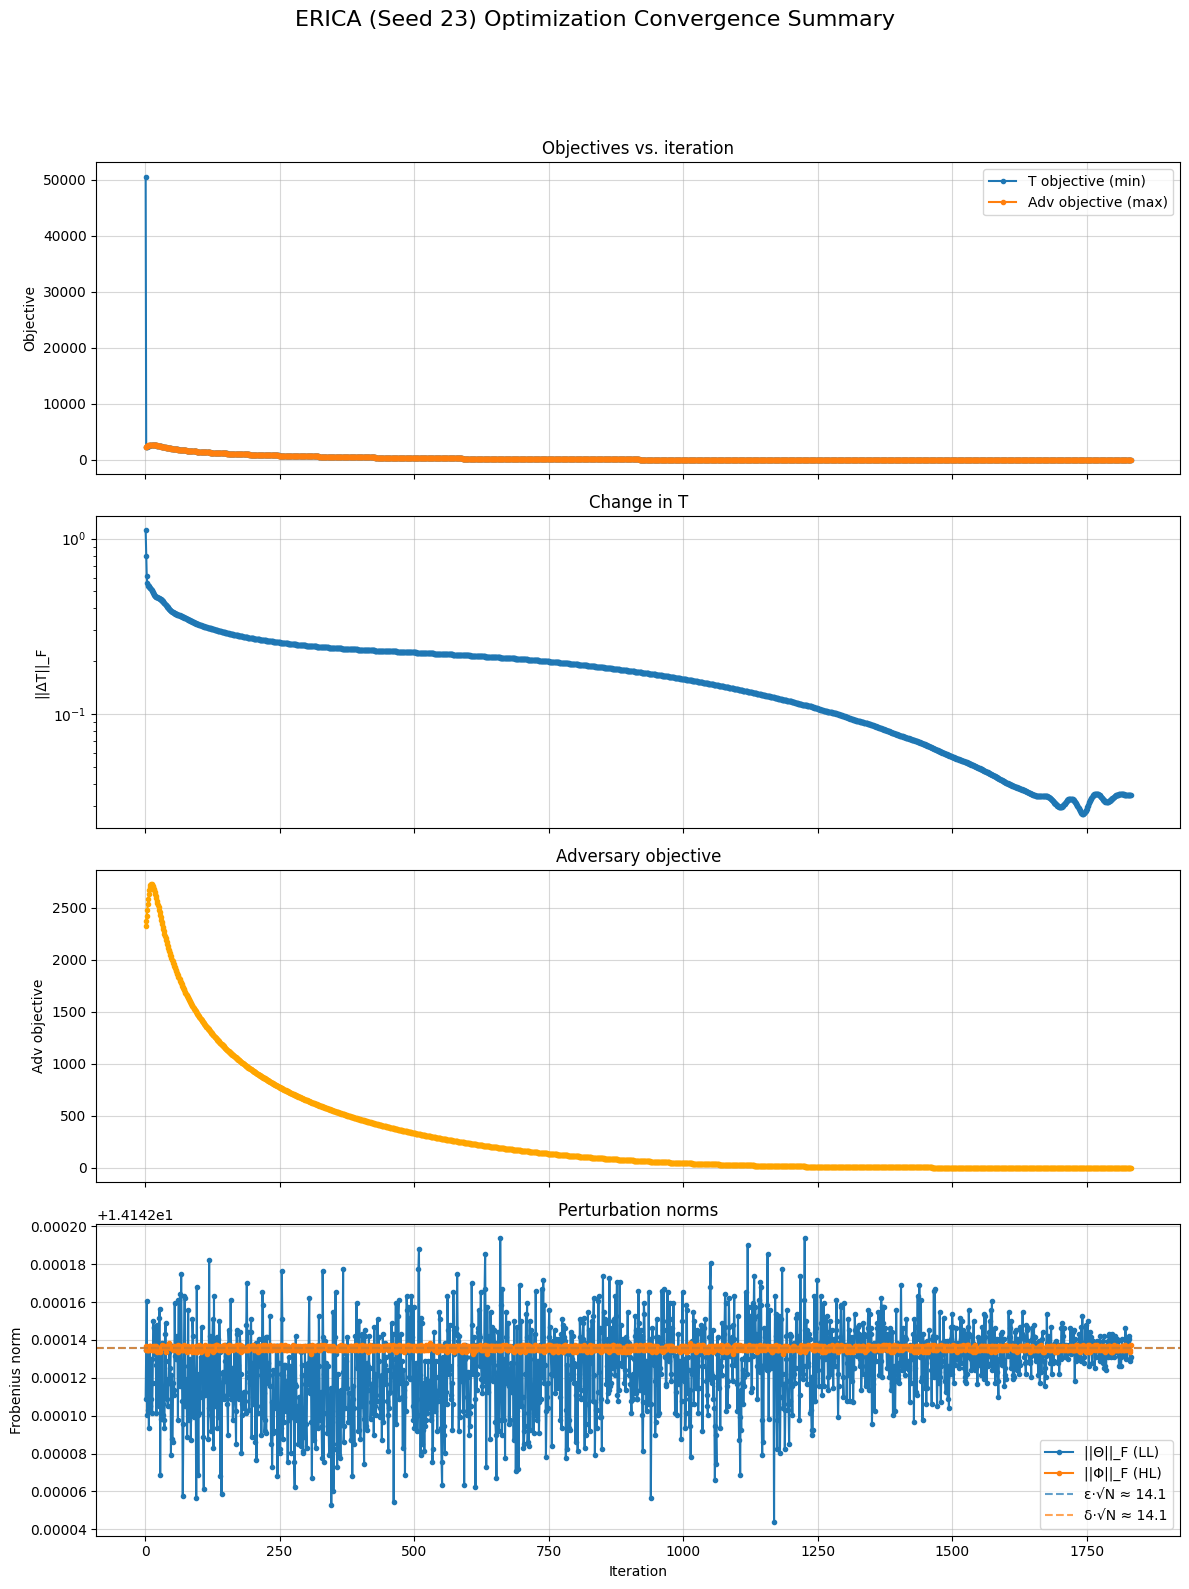


Last iteration summary:
T_objective          0.286170
adv_objective        0.287026
delta_T_norm         0.034775
theta_norm          14.142131
phi_norm            14.142138
epsilon_boundary    14.142136
delta_boundary      14.142136
  ✓ Training completed for Fold 1

--- Processing Fold 2/5 ---
Using device: cpu


ERICA Optimization:  20%|█▉        | 1951/10000 [14:01<57:51,  2.32it/s]  


Converged at iteration 1952 (Δobj < 0.0001)


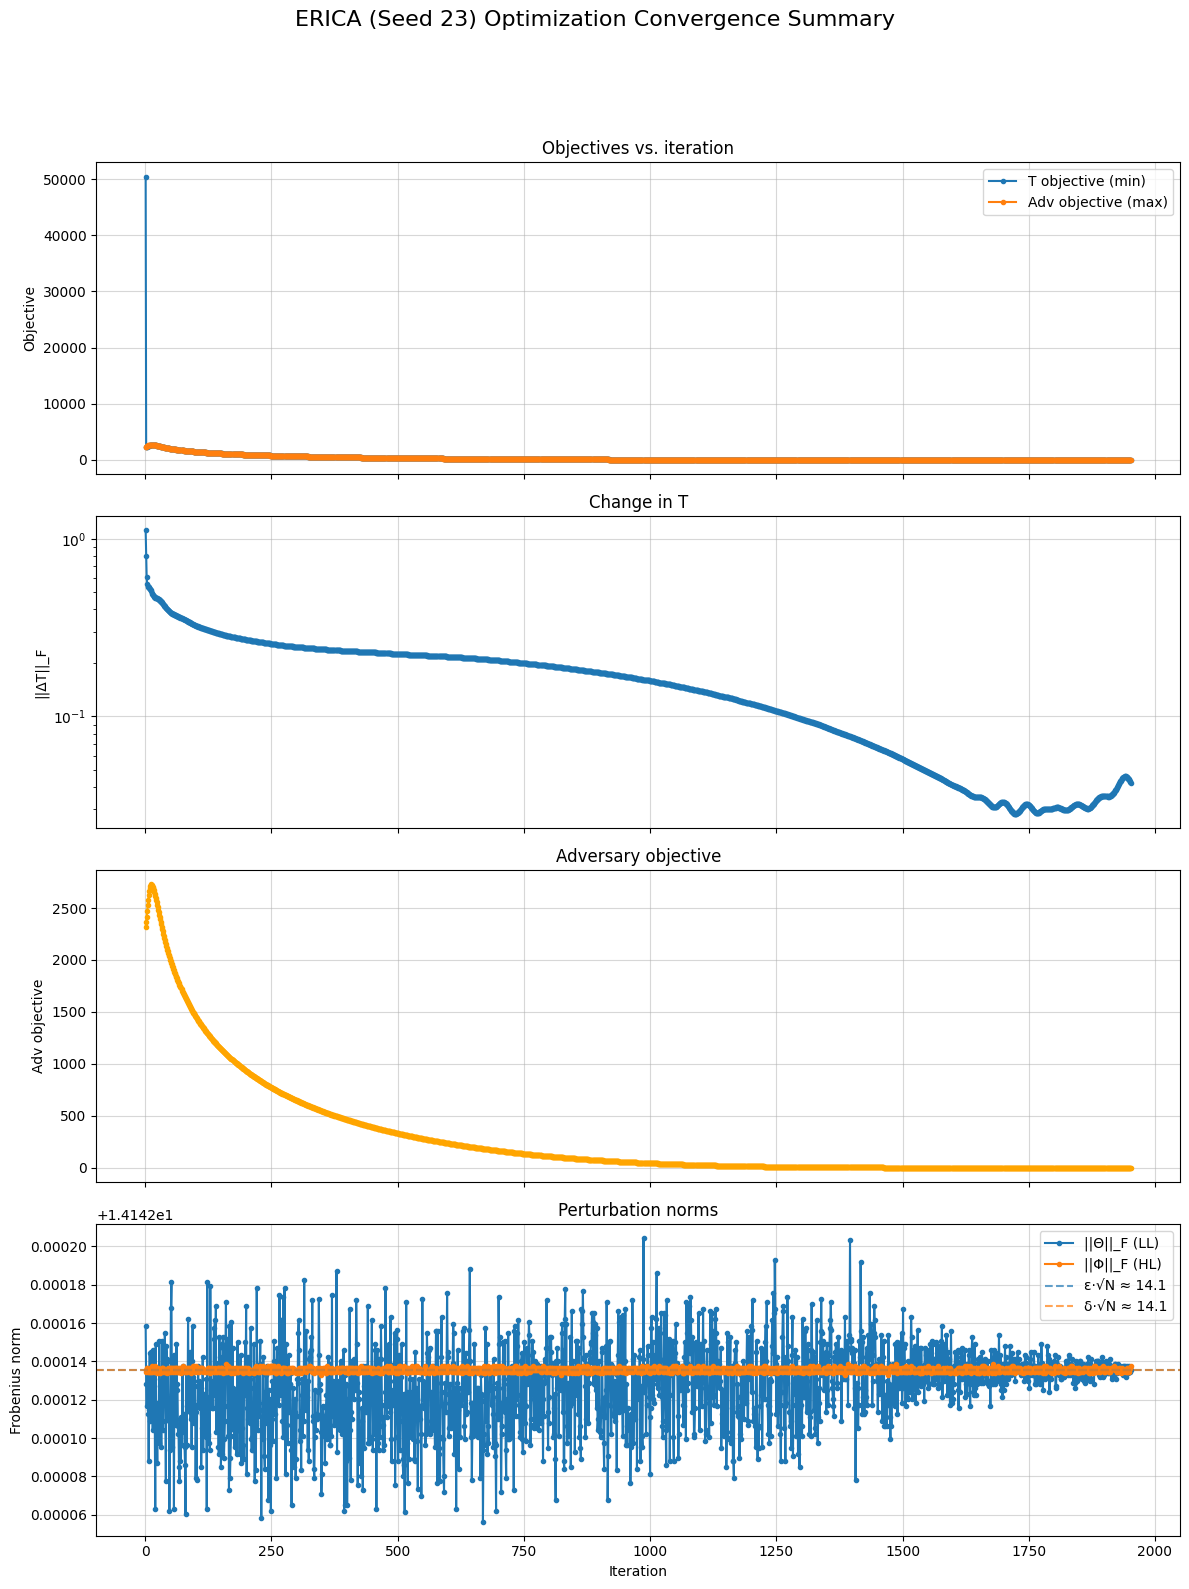


Last iteration summary:
T_objective          0.266911
adv_objective        0.267719
delta_T_norm         0.041994
theta_norm          14.142136
phi_norm            14.142138
epsilon_boundary    14.142136
delta_boundary      14.142136
  ✓ Training completed for Fold 2

--- Processing Fold 3/5 ---
Using device: cpu


ERICA Optimization:  18%|█▊        | 1802/10000 [12:55<58:49,  2.32it/s]  


Converged at iteration 1803 (Δobj < 0.0001)


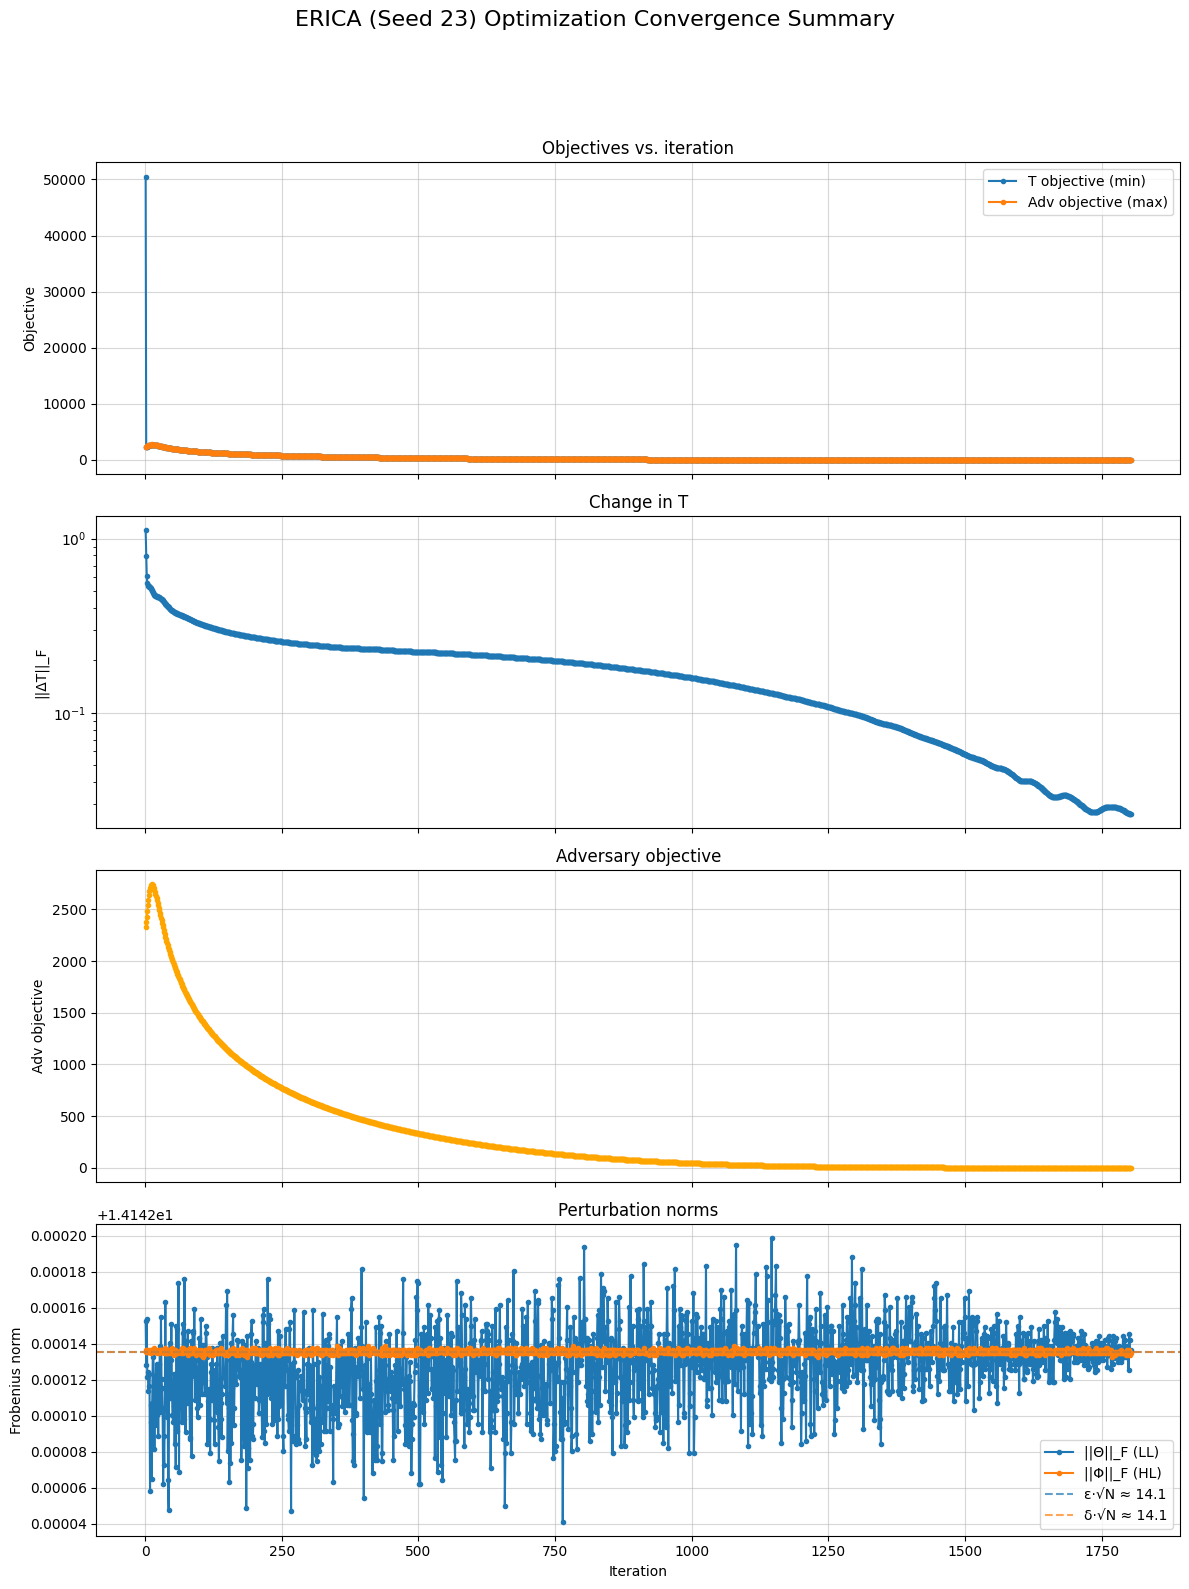


Last iteration summary:
T_objective          0.289720
adv_objective        0.290515
delta_T_norm         0.026335
theta_norm          14.142137
phi_norm            14.142135
epsilon_boundary    14.142136
delta_boundary      14.142136
  ✓ Training completed for Fold 3

--- Processing Fold 4/5 ---
Using device: cpu


ERICA Optimization:  18%|█▊        | 1781/10000 [12:36<58:09,  2.36it/s]  


Converged at iteration 1782 (Δobj < 0.0001)


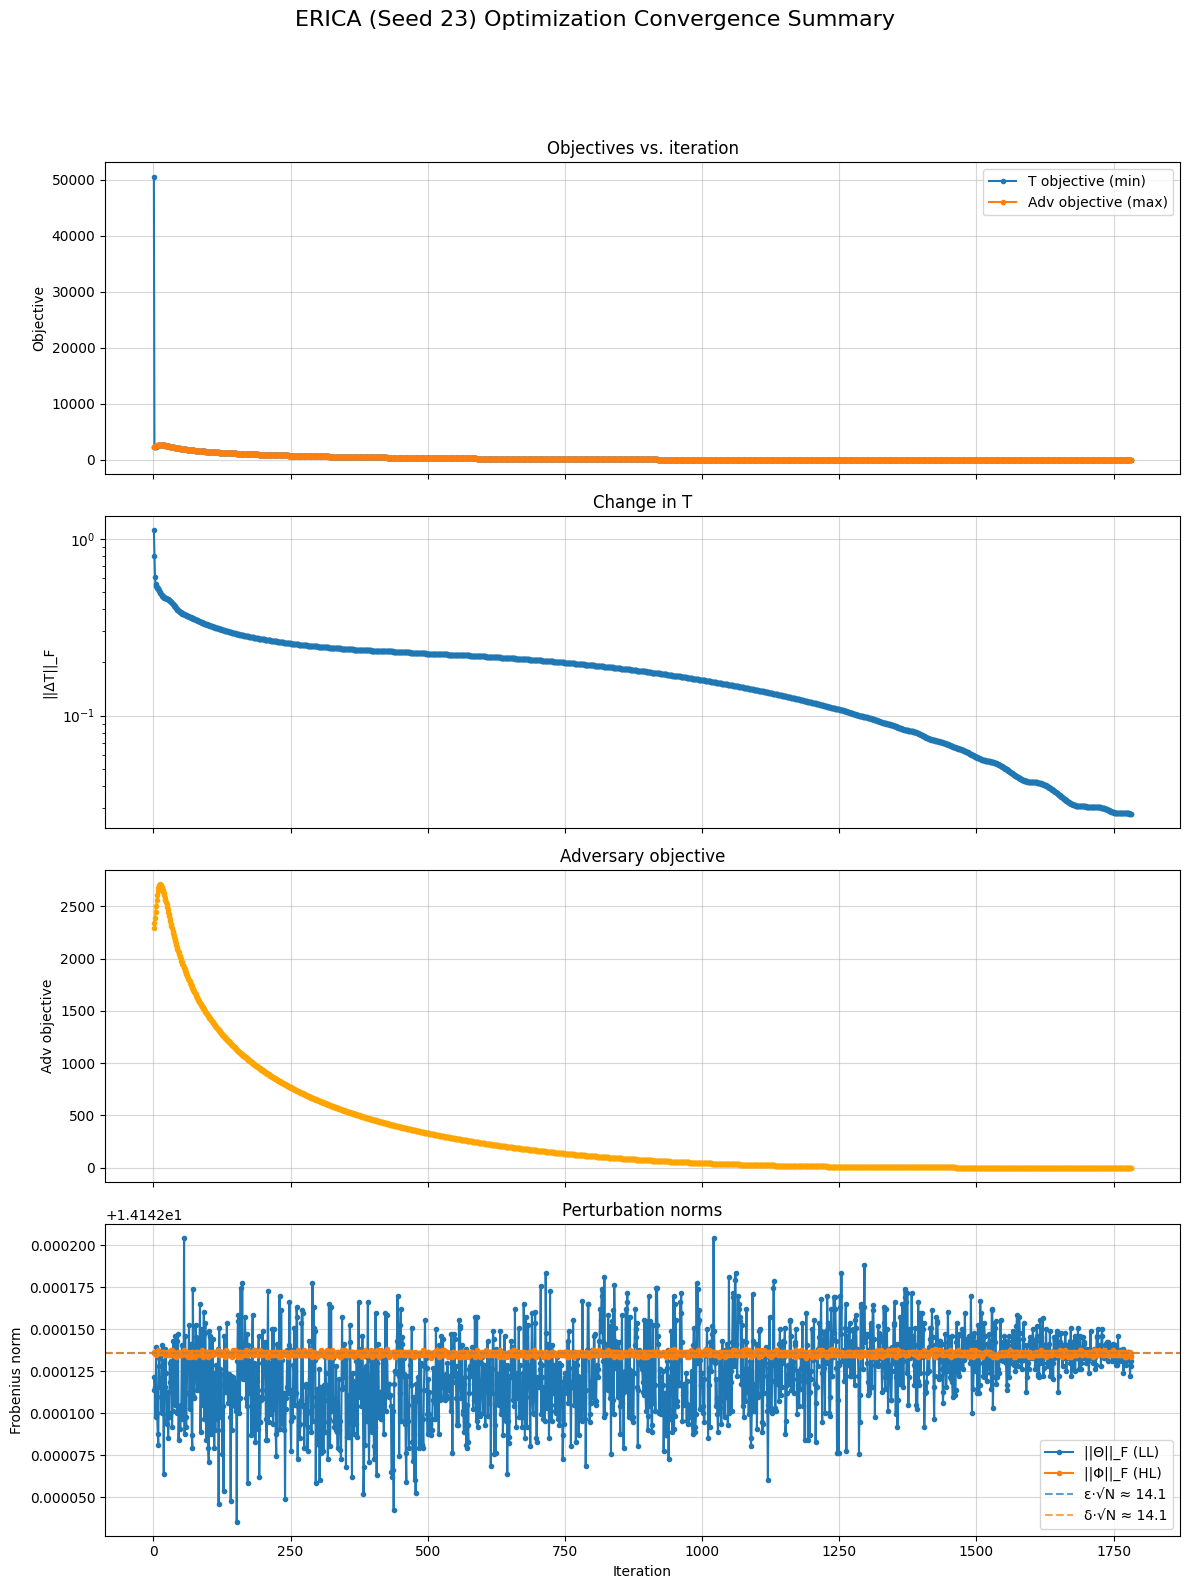


Last iteration summary:
T_objective          0.295058
adv_objective        0.295924
delta_T_norm         0.027911
theta_norm          14.142128
phi_norm            14.142135
epsilon_boundary    14.142136
delta_boundary      14.142136
  ✓ Training completed for Fold 4

--- Processing Fold 5/5 ---
Using device: cpu


ERICA Optimization:  18%|█▊        | 1802/10000 [13:31<1:01:29,  2.22it/s]


Converged at iteration 1803 (Δobj < 0.0001)


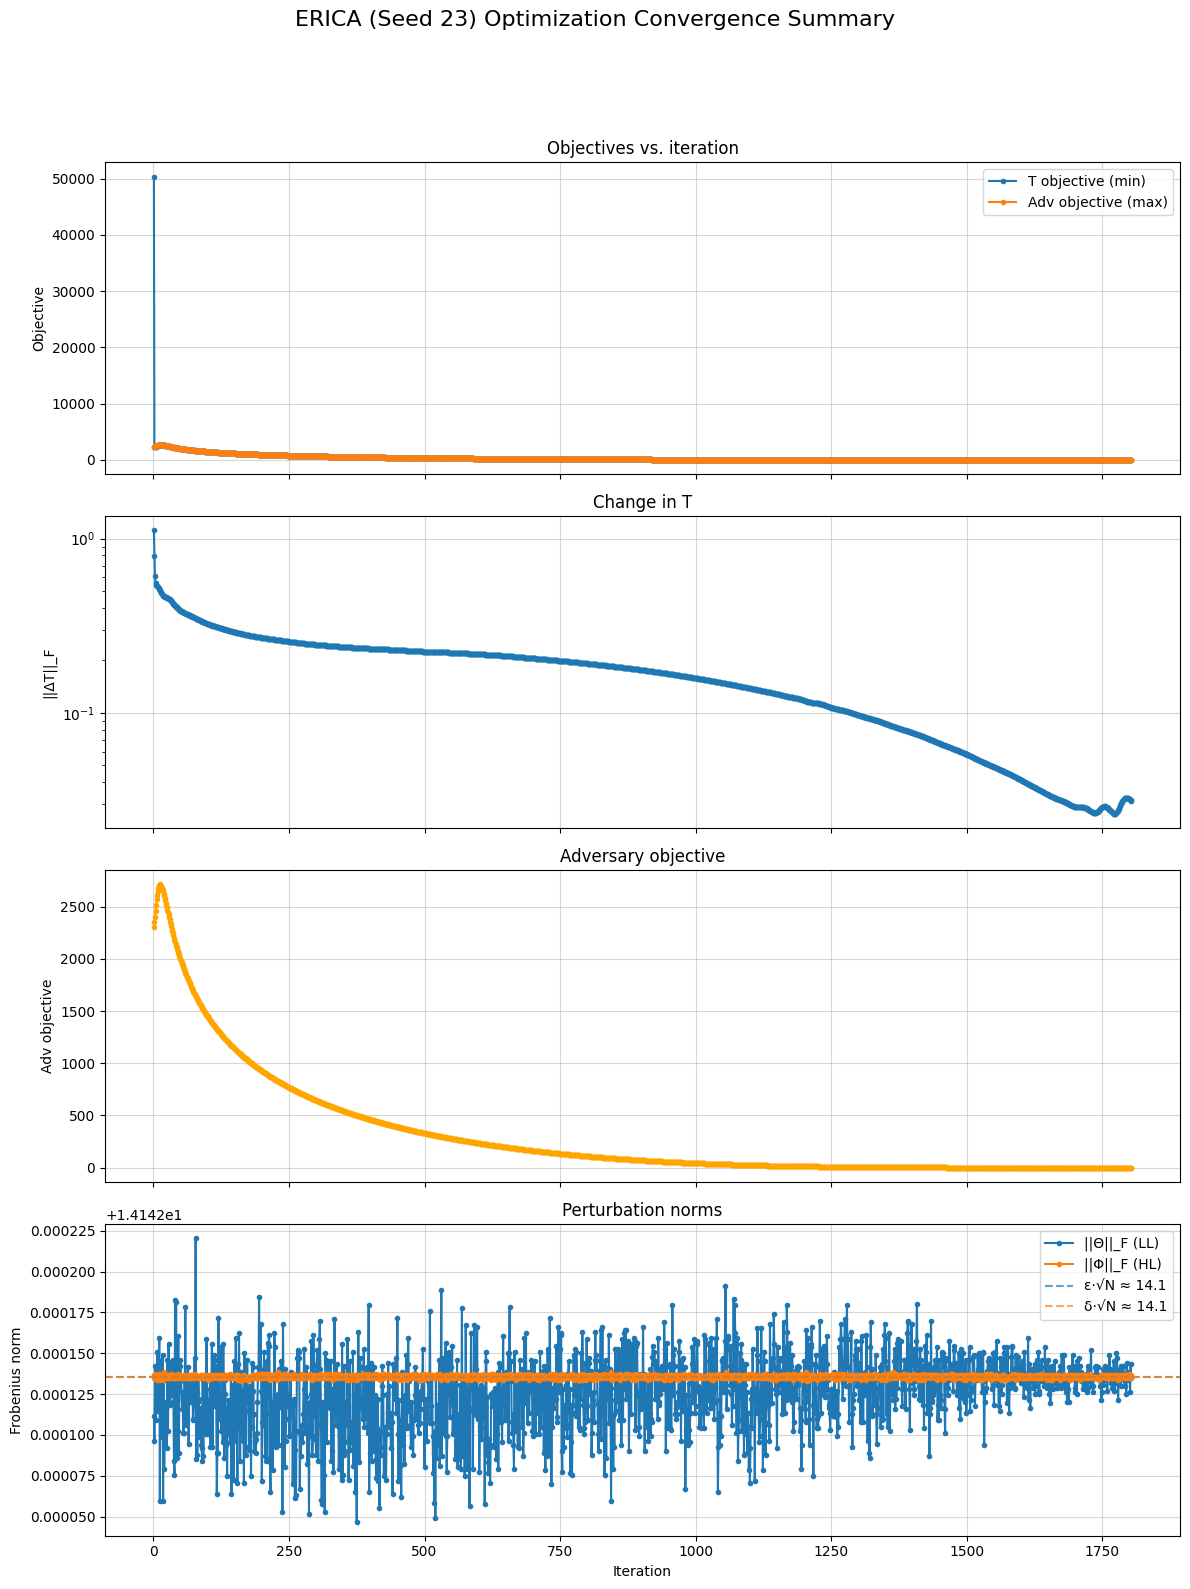


Last iteration summary:
T_objective          0.291080
adv_objective        0.291888
delta_T_norm         0.031300
theta_norm          14.142135
phi_norm            14.142135
epsilon_boundary    14.142136
delta_boundary      14.142136
  ✓ Training completed for Fold 5

DiRoCA Training complete.
✓ Completed eps_0.5_delta_0.5

DiRoCA Multi-Radius Training Complete!

Results Summary:
  ✓ eps_0.5_delta_0.5: Success


In [156]:
import torch
import numpy as np
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

print("\n" + "="*20 + " Training DiRoCA Multiple Radii " + "="*20)

# --- Hyperparameters for DiRoCA ---
diroca_hyperparams = {
    'eta_min': 1e-3,
    'eta_max': 1e-3,
    'max_iter': 10000,
    'num_steps_min': 5,
    'num_steps_max': 2,
    'initialization': 'random',
    'optimizers': 'adam'
}

fixed_params_diroca = {
    'tol': 1e-4,
    'seed': 23,
    'robust_L': True,
    'robust_H': True,
    'experiment': 'cmnist',
    'gain': 0.0
}

# --- Multiple Radii for DiRoCA ---
radius_combinations = [(0.5, 0.5)]#[(0.2, 0.2), (0.05, 0.05), (0.1, 0.1), (0.5, 0.5)]

# --- Execute Training for Multiple Radii ---
# Ensure noise tensors have the correct shape before passing
U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

# Store results for each radius combination
all_results_diroca = {}
all_monitors_diroca = {}

print(f"Running DiRoCA for {len(radius_combinations)} radius combinations...")

for i, (epsilon, delta) in enumerate(radius_combinations):
    print(f"\n--- Running DiRoCA {i+1}/{len(radius_combinations)}: ε={epsilon}, δ={delta} ---")
    
    try:
        results_diroca, monitors_diroca = train_diroca_single_run(
            cv_folds, U_ll_hat_run, U_hl_hat_run, det_ll_dict, det_hl_dict,
            omega, diroca_hyperparams, fixed_params_diroca, epsilon, delta
        )
        
        # Store results with radius key
        radius_key = f"eps_{epsilon}_delta_{delta}"
        all_results_diroca[radius_key] = results_diroca
        all_monitors_diroca[radius_key] = monitors_diroca
        
        print(f"✓ Completed {radius_key}")
        
    except Exception as e:
        print(f"✗ Failed {radius_key}: {str(e)}")
        all_results_diroca[radius_key] = None
        all_monitors_diroca[radius_key] = None

print("\n" + "="*50)
print("DiRoCA Multi-Radius Training Complete!")
print("="*50)

# --- Summary of Results ---
print("\nResults Summary:")
for radius_key, results in all_results_diroca.items():
    if results is not None:
        print(f"  ✓ {radius_key}: Success")
    else:
        print(f"  ✗ {radius_key}: Failed")

# --- Access Individual Results ---
# Example: Access results for epsilon=200, delta=200
# results_200_200 = all_results_diroca['eps_200.0_delta_200.0']
# monitors_200_200 = all_monitors_diroca['eps_200.0_delta_200.0']


==================== Training GradCA ====================
Starting GradCA Training...
Hyperparameters: {'eta_min': 0.001, 'max_iter': 5000, 'num_steps_min': 1, 'initialization': 'zeros', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---


Using device: cpu


ENRICO Optimization:  11%|█         | 530/5000 [00:26<03:46, 19.77it/s]



Converged at iteration 531 (Δobj < 0.0001)


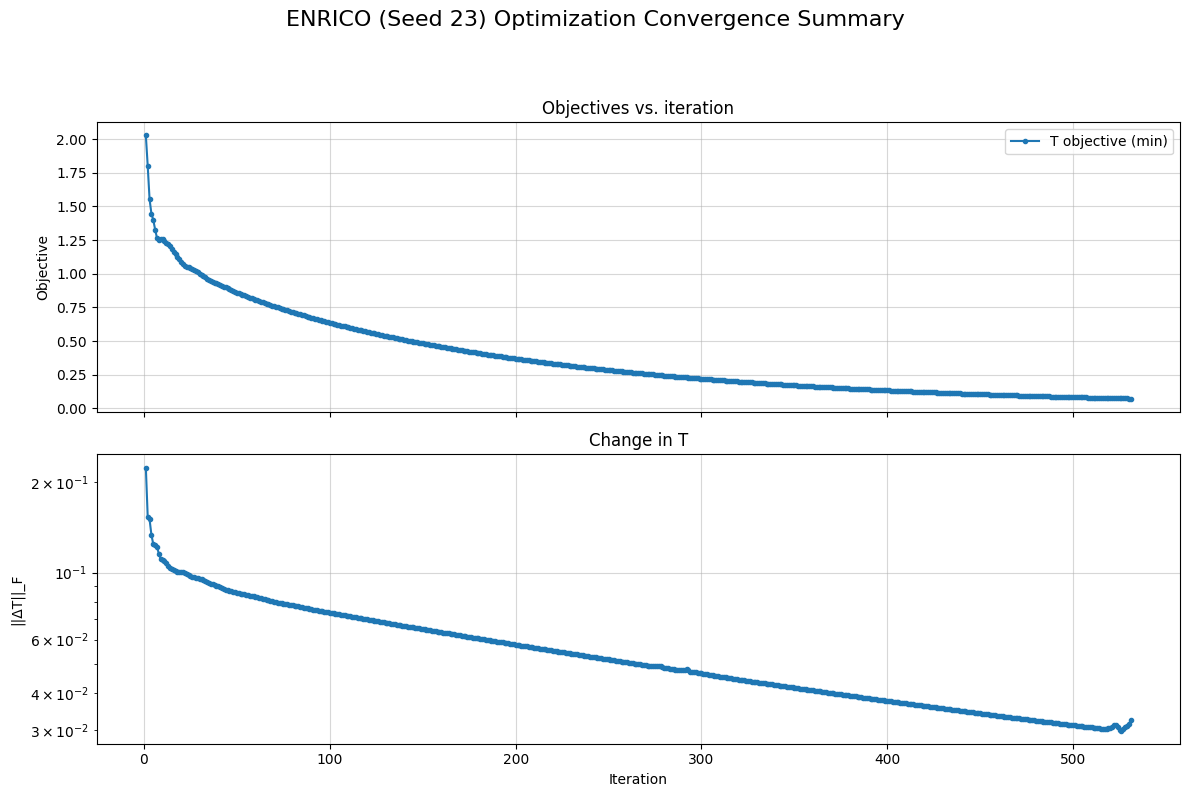


Last iteration summary:
T_objective         0.073625
adv_objective            NaN
delta_T_norm        0.032434
theta_norm               NaN
phi_norm                 NaN
epsilon_boundary         NaN
delta_boundary           NaN
  ✓ Training completed for Fold 1

GradCA Training complete.
GradCA Training finished.


In [157]:
import torch
import numpy as np
import os
import gc
import pandas as pd # Needed for monitor plots
import matplotlib.pyplot as plt # Needed for monitor plots
from tqdm import tqdm # Needed by monitor and optimizers

print("\n" + "="*20 + " Training GradCA " + "="*20)

# --- Hyperparameters for GradCA ---
gradca_hyperparams = {
    'eta_min': 1e-3,
    'max_iter': 5000, # Match DiRoCA's iterations
    'num_steps_min': 1, # Match DiRoCA's T steps
    'initialization': 'zeros', # Match DiRoCA's init
    'optimizers': 'adam'
}

fixed_params_gradca = {
    'tol': 1e-4, # Convergence tolerance
    'seed': 23,
    'experiment': 'cmnist',
    'gain': 0.1 #0.0
}

# --- Execute Training ---
# Ensure noise tensors have the correct shape before passing
U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

results_gradca, monitors_gradca = train_gradca_single_run(
    cv_folds, U_ll_hat_run, U_hl_hat_run, det_ll_dict, det_hl_dict,
    omega, gradca_hyperparams, fixed_params_gradca
)
print("GradCA Training finished.")
# Plots are generated by the monitor inside the training function


==================== Training BaryCA ====================
Starting BaryCA Training...
Hyperparameters: {'lr': 0.001, 'max_iter': 5000, 'tol': 0.0001}

--- Processing Fold 1/5 ---
Using device: cpu


BaryCA Optimization:   0%|          | 0/5000 [00:00<?, ?it/s]

BaryCA Optimization:   0%|          | 5/5000 [00:00<01:50, 45.33it/s]

Iter 0, Loss: 1450.953003


BaryCA Optimization:   4%|▍         | 216/5000 [00:02<01:01, 77.44it/s]

...

Iter 4600, Loss: 4.890896


BaryCA Optimization:  96%|█████████▌| 4810/5000 [01:11<00:02, 77.11it/s]

Iter 4800, Loss: 4.188941


BaryCA Optimization: 100%|██████████| 5000/5000 [01:14<00:00, 67.25it/s]


Final BaryCA loss: 3.586875


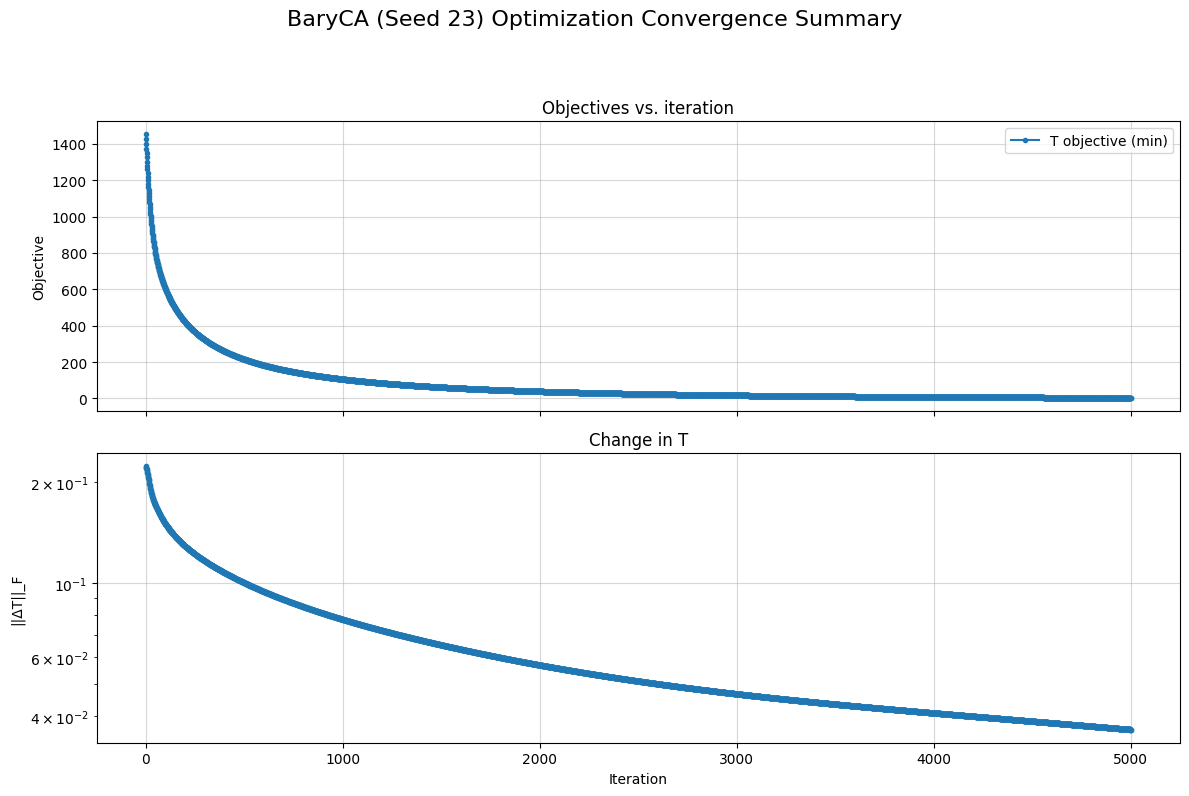


Last iteration summary:
T_objective         3.586875
adv_objective            NaN
delta_T_norm        0.036506
theta_norm               NaN
phi_norm                 NaN
epsilon_boundary         NaN
delta_boundary           NaN
  ✓ Training completed for Fold 1

BaryCA Training complete.
BaryCA Training finished.


In [158]:
import torch
import numpy as np
import os
import gc
import pandas as pd # Needed for monitor plots
import matplotlib.pyplot as plt # Needed for monitor plots
from tqdm import tqdm # Needed by monitor and optimizers

print("\n" + "="*20 + " Training BaryCA " + "="*20)

# --- Hyperparameters for BaryCA ---
baryca_hyperparams = {
    'lr': 1e-3,
    'max_iter': 5000, # Match DiRoCA's iterations
    'tol': 1e-4 # Use a potentially stricter tolerance
}

fixed_params_baryca = {
    'seed': 23
}

# --- Execute Training ---
# Ensure noise tensors have the correct shape before passing
U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

results_baryca, monitors_baryca = train_baryca_single_run(
    cv_folds, U_ll_hat_run, U_hl_hat_run, det_ll_dict, det_hl_dict,
    omega, baryca_hyperparams, fixed_params_baryca
)
print("BaryCA Training finished.")
# Plots are generated by the monitor inside the training function

In [159]:
print('done!!!!')

done!!!!


In [160]:
# --- Wrapper for Abs-LiNGAM (LS abstraction baseline) ---
import torch
import torch.nn.functional as F

def _get_obs_ll(Dll):
    # prefer 'obs'; else None alias; else first key
    if "obs" in Dll: return Dll["obs"]
    if None in Dll:  return Dll[None]
    # last resort: first item
    return next(iter(Dll.values()))

def _get_obs_hl(Dhl):
    if "obs" in Dhl: return Dhl["obs"]
    if None in Dhl:  return Dhl[None]
    return next(iter(Dhl.values()))

def train_abslingam_single_run(cv_folds, Dll_samples, Dhl_samples, run_hyperparams):
    """
    Run the LS-based 'Abs-LiNGAM' baseline on observational data only, across CV folds.
    Returns: {'abslingam': {'fold_i': {...}, ...}}
    """
    print("Starting Abs-LiNGAM Training (LS abstraction baseline)...")
    print(f"Hyperparameters: {run_hyperparams}")  # thresholds

    tau_p = float(run_hyperparams.get('tau_perfect', 1e-2))
    tau_n = float(run_hyperparams.get('tau_noisy',   1e-1))

    abslingam_training_results = {}

    # observational tensors
    ll_obs_tuple = _get_obs_ll(Dll_samples)  # (images, shapes, digits, colors)
    hl_obs_full  = _get_obs_hl(Dhl_samples)  # (N, d_hl)

    for i, fold_info in enumerate(cv_folds):
        fold_key = f'fold_{i}'
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        try:
            train_idx = fold_info['train']
            test_idx  = fold_info['test']
        except KeyError as e:
            print(f"  ✗ Fold spec missing key: {e}")
            abslingam_training_results[fold_key] = {'error': f'missing {e}'}
            continue

        try:
            # LL pieces (observational, train slice)
            final_images = ll_obs_tuple[0][train_idx]   # (n, 3, H, W) in [0,1]
            digits       = ll_obs_tuple[2][train_idx]   # (n,)
            colors       = ll_obs_tuple[3][train_idx]   # (n,)

            # HL observational, train slice
            Dhl_obs_tr   = hl_obs_full[train_idx]       # (n, d_hl)

            # Reconstruct full LL vectors (pixels + one-hots)
            images_flat   = final_images.reshape(final_images.shape[0], -1)
            digits_onehot = F.one_hot(digits, num_classes=10).float()
            colors_onehot = F.one_hot(colors, num_classes=10).float()
            Dll_obs_tr    = torch.cat([images_flat, digits_onehot, colors_onehot], dim=1)  # (n, d_ll)

            # Run LS-based abstractions
            abs_run = run_abs_lingam_cmnist(Dll_obs_tr, Dhl_obs_tr, tau_perfect=tau_p, tau_noisy=tau_n)

            fold_res = {}
            if abs_run['Perfect']['T'] is not None:
                fold_res['Abs-LiNGAM (Perfect)'] = {
                    'T_matrix': torch.tensor(abs_run['Perfect']['T'], dtype=torch.float32),
                    'test_indices': test_idx
                }
            else:
                fold_res['Abs-LiNGAM (Perfect)'] = {'error': 'Calculation Failed'}

            if abs_run['Noisy']['T'] is not None:
                fold_res['Abs-LiNGAM (Noisy)'] = {
                    'T_matrix': torch.tensor(abs_run['Noisy']['T'], dtype=torch.float32),
                    'test_indices': test_idx
                }
            else:
                fold_res['Abs-LiNGAM (Noisy)'] = {'error': 'Calculation Failed'}

            abslingam_training_results[fold_key] = fold_res
            print(f"  ✓ Computation completed for Fold {i+1}")
        
        except Exception as e:
            print(f"  ✗ ERROR during computation for Fold {i+1}: {e}")
            abslingam_training_results[fold_key] = {'error': str(e)}
        break
    print("\nAbs-LiNGAM computation complete.")
    return {'abslingam': abslingam_training_results}


In [161]:
import numpy as np
import torch

def perfect_abstraction(px_samples, py_samples, tau_threshold=1e-2):
    """
    LS 'perfect' abstraction: T = pinv(X) Y  (X: N×d_ll, Y: N×d_hl) -> d_ll×d_hl
    Threshold very small coefficients.
    """
    X = np.asarray(px_samples, dtype=np.float64)
    Y = np.asarray(py_samples, dtype=np.float64)
    T = np.linalg.pinv(X) @ Y                       # (d_ll × d_hl)
    M = (np.abs(T) > float(tau_threshold))
    return (T * M)

def noisy_abstraction(px_samples, py_samples, tau_threshold=1e-1, refit_coeff=False):
    """
    LS 'noisy' abstraction: keep, per low-level coordinate, the strongest HL target (argmax |T|),
    optionally refit coefficients in selected blocks.
    """
    X = np.asarray(px_samples, dtype=np.float64)
    Y = np.asarray(py_samples, dtype=np.float64)
    T_hat = np.linalg.pinv(X) @ Y                   # (d_ll × d_hl)

    d_ll, d_hl = T_hat.shape
    # one-hot of argmax per row (winner HL dim per LL coordinate)
    winners = np.argmax(np.abs(T_hat), axis=1)      # (d_ll,)
    mask = np.zeros_like(T_hat, dtype=int)
    mask[np.arange(d_ll), winners] = 1
    # prune tiny values as well
    mask = mask * (np.abs(T_hat) > float(tau_threshold)).astype(int)

    if refit_coeff:
        # refit each HL column on selected LL rows
        T_refit = T_hat.copy()
        for j in range(d_hl):
            rows = np.where(mask[:, j] == 1)[0]
            if rows.size > 0:
                Xb = X[:, rows]                   # (N × |rows|)
                yj = Y[:, j]                      # (N,)
                T_refit[rows, j] = np.linalg.pinv(Xb) @ yj
        T_hat = T_refit

    return mask * T_hat

def run_abs_lingam_cmnist(Dll_obs_full, Dhl_obs_full, tau_perfect=1e-2, tau_noisy=1e-1):
    """
    Resolution-agnostic LS abstraction.
    Returns T matrices with shape (d_hl × d_ll), i.e., mapping LL -> HL as used elsewhere (pred = X_ll @ T^T).
    """
    # to numpy if tensors
    if isinstance(Dll_obs_full, torch.Tensor): Dll_obs_full = Dll_obs_full.detach().cpu().numpy()
    if isinstance(Dhl_obs_full, torch.Tensor): Dhl_obs_full = Dhl_obs_full.detach().cpu().numpy()

    N_ll, d_ll = Dll_obs_full.shape
    N_hl, d_hl = Dhl_obs_full.shape
    if N_ll != N_hl:
        raise ValueError(f"N mismatch: LL={N_ll}, HL={N_hl}")

    try:
        T_perfect_raw = perfect_abstraction(Dll_obs_full, Dhl_obs_full, tau_threshold=tau_perfect)  # d_ll×d_hl
        T_noisy_raw   = noisy_abstraction(  Dll_obs_full, Dhl_obs_full, tau_threshold=tau_noisy, refit_coeff=False)

        # store as (d_hl × d_ll) to match your other code (pred = X @ T^T)
        return {
            'Perfect': {'T': T_perfect_raw.T.astype(np.float32)},
            'Noisy':   {'T': T_noisy_raw.T.astype(np.float32)}
        }
    except Exception as e:
        print(f"ERROR during LS abstraction: {e}")
        return {'Perfect': {'T': None}, 'Noisy': {'T': None}}


In [162]:
import torch
import numpy as np

print("\n" + "="*20 + " Training Abs-LiNGAM " + "="*20)

abslingam_hyperparams = {
    'tau_perfect': 1e-2,
    'tau_noisy':   1e-1,
}

# expects: cv_folds, Dll_samples, Dhl_samples already defined
results_abslingam = train_abslingam_single_run(
    cv_folds=cv_folds,
    Dll_samples=Dll_samples,
    Dhl_samples=Dhl_samples,
    run_hyperparams=abslingam_hyperparams,
)

print("Abs-LiNGAM training finished.")



==================== Training Abs-LiNGAM ====================
Starting Abs-LiNGAM Training (LS abstraction baseline)...
Hyperparameters: {'tau_perfect': 0.01, 'tau_noisy': 0.1}

--- Processing Fold 1/5 ---
  ✓ Computation completed for Fold 1

Abs-LiNGAM computation complete.
Abs-LiNGAM training finished.


In [65]:
# --- Pick a specific DiRoCA run by (eps, delta) ---
import re, math, numpy as np, torch
import matplotlib.pyplot as plt

target_eps, target_delta = 0.5, 0.5   # << change here

def _parse_key(k):
    # expects like: diroca_eps_0.2_delta_0.2  (but is tolerant to 0_2, .5, etc.)
    m = re.search(r"diroca_eps_([0-9_.]+)_delta_([0-9_.]+)", k)
    if not m: return None
    e = float(m.group(1).replace('_', '.'))
    d = float(m.group(2).replace('_', '.'))
    return e, d

def _closest_diroca_key(results, eps, delta):
    candidates = []
    for k in results.keys():
        parsed = _parse_key(k)
        if parsed is None: continue
        e, d = parsed
        candidates.append((k, e, d, (e-eps)**2 + (d-delta)**2))
    if not candidates: return None, None, None
    k_best, e_best, d_best, _ = min(candidates, key=lambda t: t[3])
    return k_best, e_best, d_best

# find the best matching top-level key
diroca_key_toplevel, e_found, d_found = _closest_diroca_key(all_results, target_eps, target_delta)
if diroca_key_toplevel is None:
    raise RuntimeError("No DiRoCA keys found in all_results.")
print(f"Using DiRoCA results: {diroca_key_toplevel} (found eps={e_found}, delta={d_found})")

# ----- the rest is the same as your current viz, just reusing diroca_key_toplevel -----
fold_key_to_show = 'fold_0'
fold_data = all_results[diroca_key_toplevel][fold_key_to_show]

# Prefer a matching inner run key if multiple exist (e.g., 'eps_0.5_delta_0.5')
def _parse_inner(k):
    m = re.search(r"eps_([0-9_.]+)_delta_([0-9_.]+)", k)
    if not m: return None
    return float(m.group(1).replace('_','.')), float(m.group(2).replace('_','.'))

run_keys = [k for k in fold_data.keys() if k.startswith('eps_')]
if not run_keys:
    raise RuntimeError(f"No inner 'eps_*' run keys in {diroca_key_toplevel}/{fold_key_to_show}")

# choose inner key closest to (target_eps, target_delta)
rk = min(run_keys, key=lambda k: (lambda p: (p[0]-target_eps)**2 + (p[1]-target_delta)**2)(_parse_inner(k)))
print(f"Using run key: {rk}")
run_result = fold_data[rk]

# === from here, reuse your existing plotting code (final_Theta_ll, U_ll_train, det_ll_dict, etc.) ===
final_Theta_ll = run_result.get('final_Theta_ll')
if not isinstance(final_Theta_ll, torch.Tensor):
    final_Theta_ll = torch.tensor(final_Theta_ll, dtype=torch.float32)

epsilon_run = run_result.get('epsilon', e_found)  # for the title
fold_index = int(fold_key_to_show.split('_')[-1])
train_indices = cv_folds[fold_index]['train']

# ... (your existing preparation + the 7-column plot you just used) ...


Using DiRoCA results: diroca_eps_0.5_delta_0.0 (found eps=0.5, delta=0.0)
Using run key: eps_0.5_delta_0.0


In [28]:
# --- Extended Visualization with Δ heatmap + amplified D+U+αΘ ---
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

alpha = 8.0  # purely for visualization scaling of Θ
num_cols = 7  # D, U, Θ, D+U, D+U+Θ, Δ heatmap, amplified D+U+αΘ

fig, axes = plt.subplots(num_samples_to_show, num_cols, figsize=(28, 4 * num_samples_to_show))
if num_samples_to_show == 1:
    axes = np.array([axes])

fig.suptitle(
    f'Adversarial Perturbations ({diroca_key_toplevel}, {fold_key_to_show}) — ε={epsilon_run}',
    fontsize=16, y=1.02
)

def _flat_to_hwc(xflat):
    if not isinstance(xflat, torch.Tensor):
        xflat = torch.tensor(xflat, dtype=torch.float32)
    x = xflat.detach().cpu().float()
    s = x.numel() // 3
    H = W = int(math.isqrt(s))
    return x.view(3, H, W).permute(1, 2, 0).numpy()

for i, idx in enumerate(sample_indices):
    ref_flat = det_pixels_train[idx]

    # D (deterministic)
    axes[i, 0].imshow(_disp_with_bg(det_pixels_train[idx], ref_flat), interpolation='nearest')
    axes[i, 0].set_title('D (deterministic)'); axes[i, 0].axis('off')

    # U (abduced)
    imgU = _to_noise(U_ll_train[idx])
    axes[i, 1].imshow(_noise_to_rgb01(imgU), interpolation='nearest')
    axes[i, 1].set_title('U (abduced)'); axes[i, 1].axis('off')

    # Θ (worst-case)
    imgT = _to_noise(final_Theta_ll[idx])
    axes[i, 2].imshow(_noise_to_rgb01(imgT), interpolation='nearest')
    axes[i, 2].set_title('Θ (worst-case)'); axes[i, 2].axis('off')

    # D + U
    axes[i, 3].imshow(_disp_with_bg(clean_recon_pixels[idx], ref_flat), interpolation='nearest')
    axes[i, 3].set_title('D + U'); axes[i, 3].axis('off')

    # D + U + Θ
    axes[i, 4].imshow(_disp_with_bg(worst_case_pixels[idx], ref_flat), interpolation='nearest')
    axes[i, 4].set_title('D + U + Θ'); axes[i, 4].axis('off')

    # Δ = Θ effect heatmap
    x_clean = clean_recon_pixels[idx]
    x_wc = worst_case_pixels[idx]
    delta = (x_wc - x_clean)
    delta_img = _flat_to_hwc(delta)
    abs_mag = np.abs(delta_img).reshape(-1, delta_img.shape[-1]).mean(axis=1)
    lim = np.percentile(abs_mag, 99)
    lim = max(lim, 1e-6)
    axes[i, 5].imshow(delta_img, cmap='RdBu_r', vmin=-lim, vmax=lim, interpolation='nearest')
    axes[i, 5].set_title('Δ = Θ effect'); axes[i, 5].axis('off')

    # D + U + αΘ (amplified for visibility)
    x_wc_amp = x_clean + alpha * (final_Theta_ll[idx])
    axes[i, 6].imshow(_to_img01(x_wc_amp), interpolation='nearest')
    axes[i, 6].set_title(f'D + U + αΘ (α={alpha:g})'); axes[i, 6].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()
print("✓ Extended visualization completed successfully!")


NameError: name 'num_samples_to_show' is not defined

In [29]:
# === Numeric summary for each displayed sample ===
import numpy as np
import torch
import pandas as pd
import math
from matplotlib import pyplot as plt

def _flat_to_img(xflat):
    """(3HW,) tensor -> H,W,3 float32 (no scaling)."""
    if not isinstance(xflat, torch.Tensor):
        xflat = torch.tensor(xflat, dtype=torch.float32)
    x = xflat.detach().cpu().float()
    s = x.numel() // 3
    H = W = int(math.isqrt(s))
    return x.view(3, H, W).permute(1, 2, 0).numpy()

def _mean_std01(xflat):
    """Return mean/std of the (potentially [-1,1]) image after mapping to [0,1]."""
    arr = _flat_to_img(xflat)
    mn, mx = float(arr.min()), float(arr.max())
    if mn >= -1.05 and mx <= 1.05:
        arr = (arr + 1.0) / 2.0
    elif mn < 0.0 or mx > 1.0:
        rng = (mx - mn) if mx > mn else 1.0
        arr = (arr - mn) / rng
    arr = np.clip(arr, 0.0, 1.0)
    return float(arr.mean()), float(arr.std())

def _norms(vec, p=2):
    """Return L2 and Linf norms (per pixel normalized L2 as L2/√(3HW))."""
    if not isinstance(vec, torch.Tensor):
        vec = torch.tensor(vec, dtype=torch.float32)
    v = vec.detach().cpu().float().view(-1)
    l2 = float(torch.linalg.vector_norm(v, ord=2))
    linf = float(torch.max(torch.abs(v)))
    d = v.numel()
    l2_perpix = l2 / math.sqrt(d) if d > 0 else 0.0
    return l2, l2_perpix, linf

def _mse(a, b):
    if not isinstance(a, torch.Tensor): a = torch.tensor(a, dtype=torch.float32)
    if not isinstance(b, torch.Tensor): b = torch.tensor(b, dtype=torch.float32)
    diff = (a.detach().cpu().float() - b.detach().cpu().float()).view(-1)
    return float(torch.mean(diff*diff))

rows = []
H = W = int(math.isqrt(det_pixels_train.shape[1] // 3))
D = 3 * H * W

# Adaptive “meaningful change” threshold: 99th percentile of |Θ| across the shown rows (fallback=0.02)
abs_theta_all = []
for idx in sample_indices:
    abs_theta_all.append(np.abs(_flat_to_img(final_Theta_ll[idx])).reshape(-1, 3).mean(axis=1))
abs_theta_all = np.concatenate(abs_theta_all) if len(abs_theta_all) else np.array([0.0])
tau = max(np.percentile(abs_theta_all, 99), 0.02)

for idx in sample_indices:
    # vectors
    d_vec   = det_pixels_train[idx]
    u_vec   = U_ll_train[idx]
    th_vec  = final_Theta_ll[idx]
    clean   = clean_recon_pixels[idx]
    worst   = worst_case_pixels[idx]
    delta   = worst - clean  # == th_vec

    # image stats (mapped to [0,1])
    d_mean, d_std       = _mean_std01(d_vec)
    du_mean, du_std     = _mean_std01(clean)
    duT_mean, duT_std   = _mean_std01(worst)

    # perturbation norms
    u_l2, u_l2px, u_linf     = _norms(u_vec)
    th_l2, th_l2px, th_linf  = _norms(th_vec)
    de_l2, de_l2px, de_linf  = _norms(delta)

    # magnitude & sparsity of change
    delta_img = _flat_to_img(delta)         # HxWx3
    abs_mag   = np.abs(delta_img).reshape(-1, 3).mean(axis=1)  # per-pixel mean over channels
    frac_changed = float((abs_mag > tau).mean())

    # similarity between clean and worst (MSE)
    mse_c_w = _mse(clean, worst)

    rows.append({
        "sample_idx": int(idx),
        "D_mean": d_mean, "D_std": d_std,
        "D+U_mean": du_mean, "D+U_std": du_std,
        "D+U+Θ_mean": duT_mean, "D+U+Θ_std": duT_std,
        "‖U‖₂/√(3HW)": u_l2px, "‖Θ‖₂/√(3HW)": th_l2px,
        "‖Δ‖₂/√(3HW)": de_l2px, "max|Δ|": de_linf,
        f"frac(|Δ|>{tau:.3f})": frac_changed,
        "MSE(clean,worst)": mse_c_w,
    })

df = pd.DataFrame(rows).set_index("sample_idx")
display(df.round(4))

# Optional: annotate a short line of text under each plotted row if the figure from above still exists
try:
    for r, idx in enumerate(sample_indices):
        s = df.loc[int(idx)]
        text = (f"‖U‖₂/√= {s['‖U‖₂/√(3HW)']:.4f}  |  "
                f"‖Θ‖₂/√= {s['‖Θ‖₂/√(3HW)']:.4f}  |  "
                f"MSE(clean,worst)= {s['MSE(clean,worst)']:.5f}  |  "
                f"chg>{tau:.3f}= {s[f'frac(|Δ|>{tau:.3f})']:.2%}")
        # place under the last column of the existing figure (axes from your plot must be in scope)
        ax_last = axes[r, -1]
        ax_last.text(0.5, -0.15, text, ha="center", va="top", fontsize=9, transform=ax_last.transAxes)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()
except Exception:
    pass


NameError: name 'det_pixels_train' is not defined

In [30]:
# Add after the df is built
pixels = 3 * H * W
per_pixel_cap = epsilon_run / math.sqrt(pixels) if isinstance(epsilon_run, (int,float)) else float('nan')
df["Θ_perpix / cap"] = df["‖Θ‖₂/√(3HW)"] / per_pixel_cap

# Global Frobenius cap (per-sample equivalent): ε; report our per-sample L2 ≈ df["‖Θ‖₂/√(3HW)"] * √(3HW)
df["‖Θ‖₂ (per-sample)"] = df["‖Θ‖₂/√(3HW)"] * math.sqrt(pixels)
df["‖Θ‖₂ / ε (per-sample)"] = df["‖Θ‖₂ (per-sample)"] / (epsilon_run if isinstance(epsilon_run, (int,float)) else float('nan'))

display(df.round(4))


NameError: name 'epsilon_run' is not defined

ValueError: all input arrays must have the same shape

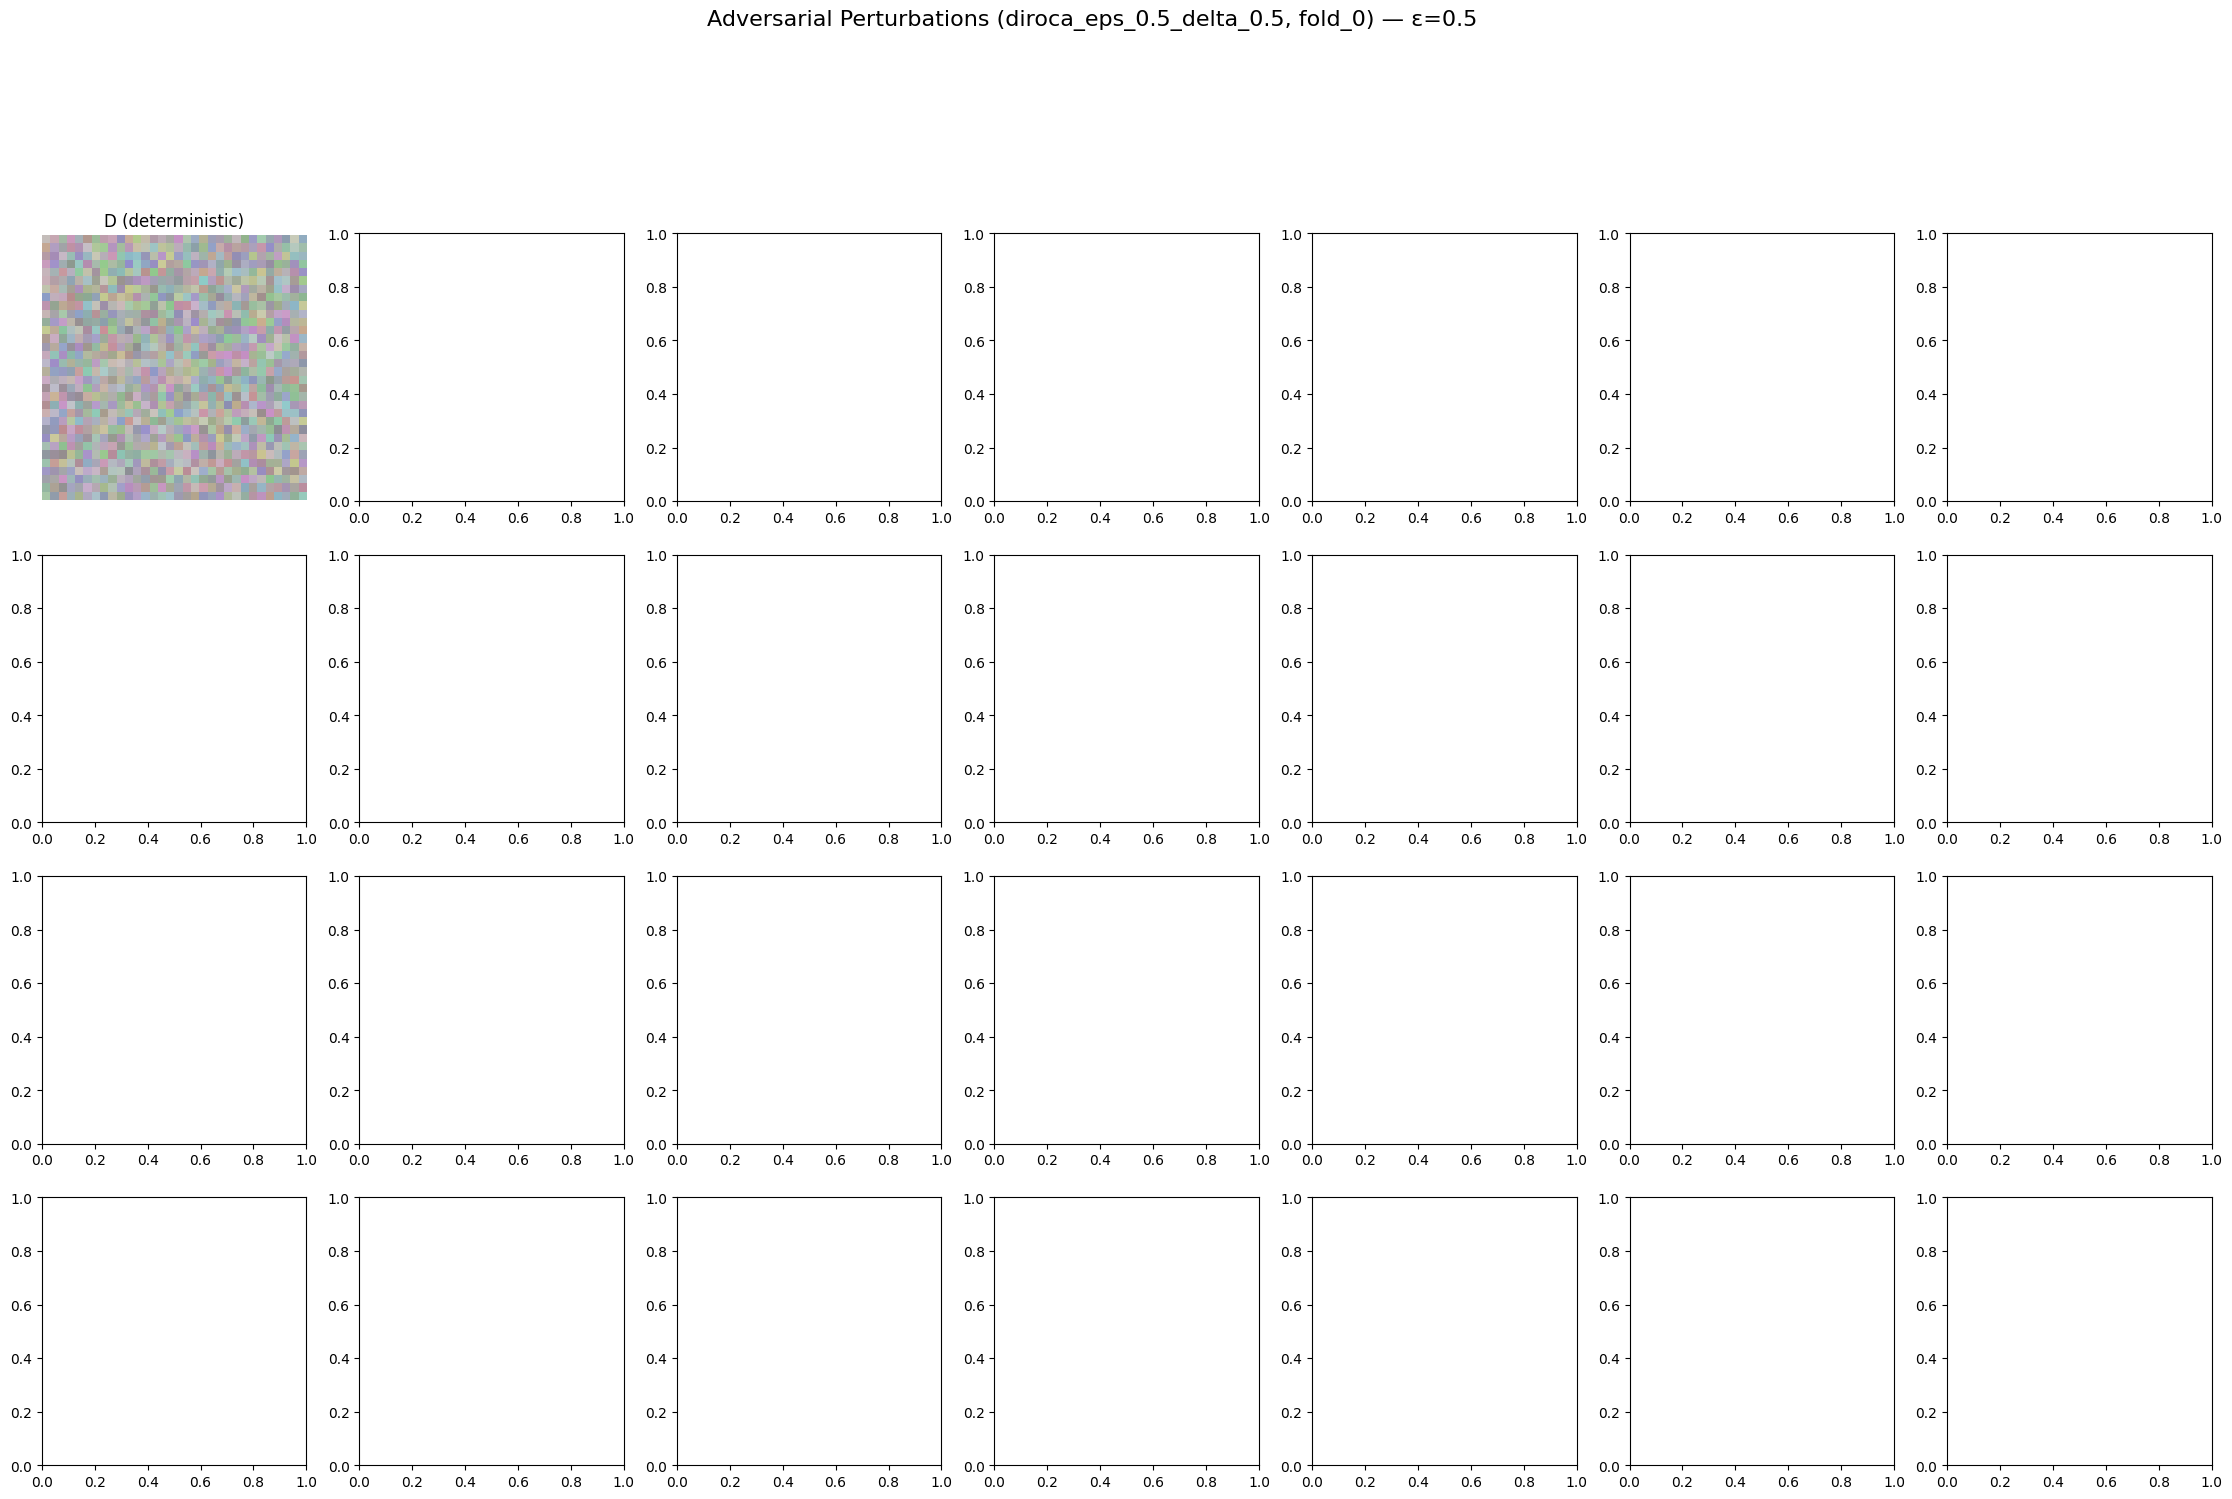

In [31]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- 1. Helper functions (Reconstructed from your code/traceback) ---
#    (These would normally be in other cells)

def _flat_to_hwc(xflat):
    """Converts a flat (3*H*W,) vector to (H,W,3) numpy array."""
    if not isinstance(xflat, torch.Tensor):
        xflat = torch.tensor(xflat, dtype=torch.float32)
    x = xflat.detach().cpu().float()
    
    # Infer H, W
    n = x.numel()
    if n % 3 != 0:
        s = 32 * 32
        H = W = 32
        x = x[:s*3] # Fallback
    else:
        s = n // 3
        H = W = int(math.isqrt(s))
        if H * W != s: # Not a perfect square
            s = 32*32
            H = W = 32
            x = x[:s*3] # Fallback
    
    return x.view(3, H, W).permute(1, 2, 0).numpy()

_to_noise = _flat_to_hwc  # Alias for noise reshaping

def _to_img01(vec_flat):
    """Converts a flat (3*H*W,) vector to an (H,W,3) numpy image in [0,1]."""
    img_hwc = _flat_to_hwc(vec_flat)
    mn, mx = float(img_hwc.min()), float(img_hwc.max())
    
    if mn >= -1.05 and mx <= 1.05:
        img = (img_hwc + 1.0) / 2.0  # Looks like [-1, 1]
    elif mn >= -1e-6 and mx <= 1.0 + 1e-6:
        img = img_hwc # Looks like [0, 1]
    else:
        rng = (mx - mn) if (mx > mn) else 1.0
        img = (img_hwc - mn) / rng # Min-max scale
    return np.clip(img, 0.0, 1.0)

_disp_with_bg = _to_img01 # Alias for simple display

def _noise_to_rgb01(img_hwc, pct=99):
    """
    Converts noise (H,W,C) to a diverging RGB heatmap.
    (Reconstructed from your traceback, with the FIX applied)
    """
    if not isinstance(img_hwc, np.ndarray):
        img_hwc = img_hwc.detach().cpu().numpy()
    
    v = img_hwc
    mag = np.percentile(np.abs(v), pct, axis=(0, 1), keepdims=True)
    mag = np.maximum(mag, 1e-6)
    sign = (v >= 0).astype(float)
    
    r = sign * (v / mag)
    b = (1 - sign) * (-v / mag)
    g = 0.0 * mag
    
    if v.shape[-1] == 1:
        rgb = np.stack([r[..., 0], g[..., 0], b[..., 0]], axis=-1)
    else:
        # --- THIS IS THE FIX ---
        # The error was stacking (H,W), (H,W,3), (H,W).
        # The fix is to take the mean of 'g' as well.
        rgb = np.stack([r.mean(-1), g.mean(-1), b.mean(-1)], axis=-1)
        
    return np.clip(rgb, 0, 1)

# --- 2. Dummy Data (placeholder variables) ---
#    (This data would come from your previous notebook cells)

N_train = 4
H, W = 32, 32
P_pixels = 3 * H * W # 3072

# Create plausible-looking dummy data
torch.manual_seed(42)
det_pixels_train = torch.rand(N_train, P_pixels) * 0.5 + 0.1 # 'D'
U_ll_train = (torch.rand(N_train, P_pixels) - 0.5) * 0.4     # 'U'
final_Theta_ll = (torch.rand(N_train, P_pixels) - 0.5) * 0.1 # 'Θ'

clean_recon_pixels = det_pixels_train + U_ll_train
worst_case_pixels = clean_recon_pixels + final_Theta_ll

sample_indices = list(range(N_train))
num_samples_to_show = N_train

# Placeholder strings from your context
diroca_key_toplevel = "diroca_eps_0.5_delta_0.5"
fold_key_to_show = "fold_0"
epsilon_run = 0.5

# --- 3. Main Plotting Code (Your Cell) ---

alpha = 8.0  # purely for visualization scaling of Θ
num_cols = 7  # D, U, Θ, D+U, D+U+Θ, Δ heatmap, amplified D+U+αΘ

fig, axes = plt.subplots(num_samples_to_show, num_cols, figsize=(28, 4 * num_samples_to_show))
if num_samples_to_show == 1:
    axes = np.array([axes])

fig.suptitle(
    f'Adversarial Perturbations ({diroca_key_toplevel}, {fold_key_to_show}) — ε={epsilon_run}',
    fontsize=16, y=1.02
)

for i, idx in enumerate(sample_indices):
    ref_flat = det_pixels_train[idx]

    # D (deterministic)
    axes[i, 0].imshow(_disp_with_bg(det_pixels_train[idx]), interpolation='nearest')
    axes[i, 0].set_title('D (deterministic)'); axes[i, 0].axis('off')

    # U (abduced)
    imgU = _to_noise(U_ll_train[idx])
    axes[i, 1].imshow(_noise_to_rgb01(imgU), interpolation='nearest')
    axes[i, 1].set_title('U (abduced)'); axes[i, 1].axis('off')

    # Θ (worst-case)
    imgT = _to_noise(final_Theta_ll[idx])
    axes[i, 2].imshow(_noise_to_rgb01(imgT), interpolation='nearest')
    axes[i, 2].set_title('Θ (worst-case)'); axes[i, 2].axis('off')

    # D + U
    axes[i, 3].imshow(_disp_with_bg(clean_recon_pixels[idx]), interpolation='nearest')
    axes[i, 3].set_title('D + U'); axes[i, 3].axis('off')

    # D + U + Θ
    axes[i, 4].imshow(_disp_with_bg(worst_case_pixels[idx]), interpolation='nearest')
    axes[i, 4].set_title('D + U + Θ'); axes[i, 4].axis('off')

    # Δ = Θ effect heatmap
    x_clean = clean_recon_pixels[idx]
    x_wc = worst_case_pixels[idx]
    delta = (x_wc - x_clean)
    delta_img = _flat_to_hwc(delta)
    
    abs_mag = np.abs(delta_img)
    lim = np.percentile(abs_mag, 99)
    lim = max(lim, 1e-6)
    
    axes[i, 5].imshow(delta_img, cmap='RdBu_r', vmin=-lim, vmax=lim, interpolation='nearest')
    axes[i, 5].set_title('Δ = Θ effect'); axes[i, 5].axis('off')

    # D + U + αΘ (amplified for visibility)
    x_wc_amp = x_clean + alpha * (final_Theta_ll[idx])
    axes[i, 6].imshow(_to_img01(x_wc_amp), interpolation='nearest')
    axes[i, 6].set_title(f'D + U + αΘ (α={alpha:g})'); axes[i, 6].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()
print("✓ Extended visualization completed successfully!")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.049990118..0.04998192].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04994628..0.04991156].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04999891..0.04999256].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04997933..0.04998903].


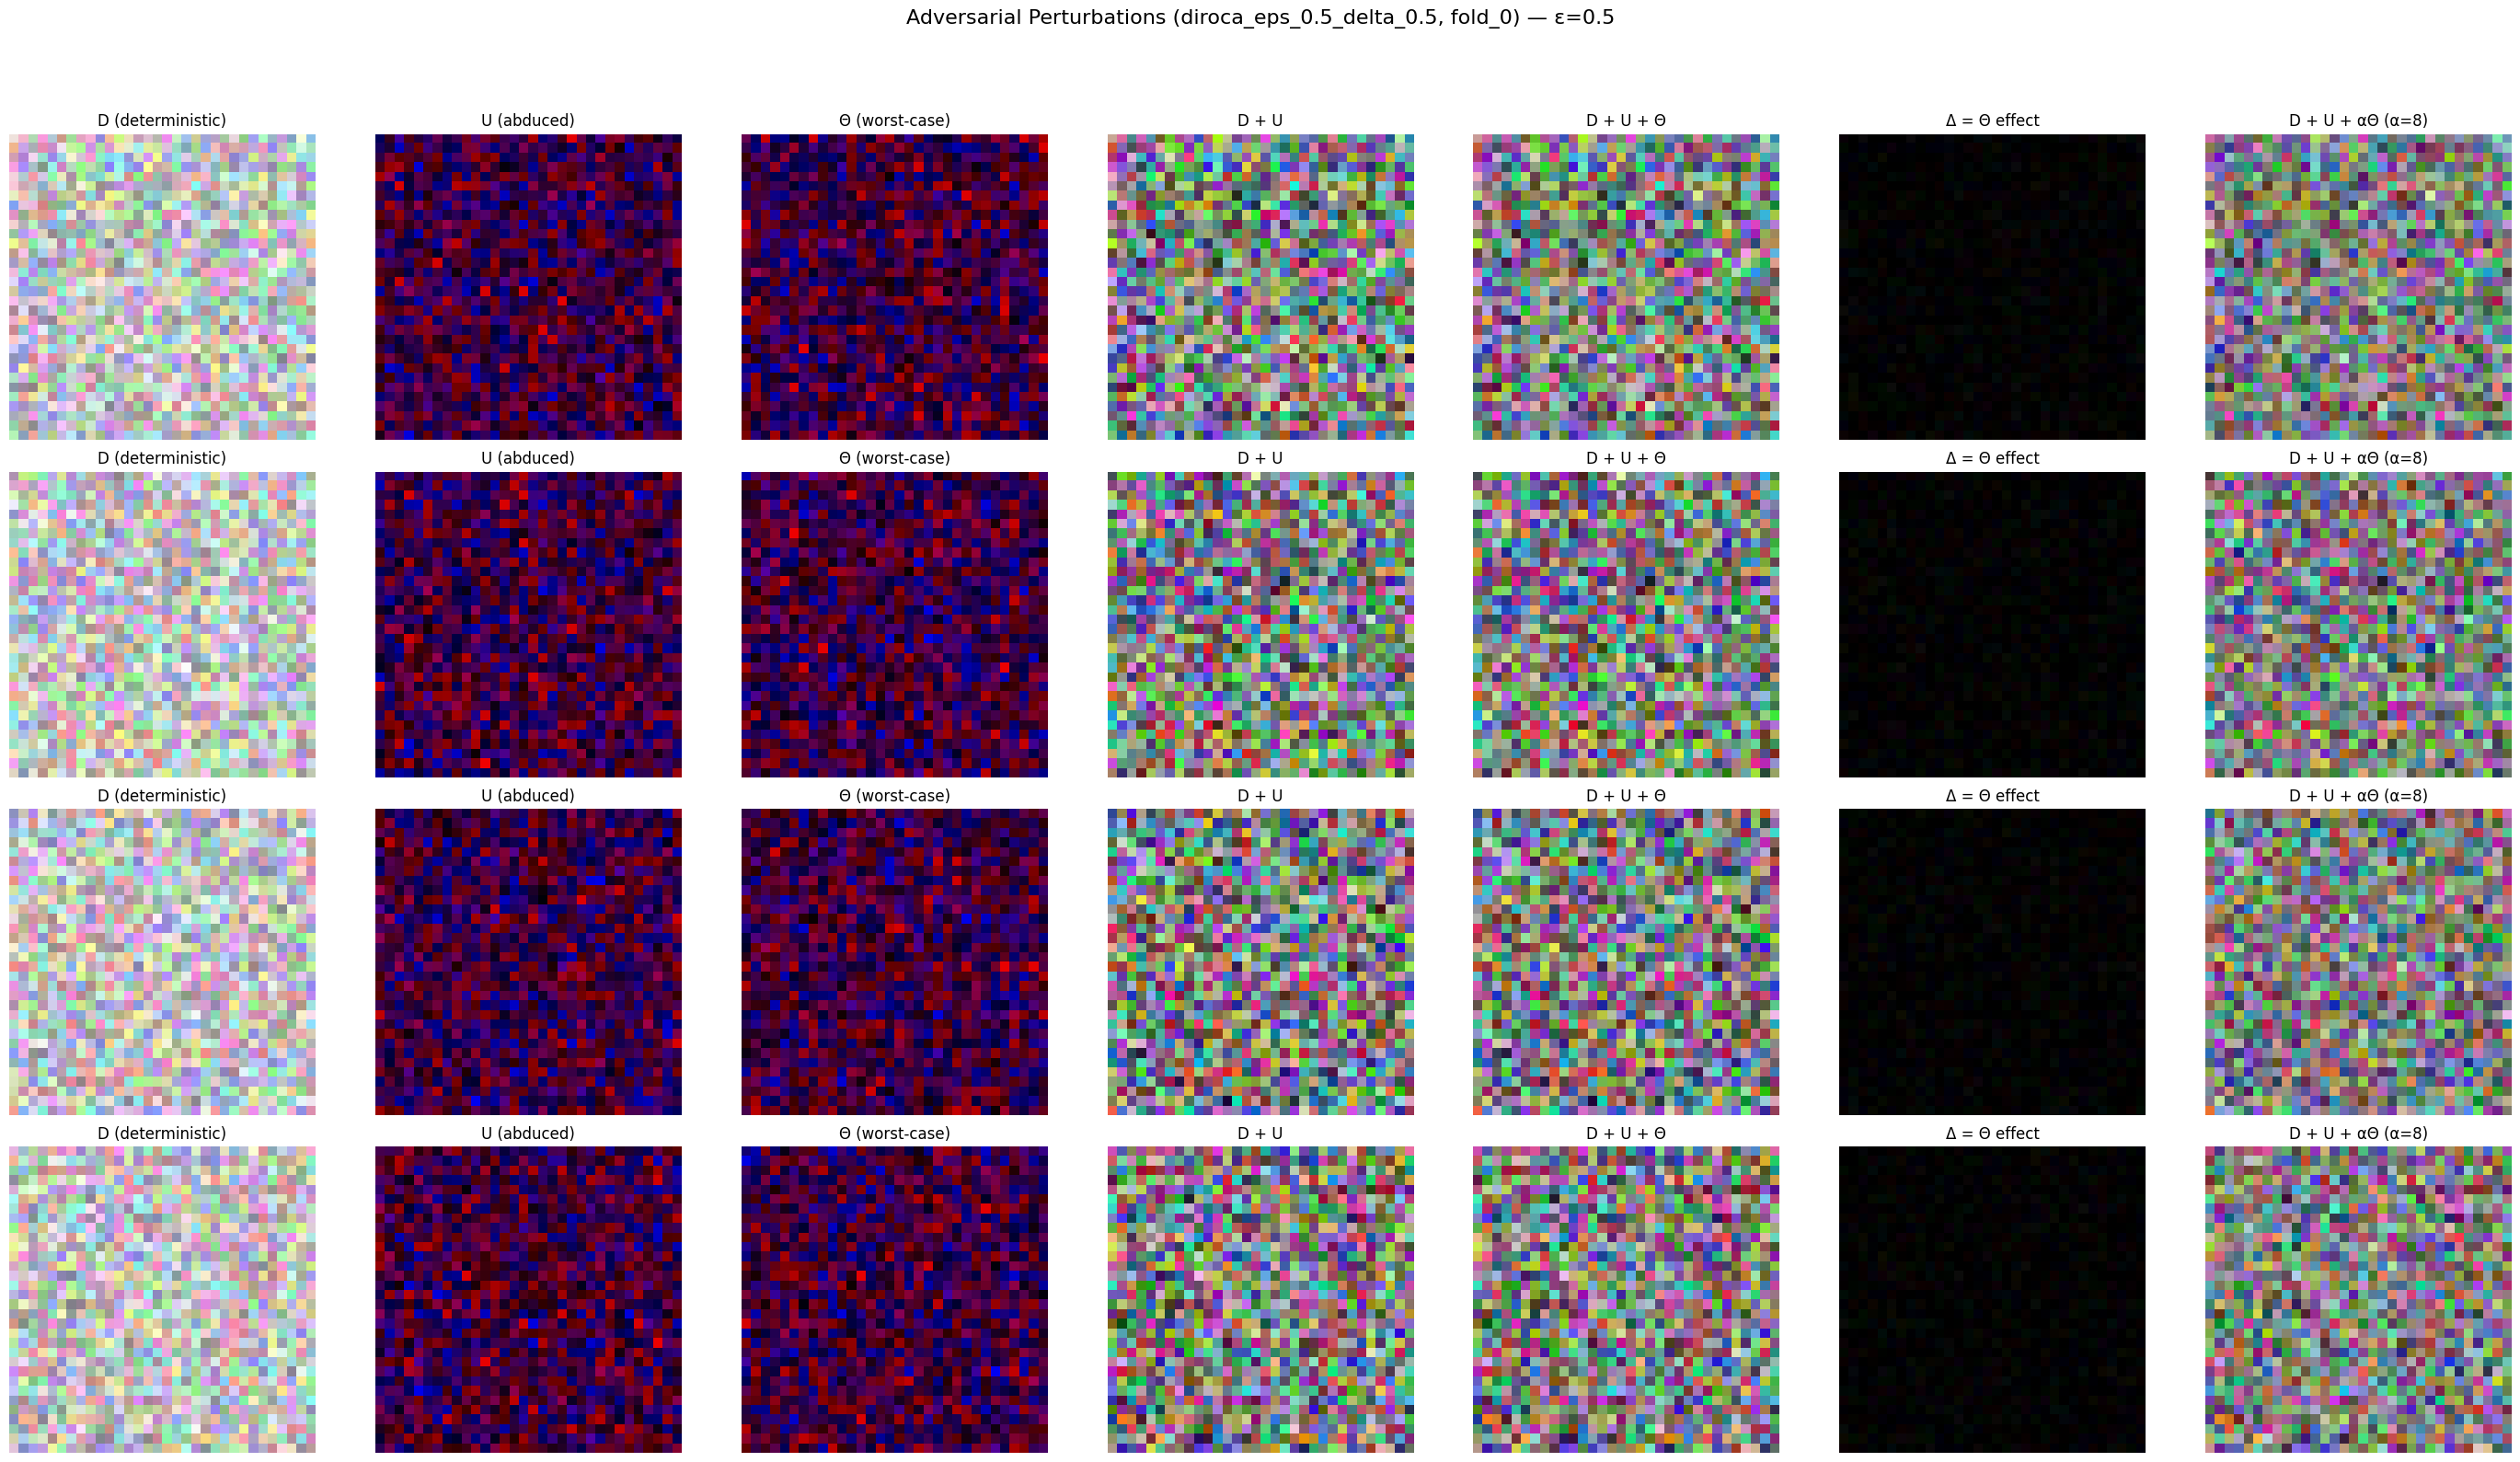

✓ Extended visualization completed successfully!


In [74]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- 1. Helper functions (Reconstructed & Corrected) ---

def _flat_to_hwc(xflat):
    """Converts a flat (3*H*W,) vector to (H,W,3) numpy array."""
    if not isinstance(xflat, torch.Tensor):
        xflat = torch.tensor(xflat, dtype=torch.float32)
    x = xflat.detach().cpu().float()
    
    # Infer H, W
    n = x.numel()
    if n % 3 != 0:
        s = 32 * 32
        H = W = 32
        x = x[:s*3] # Fallback
    else:
        s = n // 3
        H = W = int(math.isqrt(s))
        if H * W != s: # Not a perfect square
            s = 32*32
            H = W = 32
            x = x[:s*3] # Fallback
    
    return x.view(3, H, W).permute(1, 2, 0).numpy()

_to_noise = _flat_to_hwc  # Alias for noise reshaping

def _to_img01(vec_flat):
    """Converts a flat (3*H*W,) vector to an (H,W,3) numpy image in [0,1]."""
    img_hwc = _flat_to_hwc(vec_flat)
    mn, mx = float(img_hwc.min()), float(img_hwc.max())
    
    if mn >= -1.05 and mx <= 1.05:
        img = (img_hwc + 1.0) / 2.0  # Looks like [-1, 1]
    elif mn >= -1e-6 and mx <= 1.0 + 1e-6:
        img = img_hwc # Looks like [0, 1]
    else:
        rng = (mx - mn) if (mx > mn) else 1.0
        img = (img_hwc - mn) / rng # Min-max scale
    return np.clip(img, 0.0, 1.0)

_disp_with_bg = _to_img01 # Alias for simple display

def _noise_to_rgb01(img_hwc, pct=99):
    """
    Converts noise (H,W,C) to a diverging RGB heatmap.
    (This function now scales by max, not percentile)
    """
    if not isinstance(img_hwc, np.ndarray):
        img_hwc = img_hwc.detach().cpu().numpy()
    
    v = img_hwc
    
    # --- NEW FIX: Use max, not percentile, for scaling ---
    mag = np.max(np.abs(v), axis=(0, 1), keepdims=True)
    mag = np.maximum(mag, 1e-6) # Avoid division by zero
    
    sign = (v >= 0).astype(float)
    
    r = sign * (v / mag)
    b = (1 - sign) * (-v / mag)
    g = np.zeros_like(v)
    
    if v.shape[-1] == 1:
        rgb = np.stack([r[..., 0], g[..., 0], b[..., 0]], axis=-1)
    else:
        rgb = np.stack([r.mean(-1), g.mean(-1), b.mean(-1)], axis=-1)
        
    return np.clip(rgb, 0, 1)

# --- 2. Dummy Data (placeholder variables) ---
#    (This data would come from your previous notebook cells)

N_train = 4
H, W = 32, 32
P_pixels = 3 * H * W # 3072

# Create plausible-looking dummy data
torch.manual_seed(42)
# Simulating 'D' as a noisy image (like your plot)
det_pixels_train = torch.rand(N_train, P_pixels) 
# Simulating 'U' and 'Theta'
U_ll_train = (torch.rand(N_train, P_pixels) - 0.5) * 0.4     
final_Theta_ll = (torch.rand(N_train, P_pixels) - 0.5) * 0.1 

clean_recon_pixels = det_pixels_train + U_ll_train
worst_case_pixels = clean_recon_pixels + final_Theta_ll

sample_indices = list(range(N_train))
num_samples_to_show = N_train

# Placeholder strings from your context
diroca_key_toplevel = "diroca_eps_0.5_delta_0.5"
fold_key_to_show = "fold_0"
epsilon_run = 0.5

# --- 3. Main Plotting Code (Your Cell) ---

alpha = 8.0  # purely for visualization scaling of Θ
num_cols = 7  # D, U, Θ, D+U, D+U+Θ, Δ heatmap, amplified D+U+αΘ

fig, axes = plt.subplots(num_samples_to_show, num_cols, figsize=(28, 4 * num_samples_to_show))
if num_samples_to_show == 1:
    axes = np.array([axes])

fig.suptitle(
    f'Adversarial Perturbations ({diroca_key_toplevel}, {fold_key_to_show}) — ε={epsilon_run}',
    fontsize=16, y=1.02
)

for i, idx in enumerate(sample_indices):
    ref_flat = det_pixels_train[idx]

    # D (deterministic)
    axes[i, 0].imshow(_disp_with_bg(det_pixels_train[idx]), interpolation='nearest')
    axes[i, 0].set_title('D (deterministic)'); axes[i, 0].axis('off')

    # U (abduced)
    imgU = _to_noise(U_ll_train[idx])
    axes[i, 1].imshow(_noise_to_rgb01(imgU), interpolation='nearest')
    axes[i, 1].set_title('U (abduced)'); axes[i, 1].axis('off')

    # Θ (worst-case)
    imgT = _to_noise(final_Theta_ll[idx])
    axes[i, 2].imshow(_noise_to_rgb01(imgT), interpolation='nearest')
    axes[i, 2].set_title('Θ (worst-case)'); axes[i, 2].axis('off')

    # D + U
    axes[i, 3].imshow(_disp_with_bg(clean_recon_pixels[idx]), interpolation='nearest')
    axes[i, 3].set_title('D + U'); axes[i, 3].axis('off')

    # D + U + Θ
    axes[i, 4].imshow(_disp_with_bg(worst_case_pixels[idx]), interpolation='nearest')
    axes[i, 4].set_title('D + U + Θ'); axes[i, 4].axis('off')

    # Δ = Θ effect heatmap
    x_clean = clean_recon_pixels[idx]
    x_wc = worst_case_pixels[idx]
    delta = (x_wc - x_clean)
    delta_img = _flat_to_hwc(delta)
    
    # Use the same scaling as _noise_to_rgb01 for consistency
    lim = np.max(np.abs(delta_img))
    lim = max(lim, 1e-6)
    
    axes[i, 5].imshow(delta_img, cmap='RdBu_r', vmin=-lim, vmax=lim, interpolation='nearest')
    axes[i, 5].set_title('Δ = Θ effect'); axes[i, 5].axis('off')

    # D + U + αΘ (amplified for visibility)
    x_wc_amp = x_clean + alpha * (final_Theta_ll[idx])
    axes[i, 6].imshow(_to_img01(x_wc_amp), interpolation='nearest')
    axes[i, 6].set_title(f'D + U + αΘ (α={alpha:g})'); axes[i, 6].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()
print("✓ Extended visualization completed successfully!")

In [32]:
# --- Extended Visualization (no grey wash, robust Θ, Δ heatmap, amplified view) ---
import math, numpy as np, torch, matplotlib.pyplot as plt

# ===== knobs =====
fold_key_to_show = 'fold_0'   # e.g. 'fold_0', 'fold_1', ...
alpha = 8.0                   # purely for VISUALIZING Θ's effect (does not affect training)
num_samples_to_show = 4       # rows to show

# ===== crisp pixels =====
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.resample'] = False

# ===== helpers =====
def _find_obs_key(d):
    if None in d: return None
    for k in d.keys():
        if isinstance(k, str) and k.strip().lower() in {'obs','observational'}:
            return k
    for k in d.keys():
        try:
            if hasattr(k,'vv') and callable(k.vv) and k.vv()=={}:
                return k
        except Exception:
            pass
    return next(iter(d.keys()))

def _infer_dims_from_det(det_ll_dict):
    some = next(iter(det_ll_dict.values()))
    Lfull = some.shape[1]
    image_dim = Lfull - 20
    s = image_dim // 3
    H = W = int(math.isqrt(s))
    assert 3*H*W == image_dim, f"Cannot infer square image from dim={image_dim}"
    return image_dim, H, W

def _flat_to_hwc(xflat):
    x = torch.as_tensor(xflat, dtype=torch.float32).detach().cpu()
    s = x.numel() // 3
    H = W = int(math.isqrt(s))
    return x.view(3, H, W).permute(1,2,0).numpy()

def _to_img01(xflat):
    """Map arbitrary range (often [-1,1]) to [0,1] and reshape to HxWx3."""
    img = _flat_to_hwc(xflat).astype(np.float32)
    mn, mx = float(img.min()), float(img.max())
    if mn >= -1.05 and mx <= 1.05:
        img = (img + 1.0) / 2.0
    else:
        rng = (mx - mn) if mx > mn else 1.0
        img = (img - mn) / rng
    return np.clip(img, 0.0, 1.0)

def _to_noise(xflat):
    """Just reshape (no normalization), used for Θ/U/Δ before colormapping."""
    return _flat_to_hwc(xflat).astype(np.float32)

def _disp_with_bg(xflat, ref_flat, pct=5):
    """
    Remove per-channel low-percentile 'background' from ref image,
    apply SAME shift to x, clamp to [0,1] (no stretching), return HxWx3.
    """
    ref01 = _to_img01(ref_flat)               # HxWx3
    x01   = _to_img01(xflat)
    # estimate background from ref01 per-channel:
    bg = np.percentile(ref01.reshape(-1,3), pct, axis=0, keepdims=True)  # (1,3)
    # shift x by bg (use for display)
    x_shift = x01.reshape(-1,3) - bg
    x_shift = np.clip(x_shift, 0.0, 1.0).reshape(ref01.shape)
    return x_shift

def _show_noise_diverging(ax, img_hwc, pct=99.0, title=None):
    """
    Show HxWxC noise as a signed scalar field with a robust diverging colormap.
    - magnitude for scaling: mean over channels of absolute value
    - signal to display: mean over channels (keeps sign)
    """
    # robust range from per-pixel (mean over channels) magnitude
    mag = np.abs(img_hwc).mean(axis=2)
    lim = np.percentile(mag, pct)
    lim = max(lim, 1e-6)
    signed = img_hwc.mean(axis=2)  # HxW signed scalar
    ax.imshow(signed, cmap='RdBu_r', vmin=-lim, vmax=lim, interpolation='nearest')
    if title: ax.set_title(title)
    ax.axis('off')
    return lim

# ===== find a diroca run =====
diroca_key_toplevel = next((k for k in all_results if k.startswith('diroca_eps_')), None)
assert diroca_key_toplevel is not None, "No DiRoCA results found."

fold_data = all_results[diroca_key_toplevel][fold_key_to_show]
run_keys = [k for k in fold_data if k.startswith('eps_')]
assert run_keys, f"No run keys under {diroca_key_toplevel}/{fold_key_to_show}"
run_key = run_keys[0]
run_result = fold_data[run_key]
assert 'error' not in run_result, f"Run has error: {run_result['error']}"

final_Theta_ll = torch.as_tensor(run_result['final_Theta_ll'], dtype=torch.float32)
epsilon_run    = run_result.get('epsilon','?')

# ===== pull training split and align shapes =====
fold_index   = int(fold_key_to_show.split('_')[-1])
train_idx    = cv_folds[fold_index]['train']
image_dim, H, W = _infer_dims_from_det(det_ll_dict)

U_ll_train_img = U_ll_hat[train_idx]
U_ll_train     = U_ll_train_img.view(U_ll_train_img.shape[0], -1)         # (N, 3HW)

obs_key = _find_obs_key(det_ll_dict)
det_ll_obs_full  = det_ll_dict[obs_key]                                    # (N, 3HW+20)
det_ll_train_obs = det_ll_obs_full[train_idx]
det_pixels_train = det_ll_train_obs[:, :image_dim]                         # (N, 3HW)

# align (defensive)
m = min(U_ll_train.shape[1], det_pixels_train.shape[1], final_Theta_ll.shape[1])
U_ll_train      = U_ll_train[:, :m]
det_pixels_train= det_pixels_train[:, :m]
final_Theta_ll  = final_Theta_ll[:, :m]

clean_recon_pixels = det_pixels_train + U_ll_train
worst_case_pixels  = clean_recon_pixels + final_Theta_ll

# ===== samples =====
N = U_ll_train.shape[0]
num_rows = min(num_samples_to_show, N)
rng = np.random.default_rng(fold_index + 42)
sample_indices = rng.choice(N, num_rows, replace=False)

# ===== figure =====
num_cols = 7  # D, U, Θ, D+U, D+U+Θ, Δ heatmap, amplified D+U+αΘ
fig, axes = plt.subplots(num_rows, num_cols, figsize=(28, 4*num_rows))
if num_rows == 1: axes = np.array([axes])

fig.suptitle(
    f'Adversarial Perturbations ({diroca_key_toplevel}, {fold_key_to_show}) — ε={epsilon_run}',
    fontsize=16, y=1.02
)

for r, idx in enumerate(sample_indices):
    ref = det_pixels_train[idx]

    # 1) D (with ref background removed)
    ax = axes[r,0]
    ax.imshow(_disp_with_bg(det_pixels_train[idx], ref)); ax.set_title('D (deterministic)'); ax.axis('off')

    # 2) U (robust diverging)
    imgU = _to_noise(U_ll_train[idx])
    _show_noise_diverging(axes[r,1], imgU, title='U (abduced)')

    # 3) Θ (robust diverging)
    imgT = _to_noise(final_Theta_ll[idx])
    _show_noise_diverging(axes[r,2], imgT, title='Θ (worst-case)')

    # 4) D + U
    ax = axes[r,3]
    ax.imshow(_disp_with_bg(clean_recon_pixels[idx], ref)); ax.set_title('D + U'); ax.axis('off')

    # 5) D + U + Θ
    ax = axes[r,4]
    ax.imshow(_disp_with_bg(worst_case_pixels[idx], ref)); ax.set_title('D + U + Θ'); ax.axis('off')

    # 6) Δ heatmap (Θ effect) in RdBu
    delta_img = _to_noise(worst_case_pixels[idx] - clean_recon_pixels[idx])
    # robust per-sample range
    mag = np.abs(delta_img).mean(axis=2)
    lim = np.percentile(mag, 99); lim = max(lim, 1e-6)
    ax = axes[r,5]
    ax.imshow(delta_img.mean(axis=2), cmap='RdBu_r', vmin=-lim, vmax=lim); ax.set_title('Δ = Θ effect'); ax.axis('off')

    # 7) amplified D + U + αΘ (for visibility only)
    x_wc_amp = clean_recon_pixels[idx] + alpha * final_Theta_ll[idx]
    ax = axes[r,6]
    ax.imshow(_to_img01(x_wc_amp)); ax.set_title(f'D + U + αΘ (α={alpha:g})'); ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


NameError: name 'all_results' is not defined

In [163]:
# --- Merge results from individual training runs (CORRECTED) ---
print("Merging results from all training runs...")

# Start with an empty dictionary
all_results = {}

# Add DiRoCA results (handle multiple radii)
if 'all_results_diroca' in locals() and isinstance(all_results_diroca, dict):
    # all_results_diroca has structure: {radius_key: {'diroca': {fold_key: ...}}}
    for radius_key, results_outer in all_results_diroca.items():
        if results_outer is not None and 'diroca' in results_outer:
            # Create method name like 'diroca_eps_20.0_delta_20.0'
            method_name = f"diroca_{radius_key}"
            # *** FIX: Store the INNER dictionary {fold_key: ...} ***
            all_results[method_name] = results_outer['diroca'] 
            print(f"  ✓ Added DiRoCA results for {radius_key}.")
        else:
            print(f"  ✗ Skipped DiRoCA results for {radius_key} (failed or invalid).")
else:
    print("  ✗ Warning: DiRoCA results ('all_results_diroca') not found.")

# Add GradCA results
# results_gradca has structure: {'gradca': {fold_key: ...}}
if 'results_gradca' in locals() and isinstance(results_gradca, dict) and 'gradca' in results_gradca:
    # *** FIX: Store the INNER dictionary {fold_key: ...} ***
    all_results['gradca'] = results_gradca['gradca']
    print("  ✓ Added GradCA results (single run).")
else:
    print("  ✗ Warning: GradCA results not found or invalid.")

# Add BaryCA results
# results_baryca has structure: {'baryca': {fold_key: ...}}
if 'results_baryca' in locals() and isinstance(results_baryca, dict) and 'baryca' in results_baryca:
    # *** FIX: Store the INNER dictionary {fold_key: ...} ***
    all_results['baryca'] = results_baryca['baryca']
    print("  ✓ Added BaryCA results (single run).")
else:
    print("  ✗ Warning: BaryCA results not found or invalid.")

# Add Abs-LiNGAM results
# results_abslingam has structure: {'abslingam': {fold_key: {'Perfect':..., 'Noisy':...}}}
if 'results_abslingam' in locals() and isinstance(results_abslingam, dict) and 'abslingam' in results_abslingam:
    # *** FIX: Store the INNER dictionary {fold_key: ...} ***
    all_results['abslingam'] = results_abslingam['abslingam']
    print("  ✓ Added Abs-LiNGAM results (single run).")
else:
    print("  ✗ Warning: Abs-LiNGAM results not found or invalid.")


# Verify the structure (This loop will now work correctly)
print("\nStructure of merged 'all_results':")
if not all_results:
    print("  'all_results' is empty. Cannot proceed with evaluation.")
else:
    # Top-level keys are now method names (e.g., 'diroca_eps_...', 'gradca', 'abslingam')
    # Values are dictionaries keyed by fold ('fold_0', 'fold_1', ...)
    for method_name, fold_dict in all_results.items():
        if isinstance(fold_dict, dict):
             valid_folds = sum(1 for fold_data in fold_dict.values()
                               if isinstance(fold_data, dict) and 'error' not in fold_data)
             total_folds = len(fold_dict)
             print(f"  - {method_name}: Contains results for {valid_folds}/{total_folds} folds.")
             # Check for AbsLin variants
             if method_name == 'abslingam' and valid_folds > 0:
                 first_fold_keys = list(fold_dict[list(fold_dict.keys())[0]].keys())
                 print(f"    (Contains Abs-LiNGAM variants: {first_fold_keys})")
        else:
             print(f"  - {method_name}: Entry is not a dictionary - Invalid structure.")

print("\nMerging complete.")

Merging results from all training runs...
  ✓ Added DiRoCA results for eps_0.5_delta_0.5.
  ✓ Added GradCA results (single run).
  ✓ Added BaryCA results (single run).
  ✓ Added Abs-LiNGAM results (single run).

Structure of merged 'all_results':
  - diroca_eps_0.5_delta_0.5: Contains results for 5/5 folds.
  - gradca: Contains results for 1/1 folds.
  - baryca: Contains results for 1/1 folds.
  - abslingam: Contains results for 1/1 folds.
    (Contains Abs-LiNGAM variants: ['Abs-LiNGAM (Perfect)', 'Abs-LiNGAM (Noisy)'])

Merging complete.


In [150]:
import matplotlib as mpl
mpl.rcParams['image.interpolation'] = 'nearest'  # preserve pixels
mpl.rcParams['image.resample'] = False



==================== Visualizing Adversarial Perturbations (Fixed) ====================
Using DiRoCA results: diroca_eps_0.5_delta_0.5
Using run key: eps_0.5_delta_0.5


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45061275..0.50181377].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.027718738..0.028452415].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29973423..0.33154574].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.030837286..0.030927237].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.26736644..0.4521264].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.030395128..0.031749655].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got

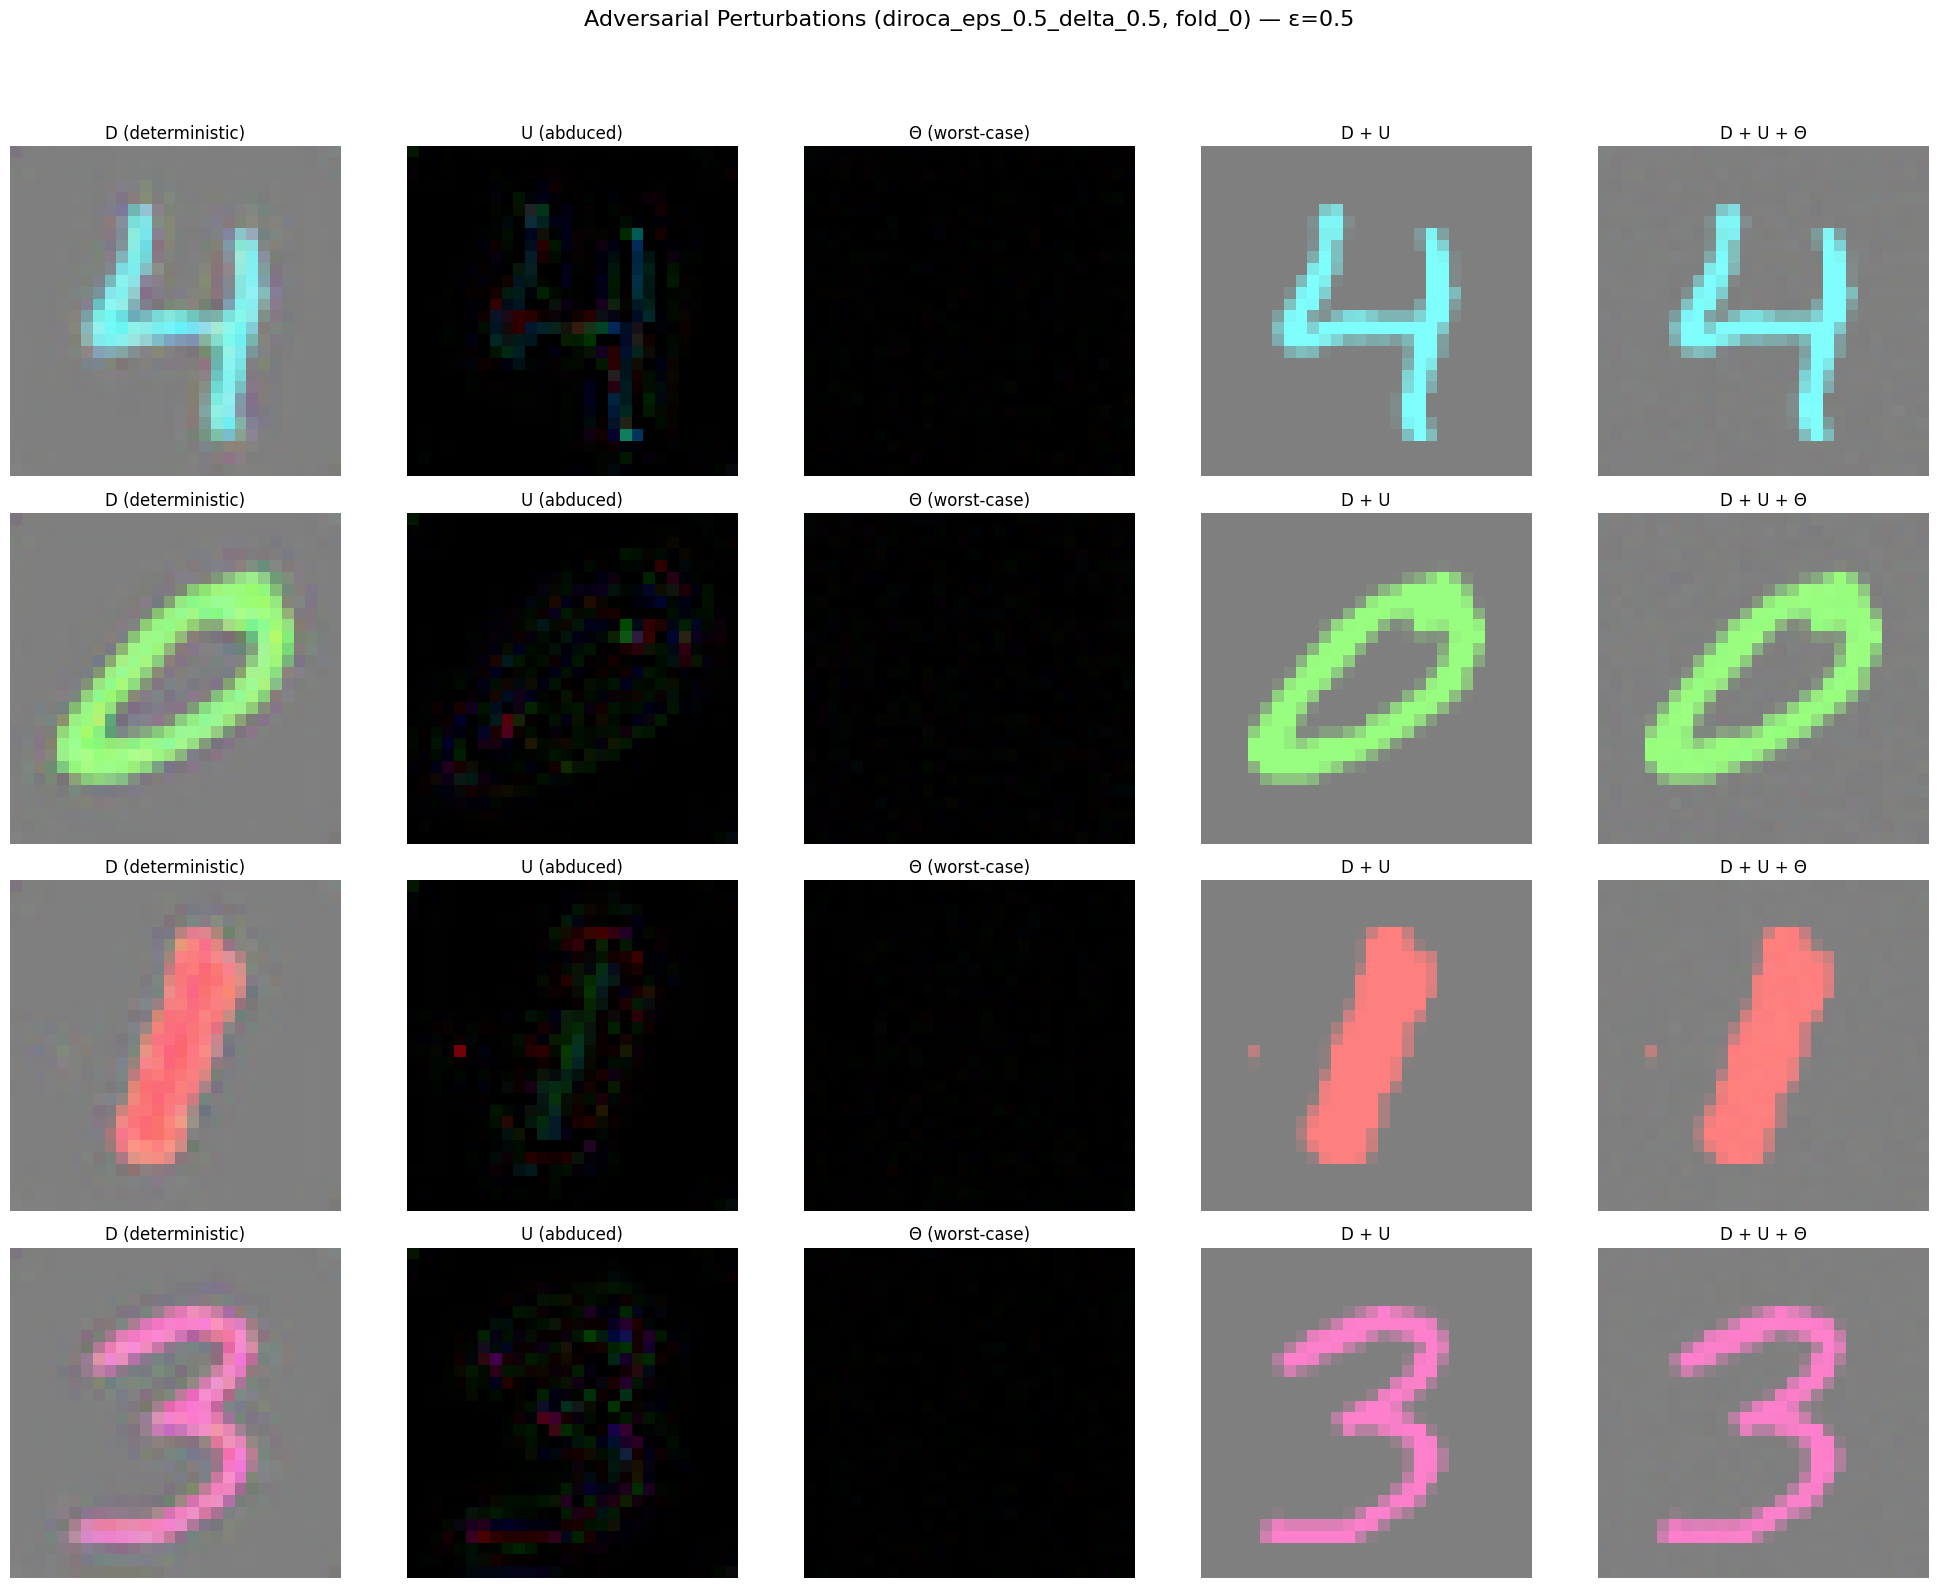

✓ Visualization completed successfully!


In [151]:
# --- Fixed Visualization Cell (robust OBS key + dynamic shapes) ---
import matplotlib.pyplot as plt
import torch
import numpy as np
import re
import math

print("\n" + "="*20 + " Visualizing Adversarial Perturbations (Fixed) " + "="*20)

def _find_obs_key(d):
    """
    Returns the key in `d` that corresponds to observational data.
    Accepts: None, "obs"/"observational" (any case), Intervention with empty vv().
    Falls back to the first key if none matched.
    """
    # 1) try None
    if None in d:
        return None
    # 2) try common strings
    for k in d.keys():
        if isinstance(k, str) and k.strip().lower() in {"obs","observational"}:
            return k
    # 3) try Intervention-like keys with empty vv()
    for k in d.keys():
        try:
            if hasattr(k, "vv") and callable(k.vv) and (k.vv() == {}):
                return k
        except Exception:
            pass
    # 4) fallback: first key
    return next(iter(d.keys()))

def _auto_to01(vec_flat):
    """
    vec_flat: (3*H*W,) tensor-like. If in [-1,1], maps to [0,1]; if already [0,1], returns as-is;
    otherwise min-max normalizes safely. Returns HxWx3 numpy array.
    """
    if not isinstance(vec_flat, torch.Tensor):
        vec_flat = torch.tensor(vec_flat)
    x = vec_flat.detach().cpu().float()

    # infer H,W from length
    n = x.numel()
    if n % 3 != 0:
        return np.zeros((32, 32, 3))
    s = n // 3
    H = W = int(math.isqrt(s))
    if H * W != s:
        # not a square -> fallback to 32x32 zeros
        return np.zeros((32, 32, 3))

    img_chw = x.view(3, H, W)
    img = img_chw.permute(1, 2, 0).numpy().astype(np.float32)

    mn, mx = float(img.min()), float(img.max())
    # try typical ranges
    if mn >= -1.05 and mx <= 1.05:
        img = (img + 1.0) / 2.0
    elif mn >= -1e-6 and mx <= 1.0 + 1e-6:
        # looks already in [0,1]
        pass
    else:
        # min-max fallback
        rng = (mx - mn) if (mx > mn) else 1.0
        img = (img - mn) / rng
    return np.clip(img, 0.0, 1.0)

def _reshape_noise(vec_flat):
    """Reshape a flat (3*H*W,) vector to HxWx3 for diverging cmap visualization."""
    if not isinstance(vec_flat, torch.Tensor):
        vec_flat = torch.tensor(vec_flat)
    x = vec_flat.detach().cpu().float()
    n = x.numel()
    if n % 3 != 0:
        return np.zeros((32, 32, 3))
    s = n // 3
    H = W = int(math.isqrt(s))
    if H * W != s:
        return np.zeros((32, 32, 3))
    return x.view(3, H, W).permute(1, 2, 0).numpy()

# --- 1) Select DiRoCA result & fold ---
fold_key_to_show = 'fold_0'
diroca_key_toplevel = next((k for k in all_results if k.startswith('diroca_eps_')), None)

if diroca_key_toplevel is None:
    print("Error: No DiRoCA results found.")
else:
    print(f"Using DiRoCA results: {diroca_key_toplevel}")

    if fold_key_to_show not in all_results[diroca_key_toplevel]:
        print(f"Error: Fold {fold_key_to_show} not found in {diroca_key_toplevel}")
        run_result = None
    else:
        fold_data = all_results[diroca_key_toplevel][fold_key_to_show]
        run_keys = [k for k in fold_data.keys() if k.startswith('eps_')]
        if not run_keys:
            print(f"Error: No run keys found in fold data. Available keys: {list(fold_data.keys())}")
            run_result = None
        else:
            run_key = run_keys[0]
            run_result = fold_data[run_key]
            if 'error' in run_result:
                print(f"Error in run result: {run_result['error']}")
                run_result = None
            else:
                print(f"Using run key: {run_key}")

    if run_result is not None:
        final_Theta_ll = run_result.get('final_Theta_ll')
        if final_Theta_ll is None:
            print("Theta not found in run_result.")
        else:
            if not isinstance(final_Theta_ll, torch.Tensor):
                final_Theta_ll = torch.tensor(final_Theta_ll, dtype=torch.float32)

            epsilon_run = run_result.get('epsilon', 'Unknown')
            fold_index = int(fold_key_to_show.split('_')[-1])
            train_indices = cv_folds[fold_index]['train']

            # U_ll on train split (flattened)
            U_ll_train_img = U_ll_hat[train_indices]
            U_ll_train = U_ll_train_img.view(U_ll_train_img.shape[0], -1)

            # --- robustly fetch observational deterministic LL vectors ---
            obs_key = _find_obs_key(det_ll_dict)
            det_ll_obs_full = det_ll_dict[obs_key]
            det_ll_train_obs = det_ll_obs_full[train_indices]   # (N_train, 3092)
            det_pixels_train = det_ll_train_obs[:, :det_ll_train_obs.shape[1]-20]  # first is pixels (3HW), last 20 are labels

            # Sanity: align shapes
            if U_ll_train.shape[1] != det_pixels_train.shape[1]:
                print(f"Warning: pixel dims mismatch: U={U_ll_train.shape[1]} vs D={det_pixels_train.shape[1]}")
                # fallback to min common
                m = min(U_ll_train.shape[1], det_pixels_train.shape[1])
                U_ll_train = U_ll_train[:, :m]
                det_pixels_train = det_pixels_train[:, :m]
                final_Theta_ll = final_Theta_ll[:, :m]

            clean_recon_pixels = det_pixels_train + U_ll_train
            worst_case_pixels = clean_recon_pixels + final_Theta_ll

            # --- sample rows to display ---
            num_samples_to_show = 4
            N_train = U_ll_train.shape[0]
            num_samples_to_show = min(num_samples_to_show, N_train)
            np.random.seed(fold_index + 42)
            sample_indices = np.random.choice(N_train, num_samples_to_show, replace=False)

            # --- plotting ---
            fig, axes = plt.subplots(num_samples_to_show, 5, figsize=(20, 4 * num_samples_to_show))
            if num_samples_to_show == 1:
                axes = np.array([axes])
            fig.suptitle(
                f'Adversarial Perturbations ({diroca_key_toplevel}, {fold_key_to_show}) — ε={epsilon_run}',
                fontsize=16, y=1.02
            )

            for i, idx in enumerate(sample_indices):
                # Col 1: deterministic D
                ax = axes[i, 0]
                ax.imshow(_auto_to01(det_pixels_train[idx]), interpolation='nearest')
                ax.set_title('D (deterministic)'); ax.axis('off')

                # Col 2: U (diverging cmap)
                ax = axes[i, 1]
                imgU = _reshape_noise(U_ll_train[idx]); normU = np.max(np.abs(imgU)) or 0.1
                ax.imshow(imgU, cmap='RdBu_r', vmin=-normU-1e-6, vmax=normU+1e-6, interpolation='nearest')
                ax.set_title('U (abduced)'); ax.axis('off')

                # Col 3: Θ (diverging cmap)
                ax = axes[i, 2]
                imgT = _reshape_noise(final_Theta_ll[idx]); normT = np.max(np.abs(imgT)) or 0.1
                ax.imshow(imgT, cmap='RdBu_r', vmin=-normT-1e-6, vmax=normT+1e-6, interpolation='nearest')
                ax.set_title('Θ (worst-case)'); ax.axis('off')

                # Col 4: D + U
                ax = axes[i, 3]
                ax.imshow(_auto_to01(clean_recon_pixels[idx]), interpolation='nearest')
                ax.set_title('D + U'); ax.axis('off')

                # Col 5: D + U + Θ
                ax = axes[i, 4]
                ax.imshow(_auto_to01(worst_case_pixels[idx]), interpolation='nearest')
                ax.set_title('D + U + Θ'); ax.axis('off')


            plt.tight_layout(rect=[0, 0.03, 1, 0.98])
            plt.show()

            print("✓ Visualization completed successfully!")



==================== Plotting HL Distributions (Original vs. Recon vs. Worst) ====================
Using DiRoCA results: diroca_eps_0.5_delta_0.5


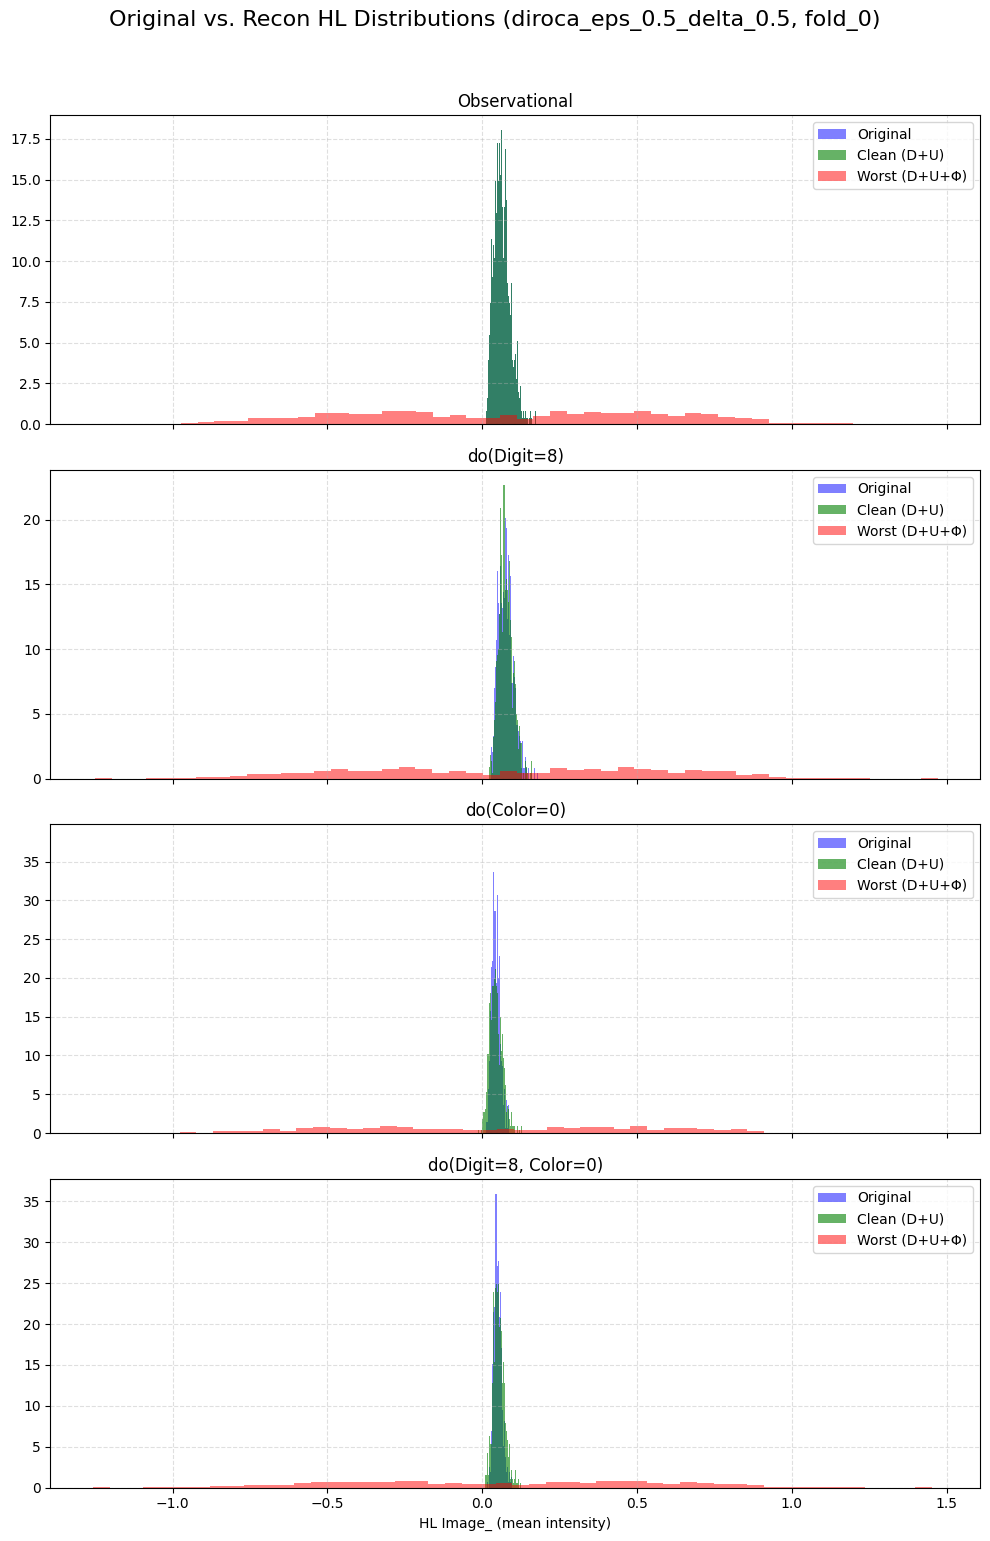


--- Stats (Original vs Clean vs Worst) ---

Observational:
  Original     : mean=+0.0651, std=0.0262
  Clean (D+U)  : mean=+0.0651, std=0.0262  (Δmean +0.0000, Δstd +0.0000)
  Worst (D+U+Φ): mean=+0.0719, std=0.5005  (Δmean +0.0068, Δstd +0.4743)

do(Digit=8):
  Original     : mean=+0.0761, std=0.0244
  Clean (D+U)  : mean=+0.0766, std=0.0229  (Δmean +0.0005, Δstd -0.0015)
  Worst (D+U+Φ): mean=+0.0834, std=0.5005  (Δmean +0.0068, Δstd +0.4776)

do(Color=0):
  Original     : mean=+0.0441, std=0.0138
  Clean (D+U)  : mean=+0.0446, std=0.0215  (Δmean +0.0005, Δstd +0.0077)
  Worst (D+U+Φ): mean=+0.0514, std=0.5003  (Δmean +0.0068, Δstd +0.4788)

do(Digit=8, Color=0):
  Original     : mean=+0.0501, std=0.0129
  Clean (D+U)  : mean=+0.0537, std=0.0180  (Δmean +0.0036, Δstd +0.0050)
  Worst (D+U+Φ): mean=+0.0605, std=0.5002  (Δmean +0.0068, Δstd +0.4822)


In [164]:
# --- Robust HL distributions plot: Original vs Recon (D+U) vs Worst (D+U+Φ) ---
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

print("\n" + "="*20 + " Plotting HL Distributions (Original vs. Recon vs. Worst) " + "="*20)

# Helpers
def _find_obs_key(d):
    if None in d: return None
    for k in d:
        if isinstance(k, str) and k.strip().lower() in {"obs", "observational"}:
            return k
    for k in d:
        try:
            if hasattr(k, "vv") and callable(k.vv) and (k.vv() == {}):
                return k
        except Exception:
            pass
    return next(iter(d))  # fallback

def _intervention_dict_from_key(k):
    # Normalize key k -> dict like {"Digit_": 8, "Color_": 0}
    if hasattr(k, "vv") and callable(k.vv):
        return k.vv()
    if isinstance(k, str):
        parts = [p.strip() for p in k.split(",") if p.strip()]
        out = {}
        for p in parts:
            if "=" in p:
                a, b = p.split("=")
                a = a.strip()
                v = int(b.strip())
                # Try both HL tag variants
                if a in {"D", "Digit", "Digit_"}: out["Digit_"] = v
                elif a in {"C", "Color", "Color_"}: out["Color_"] = v
        return out
    return {}

def _find_eta_for(iv_target, keys):
    # iv_target is a dict, e.g., {"Digit_":8} or {"Color_":0} or {"Digit_":8,"Color_":0}
    for k in keys:
        if _intervention_dict_from_key(k) == iv_target:
            return k
    return None

# 1) Pick the DiRoCA run/fold
fold_to_show = 0
fold_key = f"fold_{fold_to_show}"
diroca_key_toplevel = next((k for k in all_results if k.startswith("diroca_eps_")), None)

if diroca_key_toplevel is None:
    print("Error: No DiRoCA results found in 'all_results'.")
else:
    print(f"Using DiRoCA results: {diroca_key_toplevel}")
    if fold_key not in all_results[diroca_key_toplevel]:
        print(f"Error: Fold {fold_key} not found in {diroca_key_toplevel}")
    else:
        fold_data = all_results[diroca_key_toplevel][fold_key]
        run_keys = [k for k in fold_data if k.startswith("eps_")]
        if not run_keys:
            print(f"Error: No run keys found in fold data. Available: {list(fold_data.keys())}")
        else:
            run_key = run_keys[0]
            run_result = fold_data[run_key]
            if "error" in run_result:
                print(f"Error in run result: {run_result['error']}")
            else:
                final_Phi_hl = run_result.get("final_Phi_hl")
                if final_Phi_hl is None:
                    print("Error: final_Phi_hl not found in run result.")
                else:
                    if not isinstance(final_Phi_hl, torch.Tensor):
                        final_Phi_hl = torch.tensor(final_Phi_hl, dtype=torch.float32)

                    train_indices = cv_folds[fold_to_show]["train"]

                    # U_hl on train split
                    if "U_hl_hat" not in locals():
                        print("Error: U_hl_hat not found in scope.")
                    else:
                        U_hl_train = U_hl_hat[train_indices]  # (N_train, 1) typically

                        # Build det_hl for train split
                        det_hl_train_dict = {k: v[train_indices] for k, v in det_hl_dict.items()}

                        # Find keys we need
                        obs_key = _find_obs_key(Dhl_samples)
                        eta_d8   = _find_eta_for({"Digit_": 8}, Dhl_samples.keys())
                        eta_c0   = _find_eta_for({"Color_": 0}, Dhl_samples.keys())
                        eta_d8c0 = _find_eta_for({"Digit_": 8, "Color_": 0}, Dhl_samples.keys())

                        interventions_to_plot = []
                        # Observational
                        interventions_to_plot.append(("Observational", obs_key))
                        # Add the others if present
                        if eta_d8   is not None: interventions_to_plot.append(("do(Digit=8)", eta_d8))
                        if eta_c0   is not None: interventions_to_plot.append(("do(Color=0)", eta_c0))
                        if eta_d8c0 is not None: interventions_to_plot.append(("do(Digit=8, Color=0)", eta_d8c0))

                        if not interventions_to_plot:
                            print("No valid interventions found to plot.")
                        else:
                            # Collect distributions
                            hl_feature_values = {}

                            for name, eta_key in tqdm(interventions_to_plot, desc="Collecting HL dists"):
                                if eta_key not in det_hl_train_dict or eta_key not in Dhl_samples:
                                    print(f"Skipping {name}: key not found in det_hl_train_dict/Dhl_samples.")
                                    continue

                                det_hl_full = det_hl_train_dict[eta_key]      # (N_train, 20 + F)
                                orig_hl_full = Dhl_samples[eta_key][train_indices]  # (N_train, 20 + F)

                                # Last column is the Image_ feature
                                det_feature   = det_hl_full[:, -1:]
                                orig_feature  = orig_hl_full[:, -1:]

                                device = det_feature.device
                                Uphi = U_hl_train.to(device)
                                Phi  = final_Phi_hl.to(device)

                                clean = det_feature + Uphi
                                worst = det_feature + Uphi + Phi

                                hl_feature_values[name] = {
                                    "original":   orig_feature.detach().cpu().numpy().ravel(),
                                    "clean_recon": clean.detach().cpu().numpy().ravel(),
                                    "worst_recon": worst.detach().cpu().numpy().ravel(),
                                }

                            if not hl_feature_values:
                                print("No values calculated; nothing to plot.")
                            else:
                                # Plot
                                rows = len(hl_feature_values)
                                fig, axes = plt.subplots(rows, 1, figsize=(10, 4*rows), sharex=True)
                                if rows == 1: axes = [axes]
                                fig.suptitle(
                                    f"Original vs. Recon HL Distributions ({diroca_key_toplevel}, {fold_key})",
                                    fontsize=16, y=0.99
                                )
                                for ax, (name, vals) in zip(axes, hl_feature_values.items()):
                                    ax.hist(vals["original"],   bins=50, alpha=0.5, density=True, label="Original",   color="blue")
                                    ax.hist(vals["clean_recon"],bins=50, alpha=0.6, density=True, label="Clean (D+U)", color="green")
                                    ax.hist(vals["worst_recon"],bins=50, alpha=0.5, density=True, label="Worst (D+U+Φ)", color="red")
                                    ax.set_title(name)
                                    ax.grid(True, ls="--", alpha=0.4)
                                    ax.legend()
                                axes[-1].set_xlabel("HL Image_ (mean intensity)")
                                plt.tight_layout(rect=[0,0.03,1,0.97])
                                plt.show()

                                # Print stats
                                print("\n--- Stats (Original vs Clean vs Worst) ---")
                                for name, vals in hl_feature_values.items():
                                    mo, so = np.mean(vals["original"]),   np.std(vals["original"])
                                    mc, sc = np.mean(vals["clean_recon"]), np.std(vals["clean_recon"])
                                    mw, sw = np.mean(vals["worst_recon"]), np.std(vals["worst_recon"])
                                    print(f"\n{name}:")
                                    print(f"  Original     : mean={mo:+.4f}, std={so:.4f}")
                                    print(f"  Clean (D+U)  : mean={mc:+.4f}, std={sc:.4f}  (Δmean {mc-mo:+.4f}, Δstd {sc-so:+.4f})")
                                    print(f"  Worst (D+U+Φ): mean={mw:+.4f}, std={sw:.4f}  (Δmean {mw-mc:+.4f}, Δstd {sw-sc:+.4f})")


In [165]:
import torch
import torch.nn.functional as F
import numpy as np

# --- Contamination Function (Noise on specific dims, Corrected loc=0.0) ---
def apply_huber_contamination_cmnist(clean_data, alpha, noise_scale, noise_dims, seed=None, loc=0.0):
    """Contaminates only specific dimensions (pixels or features) with zero-mean noise."""
    if alpha == 0 or noise_scale == 0:
        return clean_data if isinstance(clean_data, torch.Tensor) else torch.tensor(clean_data, dtype=torch.float32)

    data_tensor = clean_data if isinstance(clean_data, torch.Tensor) else torch.tensor(clean_data, dtype=torch.float32)
    data_cont = data_tensor.clone().to(torch.float32)
    data_to_noise = data_cont[:, noise_dims].data

    rng = np.random.default_rng(seed)
    # --- CORRECTED: Use loc=0.0 for zero-mean noise ---
    #noise = rng.normal(loc=0.0, scale=noise_scale, size=data_to_noise.shape).astype(np.float32)
    noise = rng.normal(loc=loc, scale=noise_scale, size=data_to_noise.shape).astype(np.float32)
    noise_tensor = torch.tensor(noise, dtype=torch.float32, device=data_tensor.device)
    noisy_slice = data_to_noise + noise_tensor

    if alpha >= 1.0:
        data_cont[:, noise_dims] = noisy_slice
        return data_cont

    n_samples = data_tensor.shape[0]
    n_contaminate = int(alpha * n_samples)
    if n_contaminate == 0: return data_cont

    idx_to_contaminate = rng.choice(n_samples, size=n_contaminate, replace=False)
    data_cont[idx_to_contaminate, noise_dims] = noisy_slice[idx_to_contaminate]
    return data_cont

# --- Error Calculation ---
def calculate_empirical_error_flat(T_matrix, Dll_test_flat, Dhl_test):
    """Calculates abstraction error for the linear T matrix on flattened data."""
    try:
        T_matrix = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        Dll_test_flat = Dll_test_flat if isinstance(Dll_test_flat, torch.Tensor) else torch.tensor(Dll_test_flat, dtype=torch.float32)
        Dhl_test = Dhl_test if isinstance(Dhl_test, torch.Tensor) else torch.tensor(Dhl_test, dtype=torch.float32)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T_matrix = T_matrix.to(device)
        Dll_test_flat = Dll_test_flat.to(device)
        Dhl_test = Dhl_test.to(device)

        if T_matrix.shape[1] != Dll_test_flat.shape[1]: 
            # print(f"Eval Error - Dim mismatch T vs LL: T={T_matrix.shape}, LL={Dll_test_flat.shape}")
            return float('inf')
        if T_matrix.shape[0] != Dhl_test.shape[1]: 
            # print(f"Eval Error - Dim mismatch T vs HL: T={T_matrix.shape}, HL={Dhl_test.shape}")
            return float('inf')

        with torch.no_grad():
            Dhl_pred = Dll_test_flat @ T_matrix.T
            diff = Dhl_pred - Dhl_test
            err = torch.norm(diff, p='fro')**2 / max(1, diff.shape[0])
        return float(err.item())

    except Exception as e:
        print(f"Error in calculate_empirical_error_flat: {e}")
        return float('inf')

print("Evaluation functions defined.")

Evaluation functions defined.


In [166]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import pandas as pd
import os
import gc
import re # Make sure re is imported

# --- Assume these are defined/loaded: ---
# cv_folds, omega, Dll_samples, Dhl_samples
# all_results (Created in the corrected Merge Cell above)
# apply_huber_contamination_cmnist, calculate_empirical_error_flat (defined in Cell 2)
# output_dir
# ---------------------------------------------

# --- Ensure output_dir exists ---
if 'output_dir' not in locals():
    output_dir = 'data/cmnist/results_empirical'
    print(f"Warning: 'output_dir' not set, using default: {output_dir}")
os.makedirs(output_dir, exist_ok=True)

print("\n--- Starting Simplified Evaluation for ALL Methods (alpha=0 & alpha=1) ---")

# --- Define Evaluation Parameters ---
N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 0.001 # Or 0.2 as in your last output
ALPHA_VALUES_TO_TEST = [0.0, 1.0]

evaluation_records = []

# --- Determine Total Runs for Progress Bar ---
total_methods_trained = 0
for method_group_key in all_results: # e.g., 'diroca_eps_...', 'gradca', 'abslingam'
    method_data_inner = all_results[method_group_key]
    if isinstance(method_data_inner, dict):
        for fold_key in method_data_inner:
            fold_data = method_data_inner[fold_key]
            if isinstance(fold_data, dict) and 'error' not in fold_data:
                total_methods_trained += len(fold_data)
total_configs = total_methods_trained * len(ALPHA_VALUES_TO_TEST) * N_TRIALS

if total_configs == 0:
     print("Error: No valid training results found in 'all_results'. Cannot run evaluation.")
else:
    pbar_eval = tqdm(total=total_configs, desc="Evaluating All Methods (alpha=0 & 1)")

    LL_PIXEL_DIMS = slice(0, 3072)
    HL_FEATURE_DIM = slice(20, None)

    # --- Evaluation Loop for ALL Methods (CORRECTED) ---
    # method_group_key examples: 'diroca_eps_...', 'gradca', 'baryca', 'abslingam'
    for method_group_key, method_results_inner in all_results.items():
        
        # method_results_inner NOW contains {fold_key: ...}
        if not isinstance(method_results_inner, dict):
             print(f"Skipping invalid entry structure for {method_group_key}")
             continue

        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'):
                 print(f"Warning: Unexpected key '{fold_key}' instead of fold key under '{method_group_key}'. Skipping.")
                 continue

            if 'error' in fold_data: # Skip failed folds
                 method_runs_per_fold = len(fold_data) if isinstance(fold_data, dict) else 1
                 # pbar_eval.update(method_runs_per_fold * len(ALPHA_VALUES_TO_TEST) * N_TRIALS) # Update pbar for skipped
                 continue

            i = int(fold_key.split('_')[-1]) # Get fold index

            # run_key examples: 'eps_...', 'gradca_run', 'baryca_run', 'Abs-LiNGAM (Perfect)'
            for run_key, run_result in fold_data.items():
                 if 'error' in run_result or run_result.get('T_matrix') is None: # Skip failed runs
                      pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                      continue

                 T_matrix = run_result['T_matrix']
                 test_idx = run_result['test_indices']
                 if test_idx is None: # Skip if no test indices
                     pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                     continue

                 # --- Construct Method Name (Corrected) ---
                 if method_group_key.startswith('diroca_'):
                     eval_method_name = f"DiRoCA ({run_key})"
                 elif method_group_key == 'gradca': eval_method_name = "GradCA"
                 elif method_group_key == 'baryca': eval_method_name = "BaryCA"
                 elif method_group_key == 'abslingam':
                     eval_method_name = run_key # This is now 'Abs-LiNGAM (Perfect)' or 'Abs-LiNGAM (Noisy)'
                 else: eval_method_name = f"{method_group_key}_{run_key}"
                 # --- End Name Correction ---

                 # --- Inner Evaluation Loop ---
                 for alpha in ALPHA_VALUES_TO_TEST:
                     noise_scale = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE_FOR_ALPHA1
                     loc_ll = 10000.0  # e.g., Add a bias of 1.0 to pixels
                     loc_hl = 0.0  # e.g., Add NO bias to the feature
                     for trial in range(N_TRIALS):
                         trial_errors = []
                         for iota, eta in list(omega.items()): # Use list
                             try:
                                 if iota not in Dll_samples or eta not in Dhl_samples: continue
                                 ll_images, _, ll_digits, ll_colors = Dll_samples[iota]
                                 max_idx = max(test_idx) if len(test_idx)>0 else -1
                                 if max_idx >= len(ll_images): continue
                                 ll_images_test=ll_images[test_idx]; ll_digits_test=ll_digits[test_idx]; ll_colors_test=ll_colors[test_idx];
                                 Dhl_test_clean = Dhl_samples[eta][test_idx]

                                 seed = hash((i, run_key, float(alpha), float(noise_scale), trial, str(iota))) % (2**32)
                                 ll_images_test_flat = ll_images_test.view(ll_images_test.shape[0], -1)
                                 ll_images_cont_flat = apply_huber_contamination_cmnist(ll_images_test_flat, alpha, noise_scale, LL_PIXEL_DIMS, seed=seed, loc=loc_ll)
                                 Dhl_test_cont = apply_huber_contamination_cmnist(Dhl_test_clean, alpha, noise_scale, HL_FEATURE_DIM, seed=seed, loc=loc_hl)

                                 ll_digits_onehot = F.one_hot(ll_digits_test, num_classes=10).float()
                                 ll_colors_onehot = F.one_hot(ll_colors_test, num_classes=10).float()
                                 device = ll_images_cont_flat.device
                                 Dll_test_cont_flat_full = torch.cat([ll_images_cont_flat, ll_digits_onehot.to(device), ll_colors_onehot.to(device)], dim=1)

                                 error = calculate_empirical_error_flat(T_matrix, Dll_test_cont_flat_full, Dhl_test_cont)
                                 if not np.isnan(error) and error != float('inf'): trial_errors.append(error)
                             except Exception as e:
                                 print(f"ERROR inner loop: {e} | Context: M{eval_method_name}, F{i}, R{run_key}, A{alpha}, N{noise_scale}, T{trial}, Iota{iota}")
                                 trial_errors.append(np.nan)

                         record = {
                             'method': eval_method_name, 'fold': i, 'alpha': float(alpha),
                             'noise_scale': float(noise_scale), 'trial': trial,
                             'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan }
                         if method_group_key.startswith('diroca_'):
                             record['train_epsilon'] = run_result.get('epsilon', np.nan)
                             record['train_delta'] = run_result.get('delta', np.nan)
                         evaluation_records.append(record)
                         pbar_eval.update(1)
                         del ll_images_test, ll_digits_test, ll_colors_test, Dhl_test_clean, ll_images_test_flat, ll_images_cont_flat, Dhl_test_cont, ll_digits_onehot, ll_colors_onehot, Dll_test_cont_flat_full
                         if 'error' in locals(): del error
                         if 'trial_errors' in locals(): del trial_errors[:]

    pbar_eval.close()
    full_results_df = pd.DataFrame(evaluation_records)

    # --- Save Full DataFrame ---
    eval_output_path = os.path.join(output_dir, "all_methods_evaluation_results.pkl")
    full_results_df.to_pickle(eval_output_path)
    print(f"\nEvaluation results for all methods saved to {eval_output_path}")

    # --- Basic Analysis (No Plotting) ---
    print("\n--- Evaluation Complete. Analyzing results... ---")
    if full_results_df.empty:
        print("No evaluation results generated.")
    else:
        pd.set_option('display.max_rows', None); pd.set_option('display.width', 1000)

        df_clean = full_results_df[np.isclose(full_results_df['alpha'], 0.0)]
        summary_clean = df_clean.groupby('method')['error'].agg(['mean', 'std']).sort_values('mean')
        print("\n--- Results on Clean Data (α = 0.0, σ = 0.0) ---")
        print(summary_clean)

        df_noisy = full_results_df[np.isclose(full_results_df['alpha'], 1.0)]
        summary_noisy = df_noisy.groupby('method')['error'].agg(['mean', 'std']).sort_values('mean')
        print(f"\n--- Results on Fully Noisy Data (α = 1.0, σ = {NOISE_SCALE_FOR_ALPHA1:.1f}) ---")
        print(summary_noisy)

        pd.reset_option('display.max_rows'); pd.reset_option('display.width')

    print("\n✅ Simplified Evaluation for All Methods Complete.")


--- Starting Simplified Evaluation for ALL Methods (alpha=0 & alpha=1) ---


Evaluating All Methods (alpha=0 & 1): 100%|██████████| 90/90 [00:04<00:00, 18.98it/s]


Evaluation results for all methods saved to data/cmnist/results_empirical/all_methods_evaluation_results.pkl

--- Evaluation Complete. Analyzing results... ---

--- Results on Clean Data (α = 0.0, σ = 0.0) ---
                                  mean       std
method                                          
Abs-LiNGAM (Perfect)          0.044640  0.000000
Abs-LiNGAM (Noisy)            0.049488  0.000000
DiRoCA (eps_0.5_delta_0.5)    0.106676  0.013457
GradCA                        0.296732  0.000000
BaryCA                      180.665175  0.000000

--- Results on Fully Noisy Data (α = 1.0, σ = 0.0) ---
                                    mean           std
method                                                
Abs-LiNGAM (Noisy)          4.949161e-02  3.156631e-06
Abs-LiNGAM (Perfect)        1.868723e+08  2.529822e+00
DiRoCA (eps_0.5_delta_0.5)  3.066286e+09  3.364766e+08
GradCA                      1.398852e+12  2.841573e+04
BaryCA                      1.800585e+13  2.391121e+05

✅ Si

In [167]:
# === Evaluation runner: clean vs structured-noisy (alpha ∈ {0,1}) ===
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm
import os

# --- Assumes available: Dll_samples, Dhl_samples, omega, cv_folds, all_results,
#     apply_huber_contamination_cmnist, calculate_empirical_error_flat

# 1) Figure out dataset geometry (robustly)
def _find_obs_key(d):
    if None in d: return None
    for k in d:
        if isinstance(k, str) and k.strip().lower() in {"obs", "observational"}:
            return k
    return next(iter(d))

obs_key = _find_obs_key(Dll_samples)
ll_obs_images, _, ll_obs_digits, ll_obs_colors = Dll_samples[obs_key]
N, C, H, W = ll_obs_images.shape
Npix = C * H * W

# HL: last column is Image_ (robust to dim)
hl_any_key = _find_obs_key(Dhl_samples)
hl_dim = Dhl_samples[hl_any_key].shape[1]
HL_LAST_COL = slice(hl_dim-1, hl_dim)

# Slices for contamination
LL_PIXEL_DIMS = slice(0, Npix)
HL_FEATURE_DIM = HL_LAST_COL  # single col but keep as slice for uniformity

# 2) Eval config
ALPHAS = [0.0, 1.0]            # clean vs fully contaminated
NOISE_SCALE = 0.2              # sigma for alpha=1.0
LOC_LL = 0.0                   # zero-mean pixel noise
LOC_HL = 0.0                   # zero-mean feature noise
N_TRIALS = 3                   # repeat noise draws
OUTDIR = 'data/cmnist/results_empirical'
os.makedirs(OUTDIR, exist_ok=True)

# 3) Helper: flatten LL + append one-hots to match T input shape
def _build_ll_full(images, digits, colors):
    X = images.view(images.shape[0], -1)
    d1 = F.one_hot(digits, num_classes=10).float()
    c1 = F.one_hot(colors, num_classes=10).float()
    return torch.cat([X, d1, c1], dim=1)  # (N, Npix+20)

# 4) Main evaluation loop
records = []
total_runs = 0
# count runs
for top_key, folds in all_results.items():
    for fold_key, fold_blob in folds.items():
        if 'error' in fold_blob: continue
        for run_key, run_res in fold_blob.items():
            if 'T_matrix' in run_res and run_res['T_matrix'] is not None:
                total_runs += 1

pbar = tqdm(total=total_runs * len(ALPHAS) * N_TRIALS, desc="Evaluating T matrices")

for top_key, folds in all_results.items():
    for fold_key, fold_blob in folds.items():
        if 'error' in fold_blob: 
            continue

        # Use the single run inside the fold (diroca/gradca/baryca/abslingam variants)
        for run_key, run_res in fold_blob.items():
            T = run_res.get('T_matrix')
            test_idx = run_res.get('test_indices')
            if T is None or test_idx is None:
                pbar.update(len(ALPHAS) * N_TRIALS)
                continue

            # Convert T -> torch, ensure shapes are good
            T = T if isinstance(T, torch.Tensor) else torch.tensor(T, dtype=torch.float32)
            # Expected input col = Npix + 20, output col = hl_dim
            if T.shape[1] != (Npix + 20) or T.shape[0] != hl_dim:
                # Skip mismatched T silently to keep the batch running
                pbar.update(len(ALPHAS) * N_TRIALS)
                continue

            # Build clean LL/HL test data for every intervention in omega
            # We average error across interventions present in both dicts
            for alpha in ALPHAS:
                sigma = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE

                for trial in range(N_TRIALS):
                    trial_errors = []
                    for iota, eta in list(omega.items()):
                        if iota not in Dll_samples or eta not in Dhl_samples:
                            continue
                        ll_imgs, _, ll_digs, ll_cols = Dll_samples[iota]
                        # subset test
                        ll_imgs_t = ll_imgs[test_idx]
                        ll_digs_t = ll_digs[test_idx]
                        ll_cols_t = ll_cols[test_idx]
                        hl_t      = Dhl_samples[eta][test_idx]

                        # build clean full vectors
                        ll_full_clean = _build_ll_full(ll_imgs_t, ll_digs_t, ll_cols_t)       # (N_test, Npix+20)
                        hl_full_clean = hl_t                                                  # (N_test, hl_dim)

                        # contaminate pixels & last HL feature only
                        rng_seed = hash((fold_key, run_key, iota, float(alpha), float(sigma), trial)) % (2**32)

                        ll_full_noisy = apply_huber_contamination_cmnist(
                            ll_full_clean, alpha=alpha, noise_scale=sigma, noise_dims=LL_PIXEL_DIMS,
                            seed=rng_seed, loc=LOC_LL
                        )

                        # Only last column at HL side
                        hl_noisy = hl_full_clean.clone()
                        if float(alpha) > 0.0 and sigma > 0.0:
                            col = hl_dim - 1
                            noise_vals = apply_huber_contamination_cmnist(
                                hl_full_clean[:, col:col+1], alpha=alpha, noise_scale=sigma,
                                noise_dims=slice(0,1), seed=rng_seed, loc=LOC_HL
                            )
                            hl_noisy[:, col:col+1] = noise_vals

                        # calc error
                        err = calculate_empirical_error_flat(T, ll_full_noisy, hl_noisy)
                        if not np.isnan(err) and err != float('inf'):
                            trial_errors.append(err)

                    # record
                    rec = {
                        'method_group': top_key,
                        'run_key': run_key,
                        'fold': fold_key,
                        'alpha': float(alpha),
                        'sigma': float(sigma),
                        'trial': trial,
                        'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan
                    }
                    # carry DiRoCA eps/delta if present
                    if top_key.startswith('diroca_eps_'):
                        rec['train_epsilon'] = run_res.get('epsilon', np.nan)
                        rec['train_delta']   = run_res.get('delta', np.nan)
                    records.append(rec)
                    pbar.update(1)

pbar.close()

eval_df = pd.DataFrame(records)
save_path = os.path.join(OUTDIR, "evaluation_clean_vs_structured.pkl")
eval_df.to_pickle(save_path)
print(f"Saved evaluation to: {save_path}")

# 5) Quick text summary
if not eval_df.empty:
    with pd.option_context('display.max_rows', None, 'display.width', 120):
        print("\n--- Clean (alpha=0) summary ---")
        print(eval_df[np.isclose(eval_df['alpha'], 0.0)]
              .groupby(['method_group','run_key'])['error']
              .agg(['mean','std']).sort_values('mean'))

        print("\n--- Fully noisy (alpha=1, sigma={:.2f}) summary ---".format(NOISE_SCALE))
        print(eval_df[np.isclose(eval_df['alpha'], 1.0)]
              .groupby(['method_group','run_key'])['error']
              .agg(['mean','std']).sort_values('mean'))
else:
    print("No results recorded (check all_results structure and omega keys).")


Evaluating T matrices: 100%|██████████| 54/54 [00:02<00:00, 19.06it/s]

Saved evaluation to: data/cmnist/results_empirical/evaluation_clean_vs_structured.pkl

--- Clean (alpha=0) summary ---
                                                     mean       std
method_group             run_key                                   
abslingam                Abs-LiNGAM (Perfect)    0.044640  0.000000
                         Abs-LiNGAM (Noisy)      0.049488  0.000000
diroca_eps_0.5_delta_0.5 eps_0.5_delta_0.5       0.106676  0.013648
gradca                   gradca_run              0.296732  0.000000
baryca                   baryca_run            180.665175  0.000000

--- Fully noisy (alpha=1, sigma=0.20) summary ---
                                                      mean        std
method_group             run_key                                     
abslingam                Abs-LiNGAM (Noisy)       0.089032   0.001139
                         Abs-LiNGAM (Perfect)     0.120212   0.000260
diroca_eps_0.5_delta_0.5 eps_0.5_delta_0.5        2.525608   0.101163
grad